# Seoul Bike Sharing 2015-2024 — Multivariate Analysis

**Segundo notebook** da série v4 (segmentada por sessão). O primeiro (`Seoul_Bike_2015-2024_EDA.ipynb`) cobriu cobertura, integridade e o panorama de crescimento; este responde **quais variáveis se relacionam com a demanda** e resolve a **anomalia de 2020** antes que ela contamine as correlações.

O toolkit em `src/` inclui um *loader* que preserva os nomes das colunas, permitindo que as funções sejam executadas. Entretanto, duas adaptações são necessárias para os 10 anos de dados:

1. **Tendência de 110×.** A demanda cresceu de ~46 (2015) para ~5.000 (2023) rentals/hora médios. Qualquer correlação sobre a demanda *bruta* seria dominada por "o sistema cresceu", não pela relação real com clima/hora/sazonalidade. **Solução:** des-tendenciar a demanda por uma **linha de base móvel contínua** (ratio-to-moving-average, Seção 2) — remove o crescimento do negócio sem quebrar a continuidade dez→jan, e todas as análises rodam sobre esse índice.
2. **Anomalia de 2020.** A demanda de mai–dez/2020 despenca para uma fração dos anos vizinhos. Precisa ser diagnosticada e sinalizada **antes** da análise multivariada.

> Nota de escopo: este notebook cobre a análise multivariada. As distribuições univariadas (KDE/boxplots do alvo e do clima) ficam para um notebook `Distribution` dedicado.

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Section 0: Environment setup
import sys
from pathlib import Path
PROJECT_ROOT = next(
    filter(
        lambda candidate: (
            (candidate / 'src').is_dir()
            and (candidate / 'notebooks').is_dir()
        ),
        (Path.cwd(), *Path.cwd().parents),
    )
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import read_data
from src.feature_engineering import build_preprocessing_pipeline
from src.plotting import set_graph_parameters
from src.i18n import make_lang
from src import eda, seasonal
from src import feature_selection as fs
from src import stats_tests as st

lang = make_lang('pt')          # PT canônico — passthrough, sem chamadas de rede
set_graph_parameters()
plt.rcParams['axes.grid'] = False

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

full = build_preprocessing_pipeline().fit_transform(read_data())
TARGET = 'Rented Bike Count'
full['Year'] = full['Date'].dt.year
rows_label = lang({'rows': 'linhas'})['rows']
print(f'{len(full):,} {rows_label} | {full["Date"].min().date()} -> {full["Date"].max().date()}')
eda.localize_preview(full[['Date', TARGET, 'Year', 'Month', 'Temperature(C)', 'Seasons']], lang=lang).head()


81,018 linhas | 2015-09-19 -> 2024-12-31


,Date,Rented Bike Count,Year,Month,Temperature(C),Seasons
0,2015-09-19 00:00:00,1,2015,9,20.2,Outono
1,2015-09-19 01:00:00,2,2015,9,19.5,Outono
2,2015-09-19 07:00:00,1,2015,9,17.2,Outono
3,2015-09-19 08:00:00,2,2015,9,19.2,Outono
4,2015-09-19 09:00:00,21,2015,9,21.1,Outono


### Imputação de valores faltantes (clima)

Diferente do dataset v3 (sem faltantes), este traz NaN em variáveis de clima — `Cloud Cover (oktas)` ~6.8%, e poucas dezenas em `Wind speed`, `Ground Temp`, `Temperature`, `Humidity`, `Dew point`, `Visibility`. Imputo por **mediana** (espelhando o `SimpleImputer(strategy='median')` do pipeline de modelagem), para que os testes baseados em `SelectKBest`/OLS não quebrem com NaN. A contagem alvo não tem faltantes.

In [2]:
full, na_before = eda.impute_numeric_median(full)
msg = lang({
    'imputed': 'Imputados (mediana) — contagem de NaN antes:',
    'remaining': 'NaN restantes em colunas numéricas:',
})
print(msg['imputed'])
print(na_before.sort_values(ascending=False).to_string())
print(f'\n{msg["remaining"]}', int(full.select_dtypes(include=[np.number]).isna().sum().sum()))


Imputados (mediana) — contagem de NaN antes:
Cloud Cover (oktas)         5482
Wind speed (m/s)             123
Ground Temp(C)                32
Temperature(C)                 5
Humidity(%)                    4
Dew point temperature(C)       2
Visibility (10m)               1

NaN restantes em colunas numéricas: 0


## 1. Resolver a anomalia de 2020 (gate de integridade)

Regra reproduzível: para cada mês, a demanda média de 2020 é comparada com a **tendência esperada** — a interpolação geométrica entre o mesmo mês de 2019 e 2021 (geométrica porque o crescimento é multiplicativo). Meses de 2020 abaixo de **60%** do esperado são marcados como anômalos.

In [3]:
diag = seasonal.anomaly_diagnosis(full, TARGET)
anomalous_months = diag.anomalous_months

report = seasonal.anomaly_report_table(diag, lang=lang)
fmt = {col: '{:,.1f}' for col in report.columns[:-1]}
fmt[report.columns[-2]] = '{:.3f}'   # coluna de razão
display(report.style.format(fmt))

msg = lang({'flagged': 'Meses anômalos de 2020 (razão < 0.60)'})
print(f'{msg["flagged"]}: {anomalous_months}')


,Média 2019,Média 2020,Média 2021,Referência geométrica,Razão 2020 / referência,Sinalizado
Mês,,,,,,
1,645.9,963.6,965.3,789.6,1.220,False
2,680.2,988.9,"1,714.7","1,080.0",0.916,False
3,"1,175.1","1,750.2","2,667.5","1,770.5",0.989,False
4,"1,948.8","1,829.7","3,794.6","2,719.3",0.673,False
5,"2,921.7","1,209.6","3,684.2","3,280.8",0.369,True
6,"3,015.7","1,847.6","4,497.6","3,682.9",0.502,True
7,"2,735.3","1,726.1","4,233.1","3,402.8",0.507,True
8,"2,648.8",256.6,"3,868.1","3,200.9",0.080,True
9,"2,888.3",435.0,"4,181.2","3,475.1",0.125,True


Meses anômalos de 2020 (razão < 0.60): [5, 6, 7, 8, 9, 10, 11, 12]


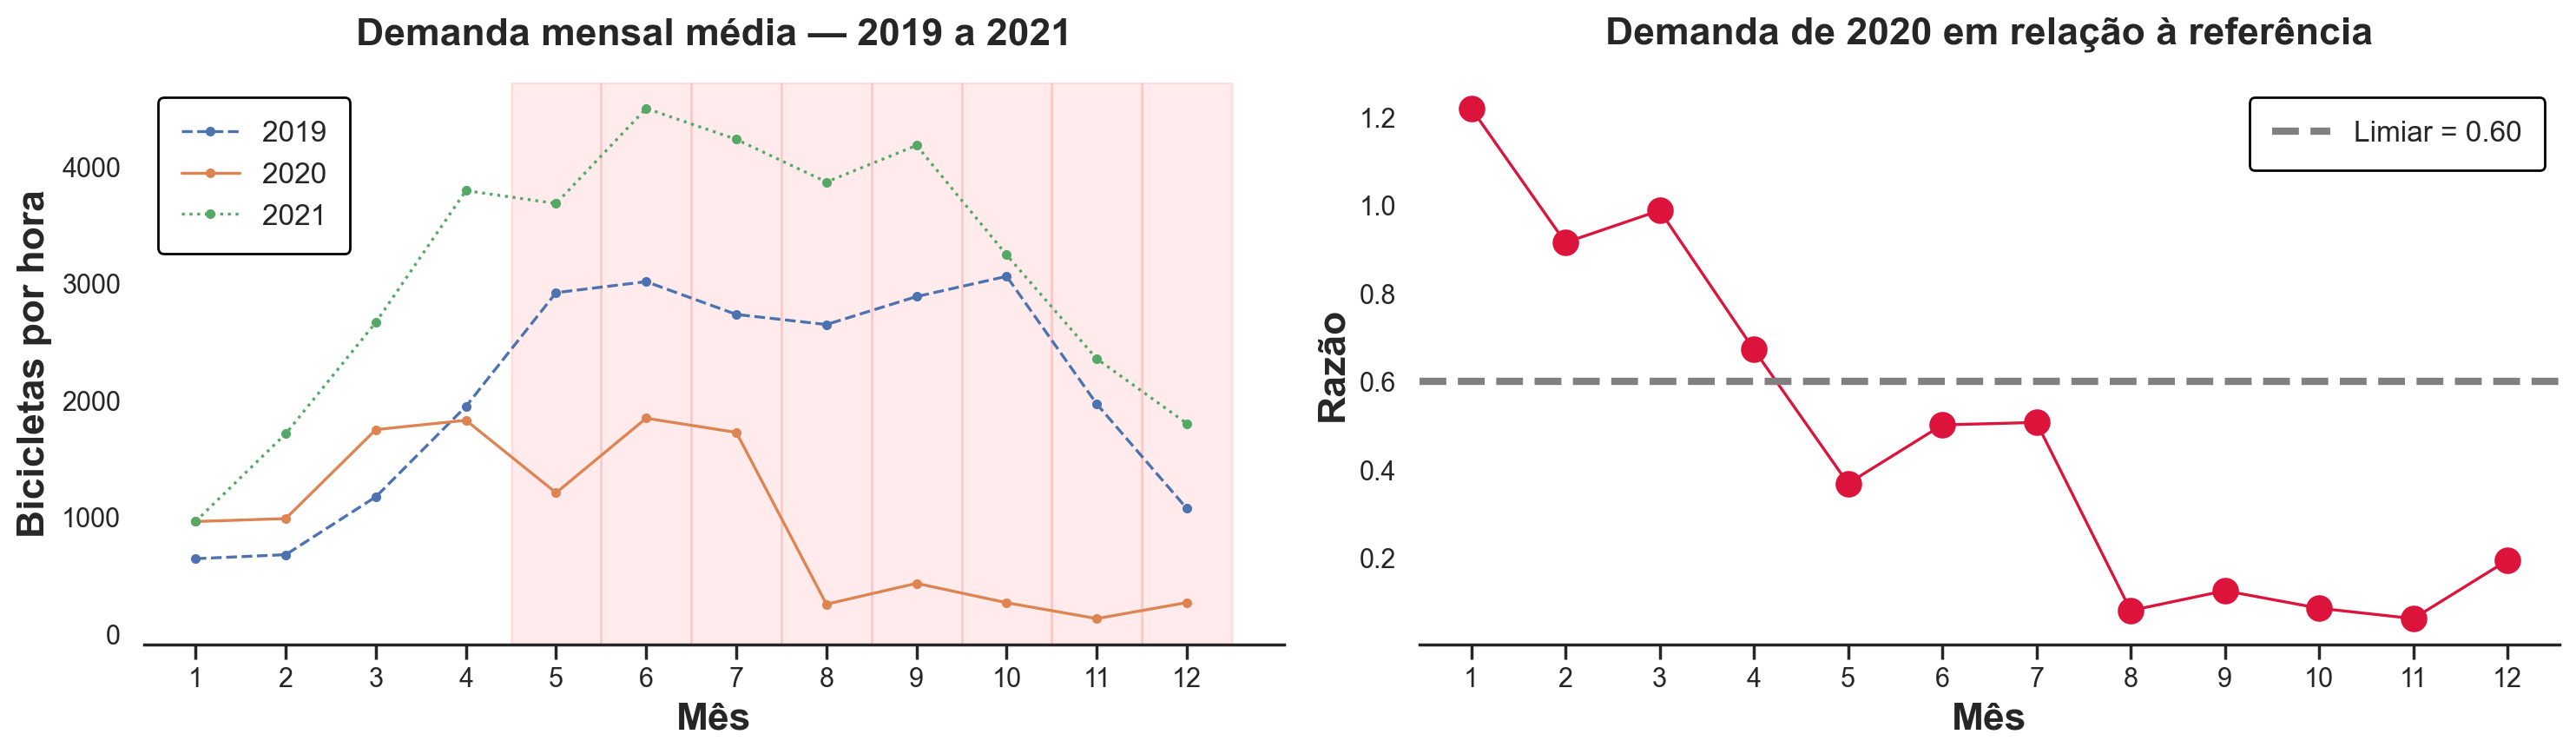

In [4]:
fig, axes = seasonal.plot_anomaly_diagnosis(diag, lang=lang)
plt.show()


>**`Insights do diagnóstico e decisão:`**
>
>A queda **não é o ano todo**: jan–abr/2020 segue a tendência (ratio ≈ 0.9–1.2), mas de **maio a dezembro** a demanda cai para 8–50% do esperado — colapso total em ago–nov (ratio 0.06–0.13) — e **recupera 100% em 2021**.
>
>Sinais que pesam contra "puro efeito COVID comportamental". Uma queda de ~90% sustentada por 5 meses é severa demais para mudança de comportamento,  o uso de bikes em Seul *cresceu* na pandemia (modo com distanciamento). Nenhuma hora com `count==0` em qualquer ano e cobertura de stamps normal em 2020 — os valores são *implausivelmente baixos*, não ausentes, compatível com **dados parciais / subconjunto de estações** reportando nesse período.
>
>**Causa: incerta, provável artefato de coleta.** Por isso, em vez de excluir dados ou assumir COVID, adota-se uma flag de regime `is_anomalous_2020` na janela afetada (nome neutro) e as **linhas são mantidas** — a análise e o modelo isolam o regime, e jan–abr/2020 (normal) fica intacto.

In [5]:
# Flag data-driven a partir da regra de limiar acima (não datas escolhidas à mão).
full['is_anomalous_2020'] = seasonal.anomaly_mask(full, diag).astype(int)
n_anom = int(full['is_anomalous_2020'].sum())
msg = lang({
    'flag': 'is_anomalous_2020 = 1 para',
    'rows': 'linhas',
    'months': '-> meses de 2020',
})
print(f'{msg["flag"]} {n_anom:,} {msg["rows"]} ({100 * full["is_anomalous_2020"].mean():.1f}%) '
      f'{msg["months"]} {diag.anomalous_months}')


is_anomalous_2020 = 1 para 5,858 linhas (7.2%) -> meses de 2020 [5, 6, 7, 8, 9, 10, 11, 12]


## 2. Des-tendenciar a demanda (linha de base móvel contínua)

O crescimento de aproximadamente **110× entre 2015 e 2023** é tratado neste notebook como uma mudança de **nível e escala do sistema** — compatível com expansão de bicicletas, estações e usuários —, e não como evidência de uma alteração meteorológica de magnitude equivalente. A causa desse crescimento não pode ser identificada apenas com estes dados observacionais; ainda assim, o componente de baixa frequência precisa ser removido para que as associações intranuais com hora, estação e clima não sejam confundidas com o ano em que cada observação foi registrada. A normalização por ano-calendário também é evitada: dezembro de um ano e janeiro do seguinte seriam divididos por bases distintas, e um degrau artificial seria introduzido no meio do mesmo inverno.

**Método (*ratio-to-moving-average*):** primeiro, a contagem horária é agregada pela média de cada dia. Em seguida, uma linha de base $\widehat{T}_t$ é estimada por uma **média móvel centrada de 365 dias** (`min_periods=180`), e a demanda horária é transformada no índice multiplicativo $I_t = Y_t / \widehat{T}_t$. Com a agregação diária, é evitado que 365 observações sejam confundidas com apenas 365 horas; pela janela anual, a sazonalidade é atenuada na estimação da base e uma descontinuidade em 1º/jan é evitada. A sazonalidade não é, contudo, cancelada por construção: variações relativas sazonais, meteorológicas e irregulares são preservadas no índice em torno de 1. Essa formulação segue a decomposição multiplicativa clássica por razão à média móvel descrita por [Miller e Williams (2003)](https://doi.org/10.1016/S0169-2070(02)00077-8).

**Tratamento da anomalia e cobertura:** os dias marcados por `is_anomalous_2020` são excluídos somente da estimação da base, para que o colapso de mai–dez/2020 não desloque a tendência artificialmente para baixo. Como esse intervalo é mais longo do que a tolerância permitida por `min_periods=180`, parte da própria janela anômala fica sem observações válidas suficientes e recebe índice `NaN`; essas linhas são posteriormente excluídas do quadro multivariado. Portanto, a exclusão da anomalia não deve ser interpretada como sua imputação ou correção.

**Escopo de uso:** como observações anteriores e posteriores são utilizadas por uma janela centrada, o índice é apropriado à **análise retrospectiva** realizada neste notebook. Ele não deve ser utilizado como feature disponível em tempo real nem como transformação causal de previsão. Nas extremidades da série, bases apoiadas em menos de 365 dias podem ser aceitas pelo mínimo de 180 observações; por isso, anos meteorológicos parciais devem ser interpretados separadamente dos anos completos.

In [6]:
demand_index = seasonal.demand_index_moving_average(
    full, anomaly_mask=full['is_anomalous_2020'].astype(bool))
full['met_year'] = seasonal.meteorological_year(full['Date'])

msg = lang({
    'defined': 'índice definido para',
    'rows_note': 'linhas; NaN é produzido onde há menos de 180 dias-base válidos',
    'undefined': 'linhas indefinidas estão dentro da janela anômala de 2020 sinalizada',
    'mean_by': ('Índice médio por ano meteorológico '
                '(apenas anos completos e não anômalos são diretamente comparáveis):'),
})
print(f'{msg["defined"]} {demand_index.notna().sum():,}/{len(full):,} '
      f'({100*demand_index.notna().mean():.1f}%) — {msg["rows_note"]}')
undefined_in_anomaly = (demand_index.isna() & full['is_anomalous_2020'].astype(bool)).sum()
print(f'{undefined_in_anomaly:,} {msg["undefined"]}')
print(f'\n{msg["mean_by"]}')
print(demand_index.groupby(full['met_year']).mean().round(3).to_string())


índice definido para 75,304/81,018 (92.9%) — linhas; NaN é produzido onde há menos de 180 dias-base válidos
5,714 linhas indefinidas estão dentro da janela anômala de 2020 sinalizada

Índice médio por ano meteorológico (apenas anos completos e não anômalos são diretamente comparáveis):
met_year
2015    1.090
2016    0.943
2017    1.004
2018    0.962
2019    1.006
2020    0.754
2021    0.997
2022    1.008
2023    0.998
2024    0.961
2025    0.587


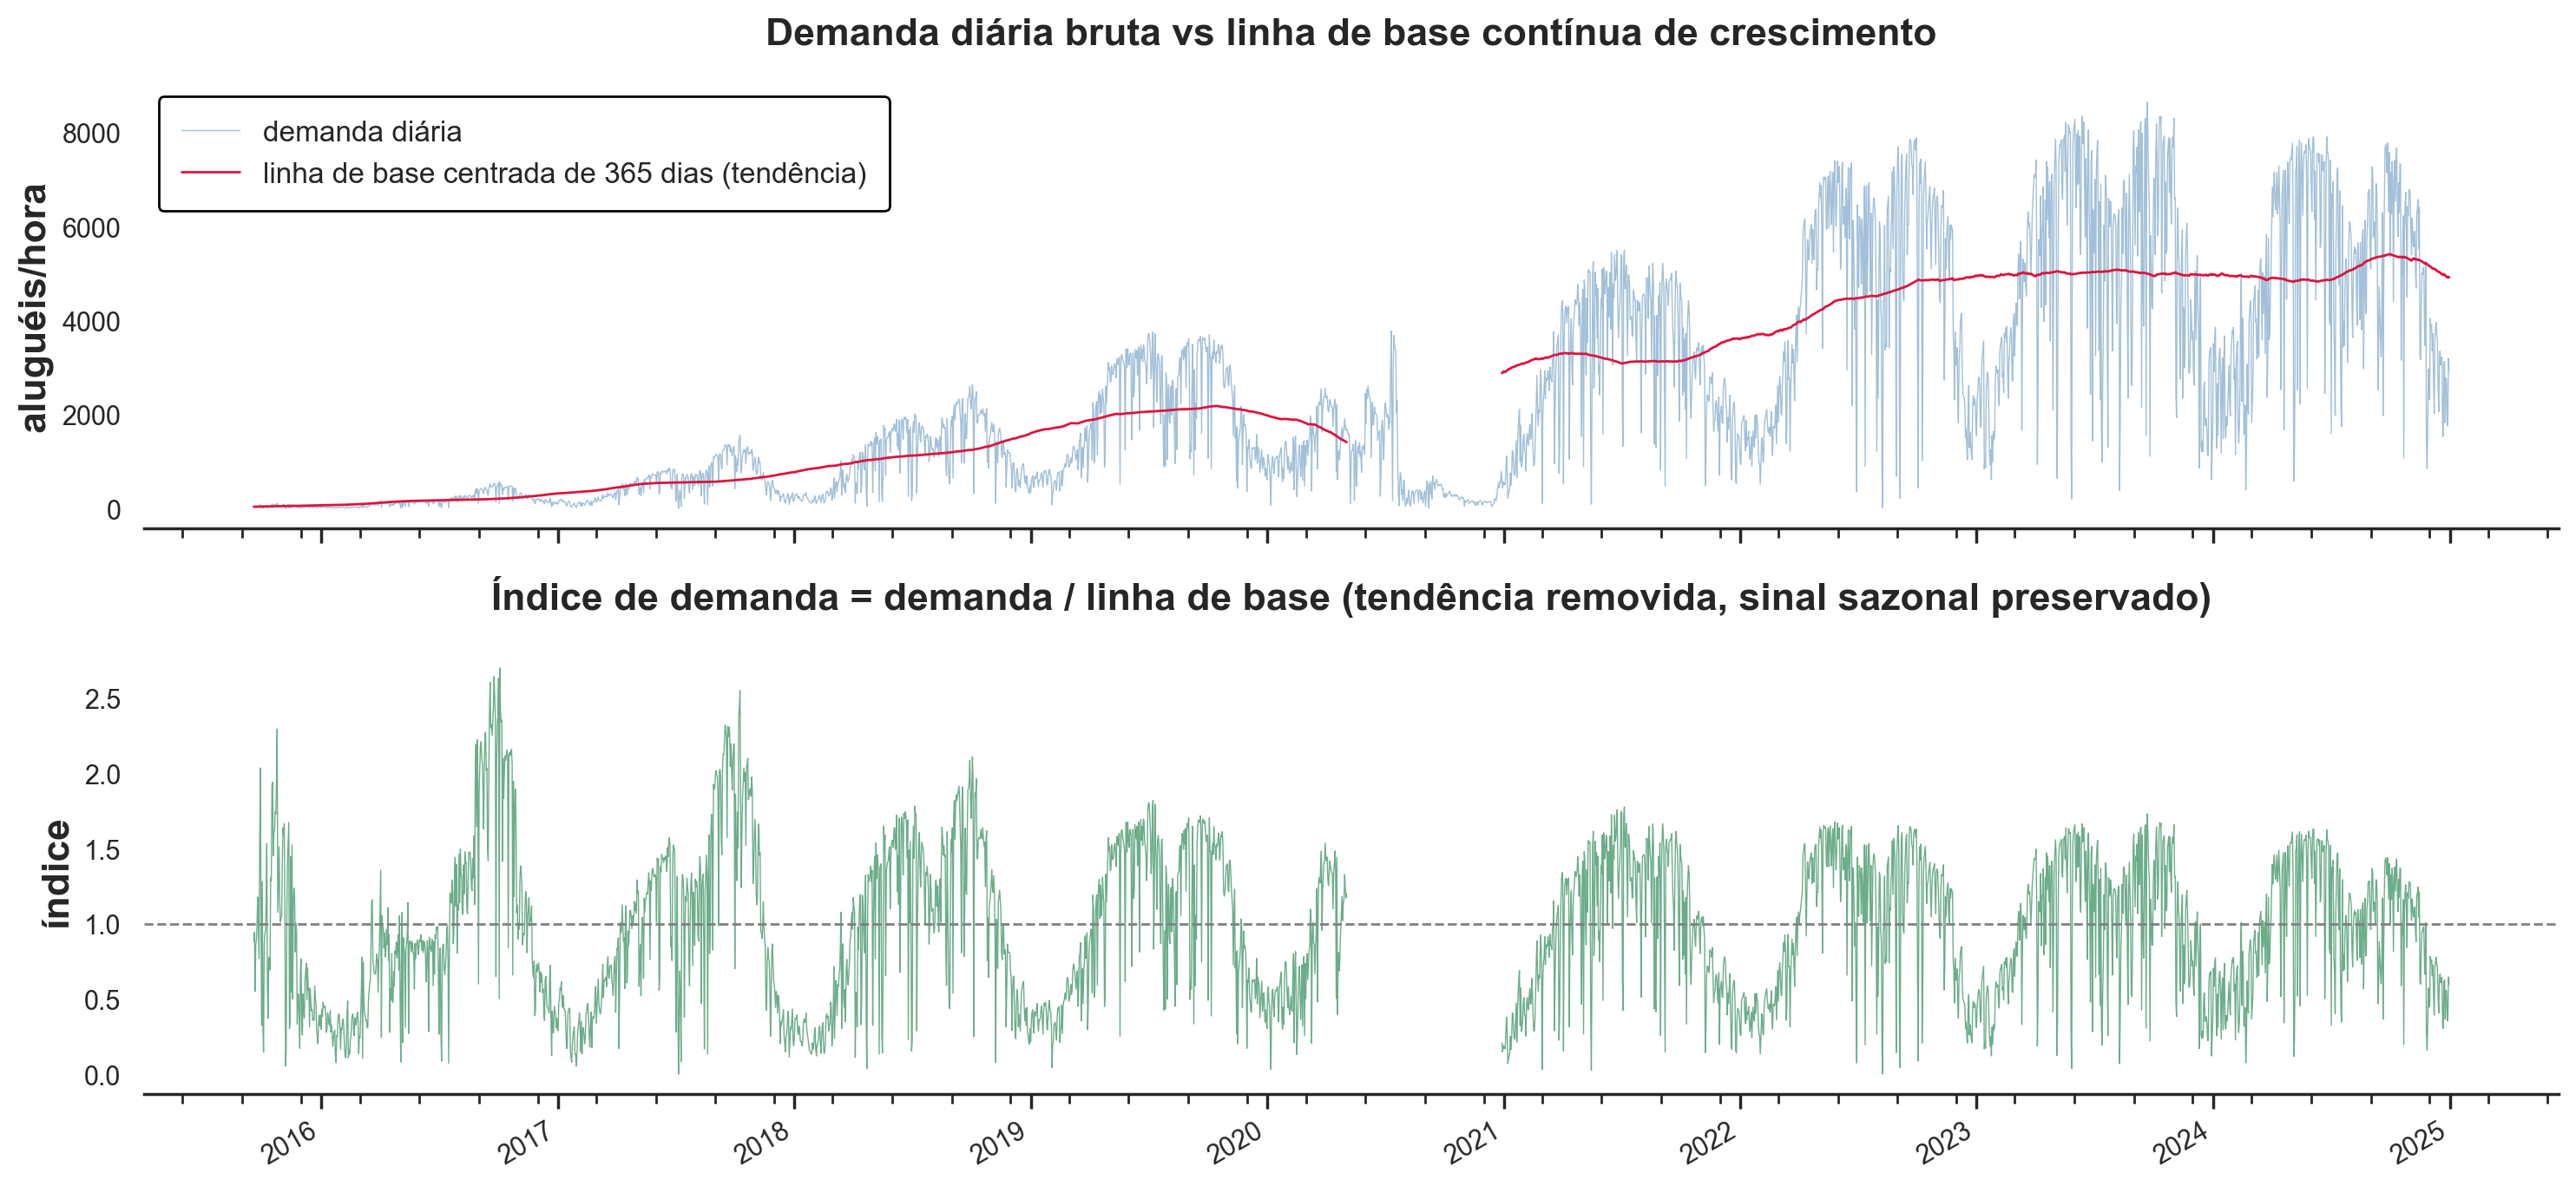

tendência residual de crescimento -> corr(tempo, índice)=0.0274 vs corr(tempo, demanda bruta)=0.548


In [7]:
fig, axes = seasonal.plot_baseline_and_index(full, demand_index, lang=lang)
plt.show()

corr_idx, corr_raw = seasonal.time_index_correlations(full, demand_index, TARGET)
msg = lang({
    'trend': 'tendência residual de crescimento -> corr(tempo, índice)',
    'vs': 'vs corr(tempo, demanda bruta)',
})
print(f'{msg["trend"]}={corr_idx:.4f} {msg["vs"]}={corr_raw:.3f}')


In [8]:
mv_df, meta = seasonal.build_analysis_frame(full, demand_index, TARGET)
msg = lang({'frame': 'quadro de análise', 'cols': 'colunas de análise', 'rows': 'linhas'})
print(f'{msg["frame"]}: {len(mv_df):,} {msg["rows"]}')
print(f'{msg["cols"]}:', list(mv_df.columns))


quadro de análise: 75,304 linhas
colunas de análise: ['Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)', 'Dew point temperature(C)', 'Solar Radiation (MJ/m2)', 'Sunshine (hr)', 'Cloud Cover (oktas)', 'Ground Temp(C)', 'Visibility (10m)', 'DayNumberOnWeek', 'Seasons', 'Holiday', 'Time_Period', 'Weekday', 'WeekStatus', 'Rush_Hour', 'Rush_Period', 'Rainfall Cat', 'Snowfall Cat', 'Sunshine Cat', 'Cloud Cover Cat', 'Month', 'is_anomalous_2020']


### Recorrência do padrão sazonal entre anos (validação da intuição)

A hipótese de que uma estrutura sazonal repetível permanece após a remoção do nível é avaliada pela sobreposição dos perfis mensais de cada ano meteorológico (dez→nov). Uma hierarquia ampla é preservada: índices inferiores à base são observados no inverno, uma recuperação é observada na primavera e níveis mais altos são observados nos meses quentes e no início do outono. Assim, a continuidade sazonal é mantida sem que o inverno seja dividido pela fronteira de 1º/jan.

A sobreposição não deve, porém, ser interpretada como invariância anual. Diferenças de amplitude são visíveis entre as curvas, sobretudo em setembro e outubro, e os anos associados à anomalia ou às bordas possuem cobertura parcial. Foi confirmada, portanto, a recorrência do **formato sazonal geral**, mas não a igualdade dos perfis nem uma relação causal exclusivamente climática.

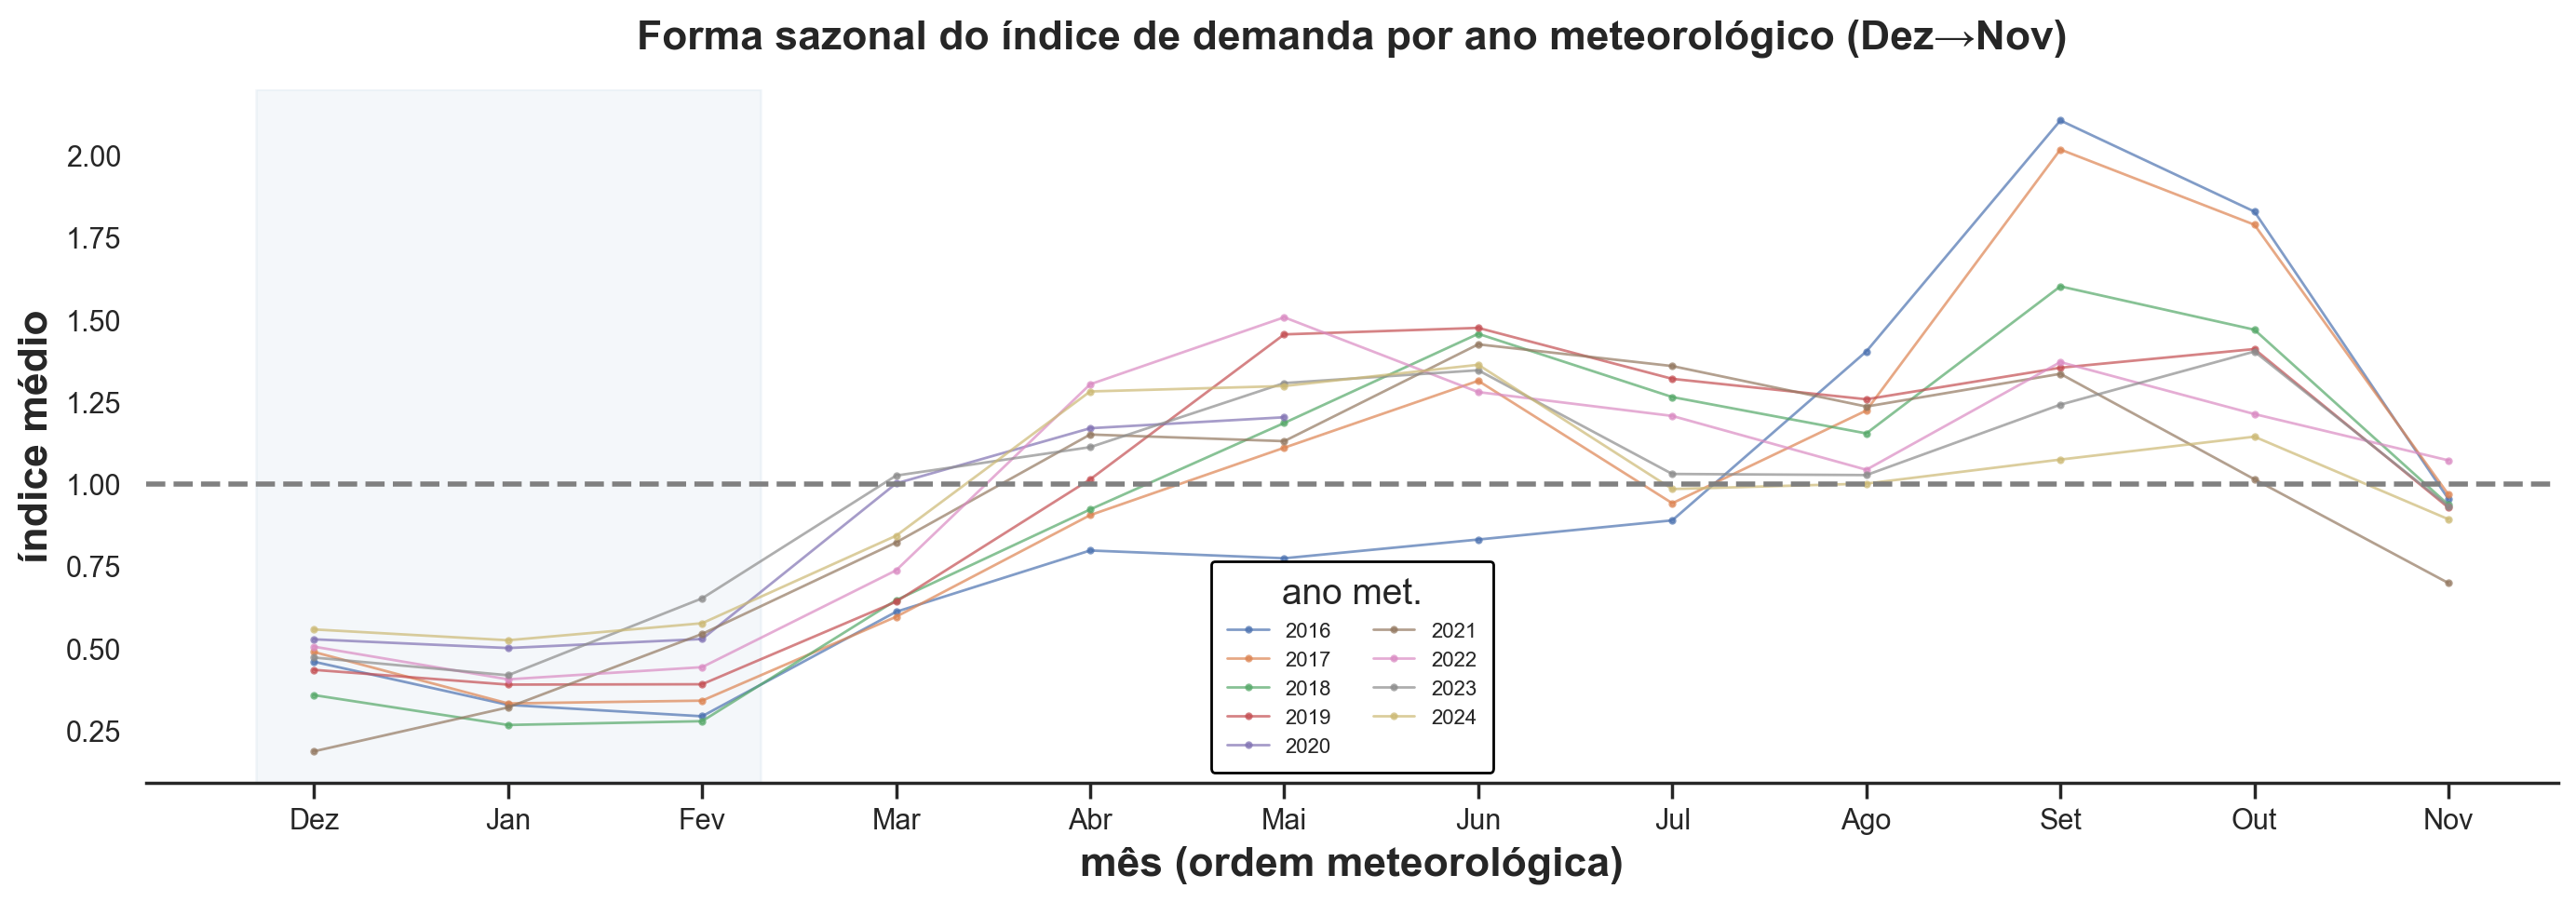

In [9]:
fig, ax = seasonal.plot_seasonal_shape_by_met_year(full, demand_index, lang=lang)
plt.show()


> **Insights da des-tendência da demanda:**
>
> A dependência linear com o tempo foi reduzida de `corr(tempo, demanda bruta) = 0,548` para `corr(tempo, índice) = 0,0274`. Foi demonstrada uma forte remoção da tendência linear, mas não foi provada a ausência de toda tendência residual ou não linear.
>
> O índice foi definido para **75.304 de 81.018 linhas (92,9%)**. As **5.714 linhas indefinidas** foram concentradas na janela anômala de 2020, na qual menos de 180 dias não anômalos ficaram disponíveis para certas janelas centradas. Consequentemente, os resumos de 2020 e 2021 foram afetados por cobertura parcial.
>
> Nos anos meteorológicos completos e não anômalos, médias anuais próximas de 1 foram obtidas (aproximadamente `0,943–1,008`), o que é coerente com a remoção do nível de crescimento. Os valores de 2015 e 2025 não devem ser comparados diretamente, pois foram calculados com fragmentos das extremidades da série.
>
> Um padrão sazonal amplo foi preservado: níveis relativos baixos foram observados no inverno e níveis mais altos foram observados nos meses quentes e no início do outono. Como diferenças de amplitude permaneceram entre anos, especialmente em setembro–outubro, apenas a estabilidade da forma geral foi sustentada.
>
> As análises seguintes devem ser interpretadas como associações com a **demanda relativa à linha de base móvel**, condicionadas à cobertura disponível. Efeitos causais não foram identificados, e uma transformação operacional para previsão em tempo real não foi produzida.

## 3. Correlação de Phik + significância

O coeficiente $\phi_K$ é empregado para que associações entre variáveis intervalares, ordinais e categóricas sejam avaliadas sob uma métrica comum. Variáveis intervalares são discretizadas internamente, e dependências lineares ou não lineares podem ser capturadas. A formulação e o procedimento de significância foram propostos por [Baak et al. (2020)](https://doi.org/10.1016/j.csda.2020.107043).

Diferentemente da correlação de Pearson, valores negativos e direção não são produzidos por $\phi_K$. A intensidade é limitada ao intervalo $[0, 1]$: ausência de associação é representada por 0 e associação completa é representada por 1. Neste notebook, valores abaixo de 0,10 são tratados como desprezíveis, valores entre 0,10 e 0,30 como fracos, valores entre 0,30 e 0,50 como moderados, valores entre 0,50 e 0,70 como relativamente fortes, valores entre 0,70 e 0,90 como fortes e valores acima de 0,90 como muito fortes. Esses intervalos são utilizados apenas como convenção descritiva, não como fronteiras inferenciais universais.

Para que o crescimento histórico da operação não domine a análise, o **índice des-tendenciado** construído na Seção 2 é utilizado como alvo. `Sunshine (hr)`, `Cloud Cover (oktas)` e `Ground Temp(C)` são informadas à biblioteca como variáveis intervalares por meio de `PHIK_INTERVAL_COLS`; as demais variáveis são tratadas conforme a representação recebida pelo cálculo.

Uma amostra de **2.500 linhas**, formada por 250 observações de cada ano-calendário, é selecionada de maneira estratificada e reprodutível. O custo da matriz completa e da avaliação híbrida de significância é reduzido por essa amostragem, mas alguma variabilidade amostral e dependência da discretização são introduzidas. Como o mesmo peso é atribuído a cada ano, os coeficientes passam a representar uma distribuição balanceada por ano, e não a frequência original de todas as observações. Assim, os resultados são utilizados como diagnóstico exploratório, e não como estimativas imutáveis para toda a população.

A força da associação é separada de sua evidência estatística. Um coeficiente pequeno pode receber significância elevada quando a independência é rejeitada com clareza, enquanto um coeficiente alto pode ser instável em uma amostra insuficiente. Causalidade, direção do efeito e ganho preditivo fora da amostra não são identificados por esta análise.

phik em 2,500 linhas (estratificado por ano)


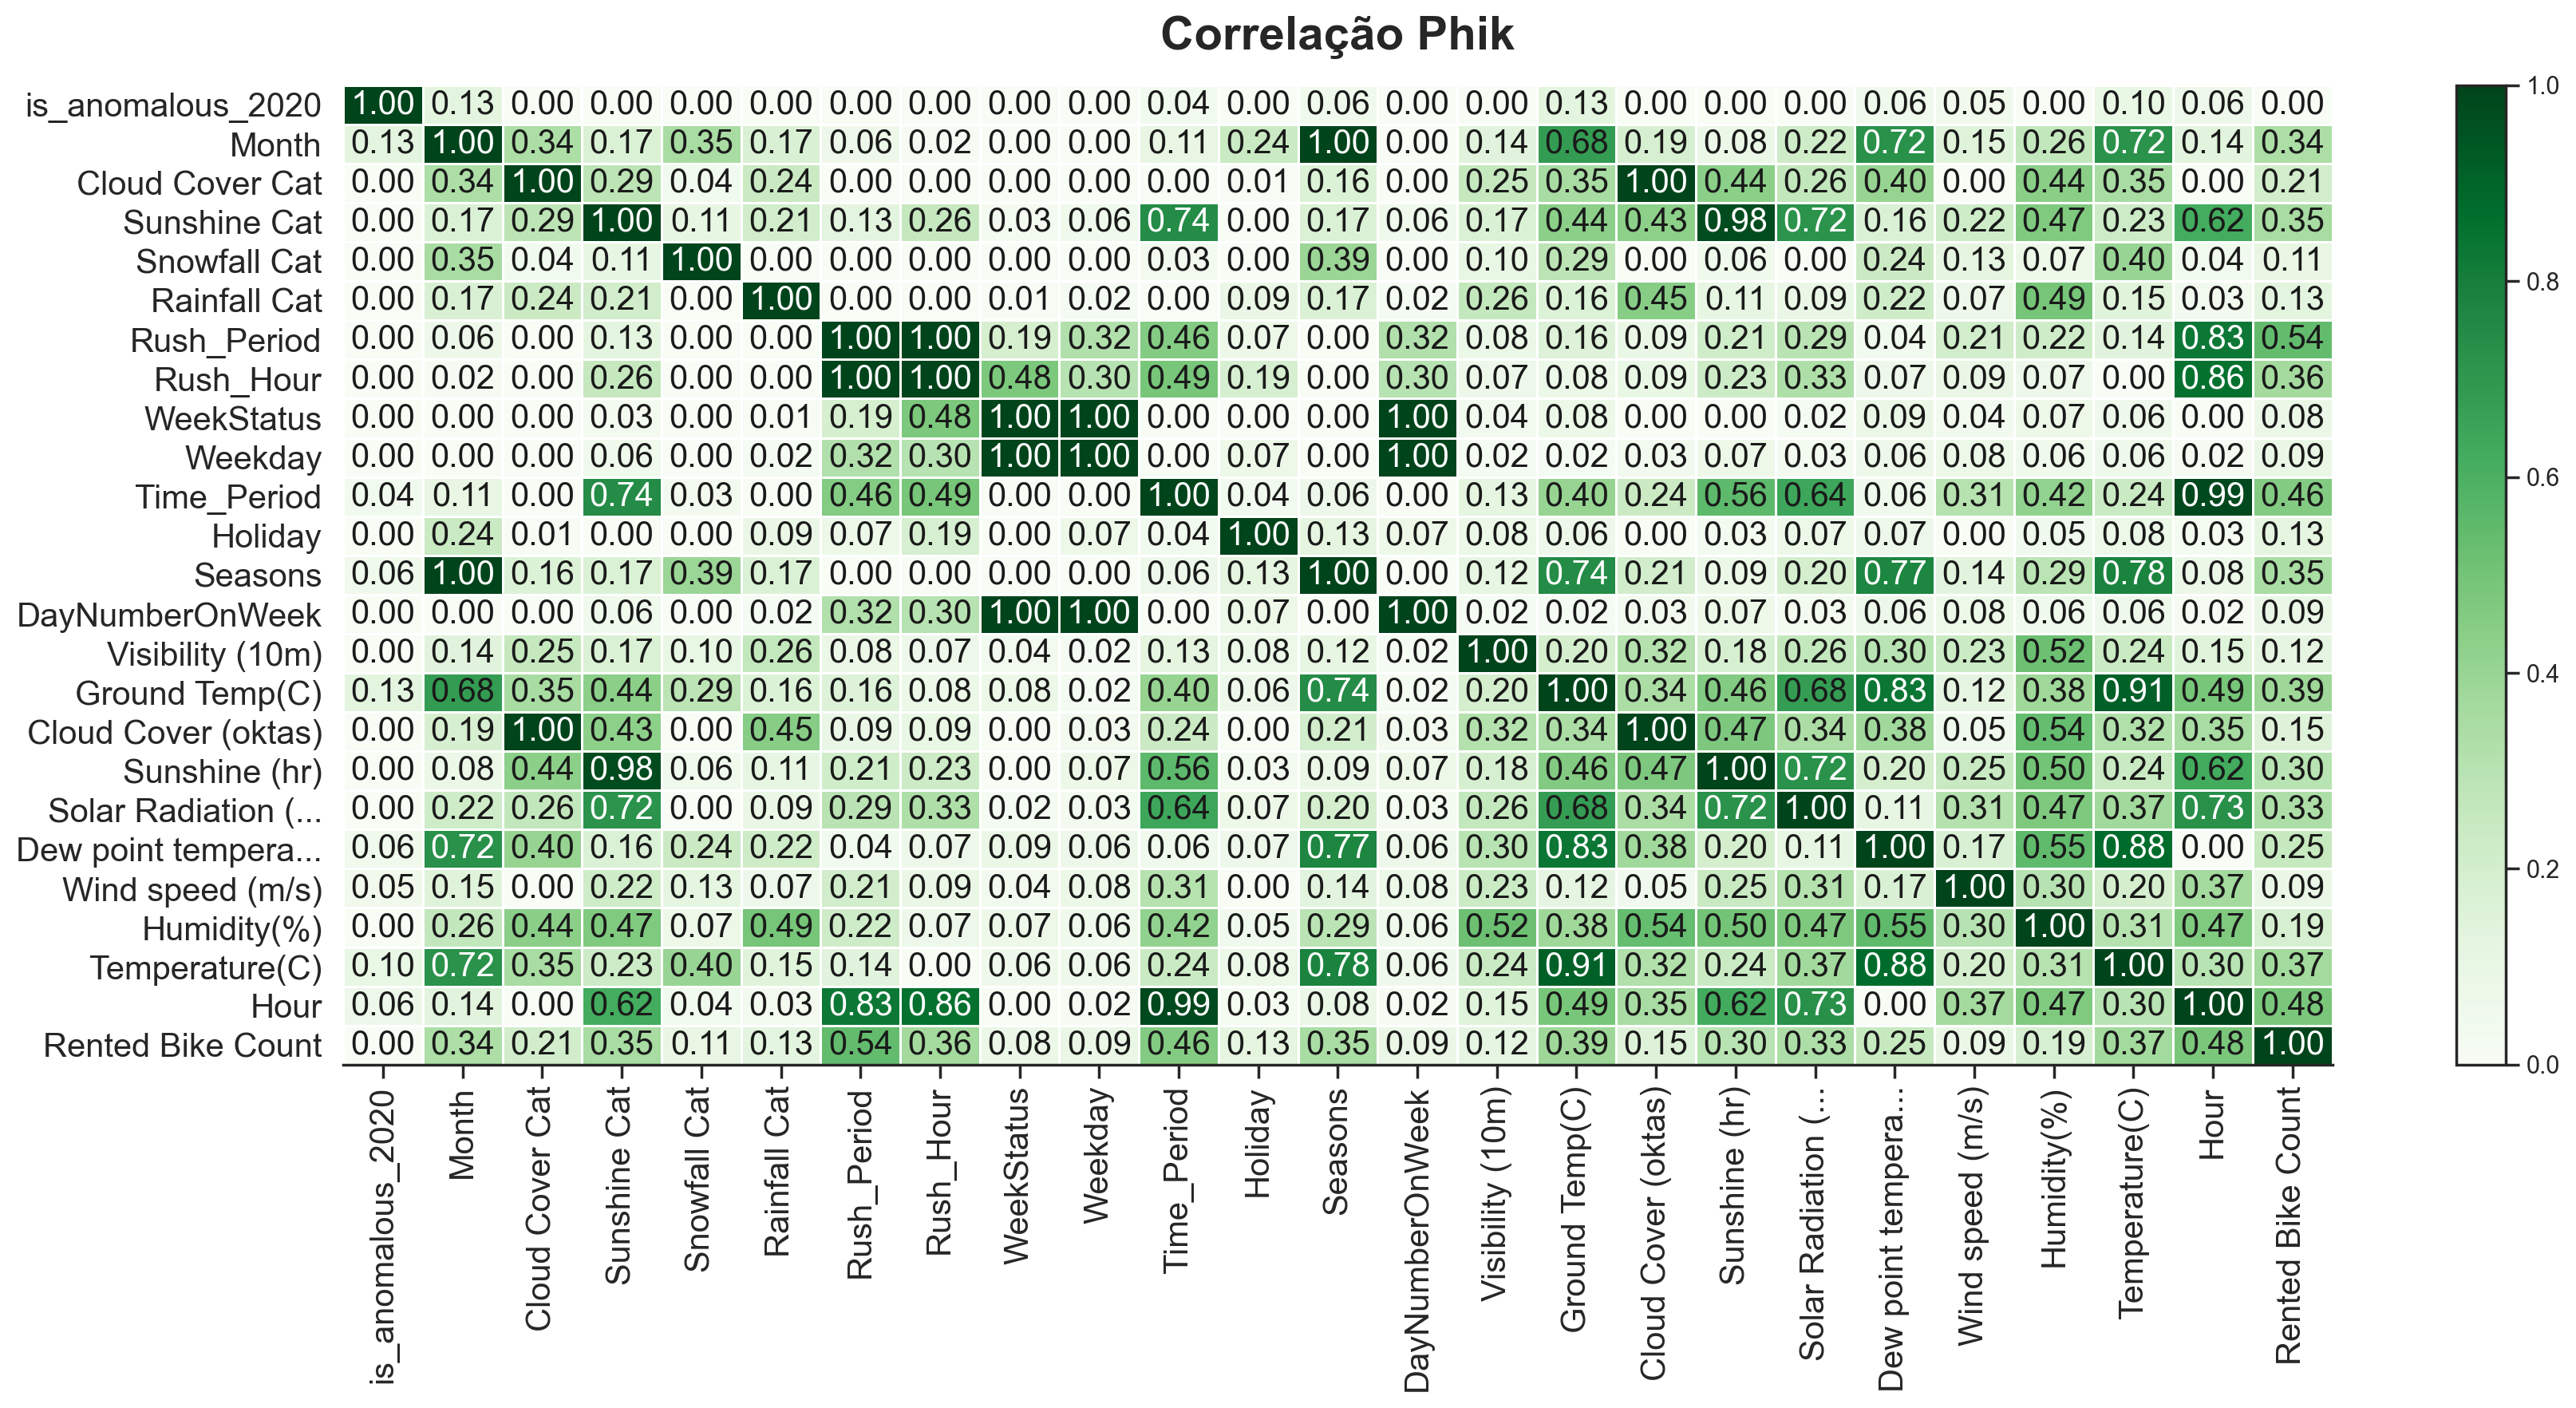

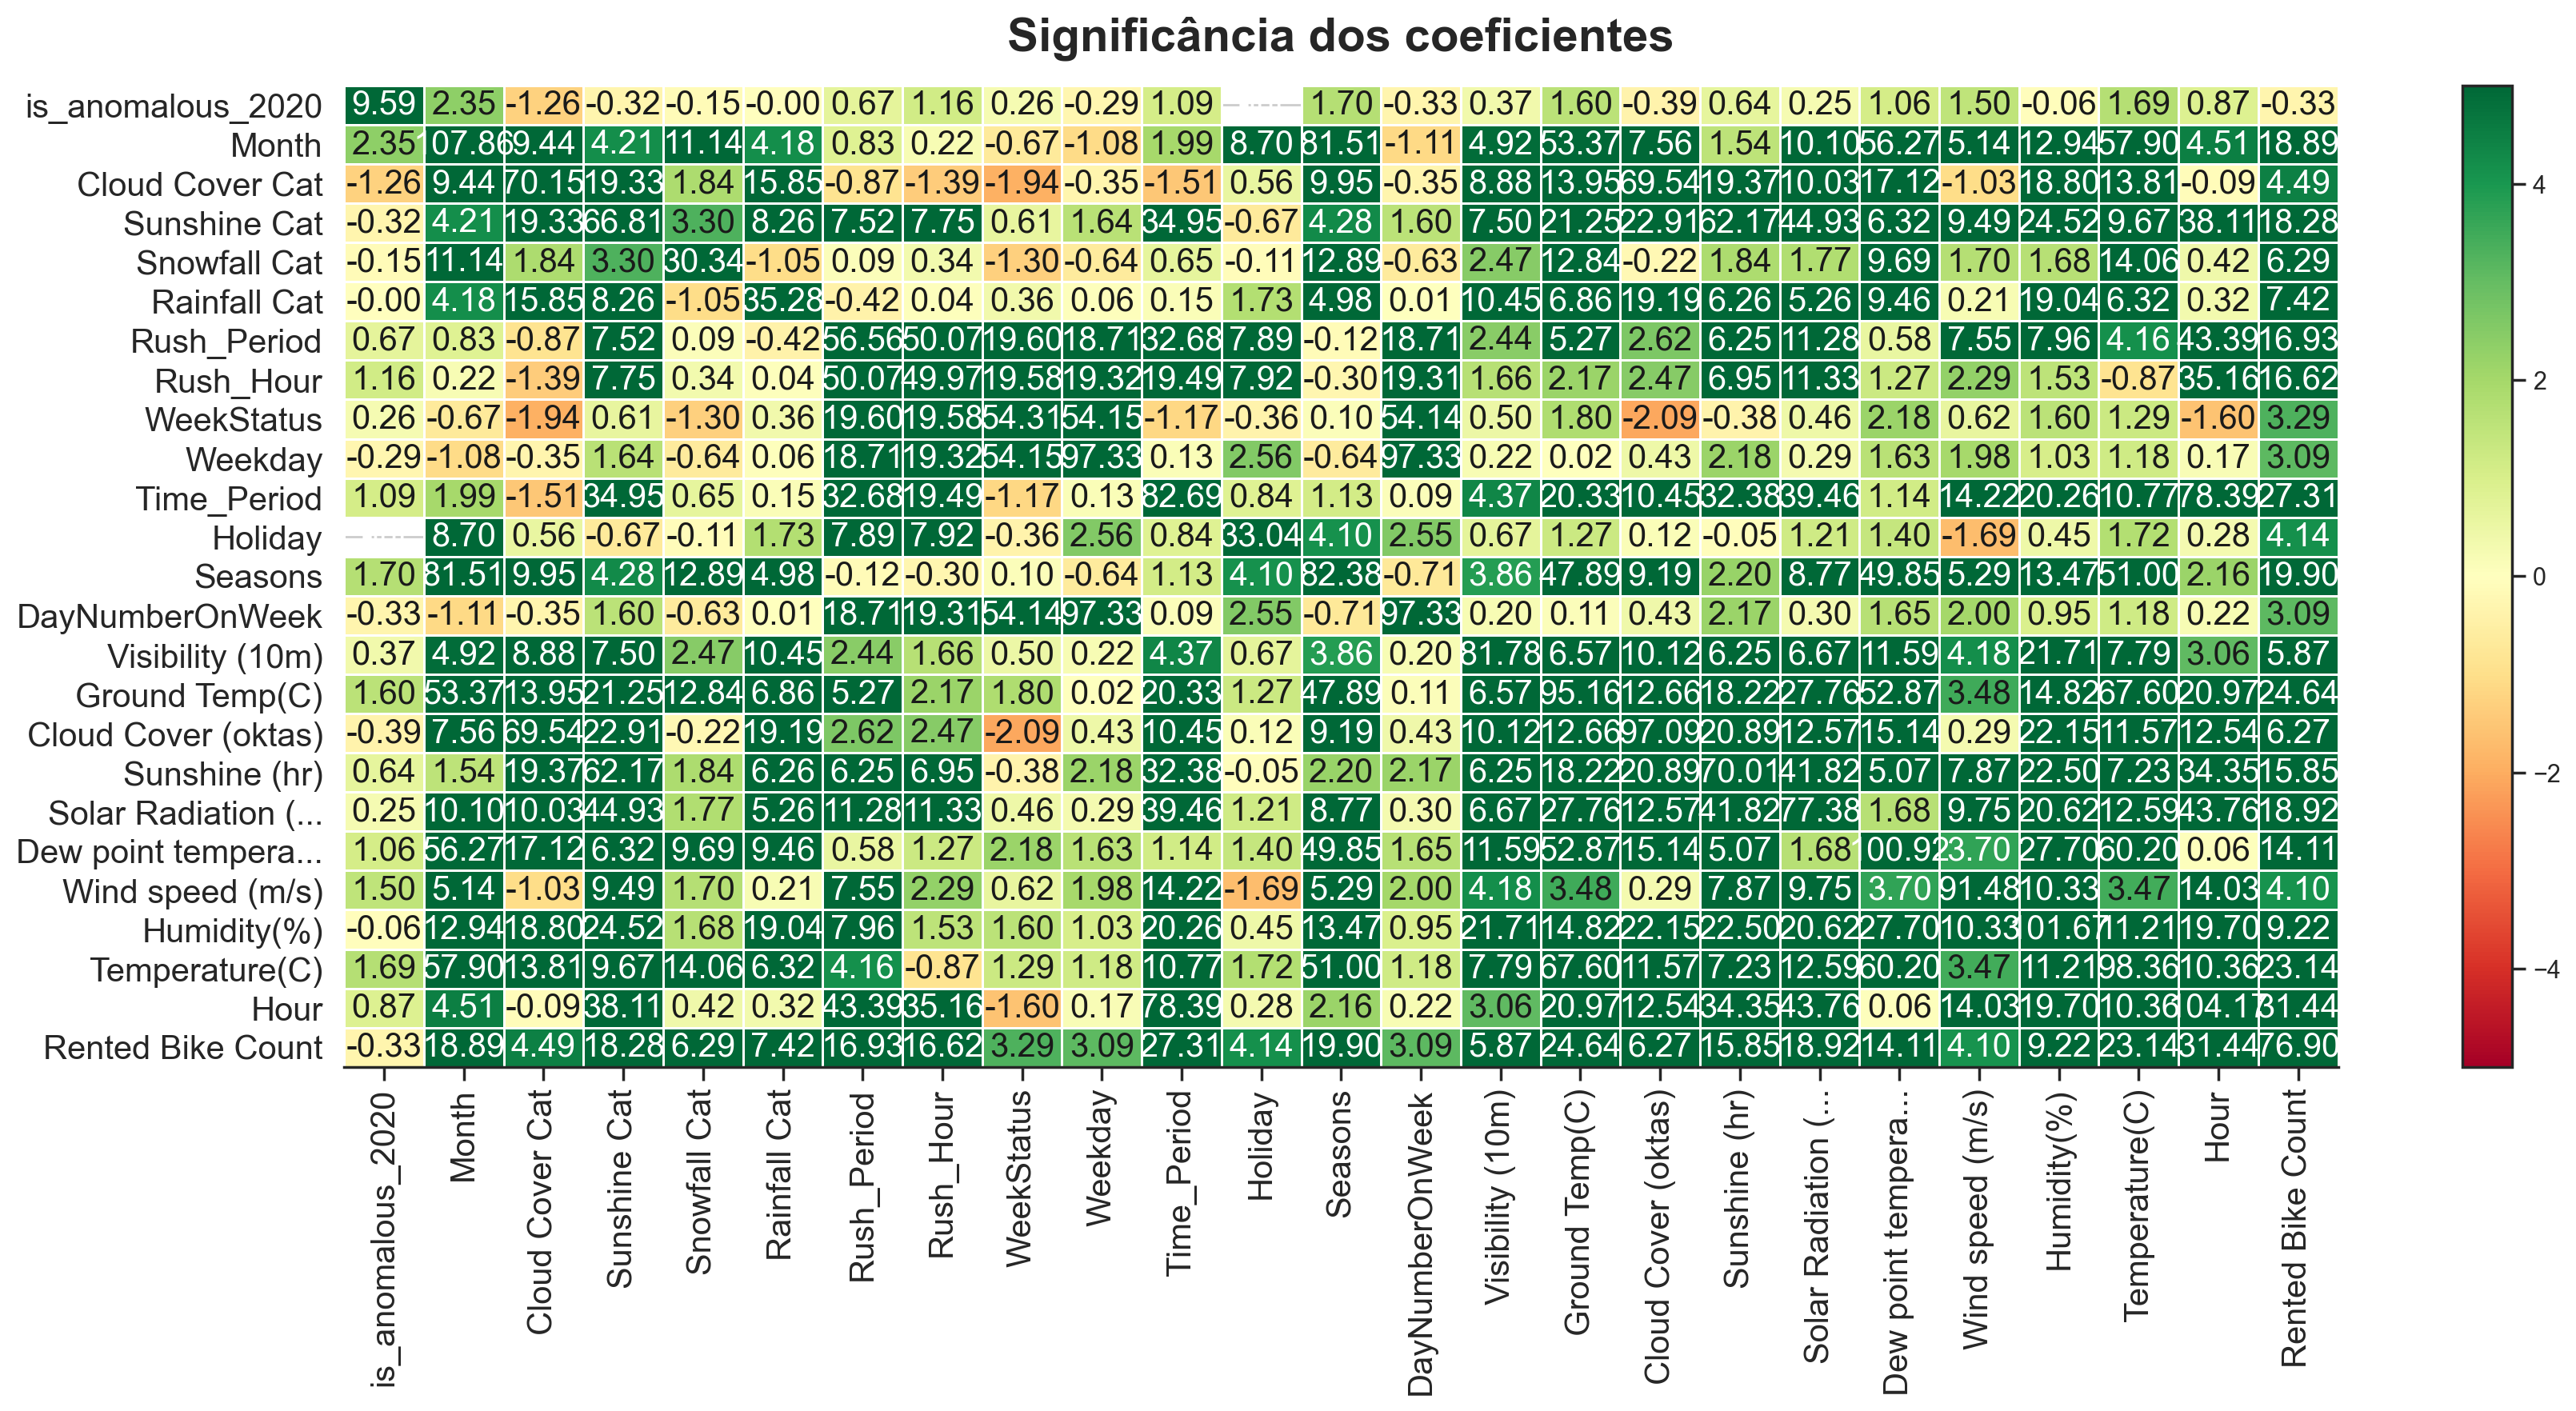

In [10]:
phik_sample = fs.stratified_sample_by(mv_df, meta['Year'], 250)
msg = lang({'phik_on': 'phik em', 'rows_strat': 'linhas (estratificado por ano)'})
print(f'{msg["phik_on"]} {len(phik_sample):,} {msg["rows_strat"]}')

phik_pairs, phik_matrix, phik_sig = fs.build_phik_significance_df(
    phik_sample, return_matrices=True)
fs.plot_phik_matrix(phik_matrix_df=phik_matrix, significance_matrix_df=phik_sig, lang=lang)
plt.show()


A significância de $\phi_K$ é devolvida como um valor-Z unilateral para o teste da hipótese de independência. O limiar `Z ≥ 3`, utilizado como padrão pelo relatório da biblioteca, é adotado como evidência estatística considerável. A magnitude e a significância são examinadas em conjunto, pois associação forte e rejeição da independência representam propriedades diferentes. [Documentação oficial do PhiK](https://phik.readthedocs.io/en/latest/phik.html)

Na tabela seguinte, são mantidos apenas os pares para os quais `phik ≥ 0,50` e `significance ≥ 3`. Cada combinação é apresentada uma única vez por `var1` e `var2`, e os resultados são ordenados da maior para a menor associação.

In [11]:
# Associações fortes e estatisticamente significativas entre pares de variáveis
PHIK_THRESHOLD = 0.50
SIGNIFICANCE_THRESHOLD = 3.0  # valor-Z unilateral (padrão do relatório PhiK)

significant_phik_pairs = fs.filter_significant_phik_pairs(
    phik_pairs, PHIK_THRESHOLD, SIGNIFICANCE_THRESHOLD)

phik_labels = lang({'significance': 'significância'})
display(fs.localize_phik_report(significant_phik_pairs, lang=lang).style.format(
    {'phik': '{:.3f}', phik_labels['significance']: '{:.2f} σ'}))


,Variável 1,Variável 2,phik,significância
0,DayNumberOnWeek,Weekday,1.000,97.33 σ
1,Seasons,Month,1.000,81.51 σ
2,Cloud Cover (oktas),Cloud Cover Cat,1.000,69.54 σ
3,Weekday,WeekStatus,1.000,54.15 σ
4,DayNumberOnWeek,WeekStatus,1.000,54.14 σ
5,Rush_Hour,Rush_Period,1.000,50.07 σ
6,Hour,Time_Period,0.986,78.39 σ
7,Sunshine (hr),Sunshine Cat,0.976,62.17 σ
8,Temperature(C),Ground Temp(C),0.913,67.60 σ
9,Temperature(C),Dew point temperature(C),0.877,60.20 σ


Em seguida, a análise é restringida aos pares que contêm a variável-alvo des-tendenciada. Nesse quadro, nenhum corte de magnitude é aplicado, para que associações moderadas ou fracas com evidência estatística também sejam preservadas para interpretação.

In [12]:
# Maiores associações com o índice de demanda (des-tendenciado)
demand_pairs = fs.phik_pairs_with_target(phik_pairs, TARGET, lang=lang)
display(demand_pairs.head(30))


,Outra variável,phik,significância
0,Rush_Period,0.541510,16.926398
1,Hour,0.480698,31.443622
2,Time_Period,0.457938,27.314007
3,Ground Temp(C),0.385456,24.636357
4,Temperature(C),0.368251,23.137603
5,Rush_Hour,0.363831,16.624862
6,Sunshine Cat,0.354717,18.284101
7,Seasons,0.347142,19.900411
8,Month,0.339824,18.893352
9,Solar Radiation (MJ/m2),0.332745,18.918937


> **Insights da análise PhiK**
>
> Pelo filtro conjunto de magnitude e significância, foram retidos **33 pares** com `phik ≥ 0,50` e `Z ≥ 3`. As maiores associações foram observadas principalmente em variáveis derivadas da mesma informação: valores iguais a 1 foram obtidos para `DayNumberOnWeek`–`Weekday`, `Seasons`–`Month`, `Cloud Cover (oktas)`–`Cloud Cover Cat`, `Weekday`–`WeekStatus`, `DayNumberOnWeek`–`WeekStatus` e `Rush_Hour`–`Rush_Period`. Associações próximas de 1 também foram obtidas para `Hour`–`Rush_Period` (`0,825`), `Hour`–`Time_Period`, `Sunshine (hr)`–`Sunshine Cat` e `Hour`–`Rush_Hour`. Essas relações são interpretadas como redundâncias introduzidas pelo feature engineering, e não como descobertas independentes.
>
> Uma segunda estrutura redundante foi observada entre as medidas térmicas. Valores entre `0,828` e `0,913` foram obtidos entre `Temperature(C)`, `Ground Temp(C)` e `Dew point temperature(C)`, enquanto associações relevantes também foram observadas com `Month` e `Seasons`. Foi indicada, assim, sobreposição de informação física e sazonal, mas uma exclusão automática não foi justificada apenas pela associação bivariada.
>
> Apenas um par formado com o alvo atingiu `phik ≥ 0,50`: `Rush_Period` (`0,542`). As maiores associações com o índice des-tendenciado foram obtidas para `Rush_Period` (`0,542`), `Hour` (`0,481`), `Time_Period` (`0,458`), `Ground Temp(C)` (`0,385`) e `Temperature(C)` (`0,368`), todas acompanhadas por valores-Z elevados. Como `Rush_Period` é uma função determinística da hora — seus valores de `phik` iguais a `1,000` com `Rush_Hour` e a `0,825` com `Hour` confirmam essa dependência —, sua associação com o alvo reflete o mesmo sinal de horário de pico, e não uma informação independente. Foi evidenciado, assim, que um sinal relevante é contido pelo período de pico, pela hora, pelo período do dia e pelas condições térmicas, embora uma explicação forte da demanda relativa não seja produzida por uma variável isolada.
>
> Como decisão deste projeto, uma remoção manual de variáveis não será executada com base apenas em PhiK. Todas as variáveis serão mantidas como candidatas, e a escolha final será delegada ao processo de otimização dentro do pipeline. Com isso, interações condicionais e utilidade específica para cada estimador poderão ser preservadas mesmo quando associações bivariadas altas ou baixas tiverem sido observadas.
>
> Na função `RegressionOptimizer.get_feature_selection`, definida em `src/optimizer.py`, uma alternativa compatível é amostrada conforme a família do estimador. `NoSelector` é implementado como `passthrough`; por `SelectKBest`, entre 6 e 22 variáveis são retidas com `mutual_info_regression`; por `RFE`, entre 6 e 18 variáveis são selecionadas recursivamente; por `SelectFromModel`, um máximo entre 8 e 24 variáveis é imposto a partir da importância do estimador e do limiar amostrado; e por `SequentialFeatureSelector`, entre 6 e 14 variáveis são selecionadas no sentido *backward* com validação cruzada interna. Assim, a própria ausência de seleção também é comparada como uma hipótese de modelagem.
>
> Nem todos os seletores são oferecidos a todos os estimadores. Para `HistGradientBoostingRegressor`, por exemplo, apenas `NoSelector` e `SelectKBest` são disponibilizados por restrições de compatibilidade e custo; além disso, `NoSelector` é rejeitado quando um pré-processamento de alta dimensionalidade é escolhido. A decisão final deve, portanto, ser lida como resultado conjunto de estimador, transformação, seletor e validação temporal, e não como um ranking universal de features.
>
> Caso `NoSelector` seja escolhido, redundâncias determinísticas poderão permanecer no modelo e a importância poderá ser distribuída entre representações equivalentes. Para fins de interpretação, essas variáveis deverão ser analisadas em grupos semânticos. Causalidade, direção do efeito e estabilidade fora da amostra não foram demonstradas pela matriz PhiK.

## 4. Colinearidade das variáveis de temperatura (VIF)

Foi examinada a multicolinearidade linear entre seis medidas meteorológicas contínuas: temperatura do ar, ponto de orvalho, temperatura do solo, umidade, radiação solar e velocidade do vento. O diagnóstico foi delimitado a esse subconjunto por nele serem esperadas sobreposições físicas e sazonais; portanto, não foi produzida uma avaliação global de todas as features do dataset.

Para cada feature $X_j$, foi ajustada uma regressão linear auxiliar de $X_j$ contra as demais features, com intercepto, e foi calculado $VIF_j = 1/(1-R_j^2)$. O valor de $R_j^2$ dessa regressão também foi apresentado como `R2_auxiliar`, para que fosse explicitada a parcela da variância de cada preditor linearmente reconstruída pelos outros. O alvo não participa desse cálculo: o índice de demanda des-tendenciado apenas determina o recorte de 75.304 linhas herdado de `mv_df`.

Um VIF igual a 1 representa ausência de inflação da variância, enquanto valores crescentes indicam maior redundância linear conjunta. As faixas `< 5`, `5–10` e `> 10` são adotadas somente como referências descritivas. Uma variável não deve ser removida automaticamente porque um limiar foi ultrapassado; o tamanho amostral, o objetivo inferencial ou preditivo e a família do estimador também devem ser considerados. Essa cautela quanto ao uso mecânico de regras de corte foi discutida por [O’Brien (2007)](https://doi.org/10.1007/s11135-006-9018-6).

In [13]:
temp_like = ['Temperature(C)', 'Dew point temperature(C)', 'Ground Temp(C)',
             'Humidity(%)', 'Solar Radiation (MJ/m2)', 'Wind speed (m/s)']
vif_df = fs.compute_vif_report(mv_df, temp_like)

print(fs.localize_vif_report(vif_df, lang=lang).to_string(index=False,
      formatters={'VIF': '{:.2f}'.format, 'R2_auxiliar': '{:.3f}'.format}))
msg = lang({'note': ('R2_auxiliar: proporção da variância da feature explicada '
                     'pela regressão auxiliar com as demais features.')})
print(f'\n{msg["note"]}')


                Variável    VIF R2_auxiliar
Dew point temperature(C) 149.86       0.993
          Temperature(C) 132.71       0.992
             Humidity(%)  26.46       0.962
          Ground Temp(C)  21.53       0.954
 Solar Radiation (MJ/m2)   4.15       0.759
        Wind speed (m/s)   1.10       0.093

R2_auxiliar: proporção da variância da feature explicada pela regressão auxiliar com as demais features.


> **Insights da análise VIF**
>
> Na especificação com intercepto, os maiores VIFs foram obtidos para `Dew point temperature(C)` (`149,86`) e `Temperature(C)` (`132,71`). Esses valores correspondem a `R2_auxiliar` de `0,993` e `0,992`: mais de 99% da variância de cada uma dessas features foi reconstruída linearmente pelo conjunto das demais variáveis meteorológicas. Foi evidenciada, portanto, uma redundância conjunta muito intensa, e não apenas uma correlação isolada entre duas colunas.
>
> Valores também elevados foram obtidos para `Humidity(%)` (`26,46`; $R^2=0,962$) e `Ground Temp(C)` (`21,53`; $R^2=0,954$). Para `Solar Radiation (MJ/m2)` (`4,15`) e `Wind speed (m/s)` (`1,10`), não foi indicada inflação alta da variância pelas faixas descritivas adotadas. A estrutura observada é coerente com a dependência física do ponto de orvalho em relação à temperatura e à umidade e com a proximidade entre as temperaturas do ar e do solo, mas a contribuição exclusiva de cada relação não foi identificada pelo VIF.
>
> A consequência principal de VIFs elevados é esperada na estabilidade de coeficientes e erros-padrão de estimadores lineares: efeitos individuais podem ser redistribuídos entre variáveis redundantes e interpretações isoladas podem se tornar frágeis. Não foi demonstrado, contudo, que cada variável seja inútil para previsão, nem que uma exclusão específica produza melhor desempenho fora da amostra.
>
> Como decisão do projeto, nenhuma variável será removida manualmente com base apenas no VIF. As seis features serão mantidas como candidatas, e a seleção será delegada ao pipeline por meio de `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector` ou `NoSelector`, conforme a compatibilidade com o estimador e o desempenho obtido na validação temporal. Caso `NoSelector` seja escolhido, coeficientes e importâncias das variáveis térmicas deverão ser interpretados com cautela e, quando pertinente, como informação compartilhada pelo grupo.
>
> Como o alvo não foi utilizado no cálculo, associação com a demanda des-tendenciada e ganho preditivo não foram medidos por esta seção. Foi diagnosticada somente a redundância linear entre preditores; a utilidade final deverá ser estabelecida pelo processo de seleção e pela avaliação fora da amostra.

## 5. Testes de hipótese sazonais (Mann-Whitney, Kruskal-Wallis, Spearman)

São avaliadas duas questões sobre o índice des-tendenciado: se a distribuição da demanda relativa difere entre estações e feriados e se uma associação monotônica é observada entre a demanda relativa e a temperatura. O nível de significância foi fixado em $\alpha=0,05$, e hipóteses bilaterais foram adotadas nas comparações de dois grupos e no teste de correlação.

O índice construído na Seção 2 é utilizado como variável de resposta, e não a contagem bruta de bicicletas. Dessa forma, as diferenças são interpretadas em relação à linha de base móvel do período, sem que o crescimento de longo prazo da operação seja confundido com os contrastes sazonais. Como a distribuição do índice é assimétrica e contém valores extremos, métodos baseados em postos são empregados sem que normalidade seja exigida.

Nas três comparações sazonais planejadas e no contraste entre feriado e não feriado, é empregado o teste U de [Mann e Whitney (1947)](https://doi.org/10.1214/aoms/1177730491). Sob $H_0$, é assumida igualdade estocástica entre as distribuições; uma diferença de medianas somente pode ser tomada como interpretação direta quando formatos e dispersões semelhantes são sustentados. Por isso, as medianas são apresentadas como resumos descritivos, e a magnitude é complementada pela correlação bisserial de postos $r_{rb}$, calculada a partir de U conforme a formulação discutida por [Kerby (2014)](https://doi.org/10.2466/11.IT.3.1). Valores positivos indicam predominância do primeiro grupo nomeado no teste, e valores negativos indicam predominância do segundo.

Para a comparação simultânea de primavera, verão, outono e inverno, é utilizado o teste de [Kruskal e Wallis (1952)](https://doi.org/10.1080/01621459.1952.10483441). A hipótese nula estabelece igualdade entre as quatro distribuições, e sua rejeição indica apenas que pelo menos uma delas difere; a magnitude global é resumida por $\epsilon^2$. Na linha desse teste, as medianas são apresentadas na ordem primavera, verão, outono e inverno. A associação monotônica entre temperatura e demanda é avaliada pelo coeficiente de [Spearman (1904)](https://doi.org/10.2307/1412159), sob $H_0:\rho_s=0$. Linearidade e normalidade não são exigidas, mas causalidade e ausência de confundimento sazonal não são estabelecidas.

Como seis hipóteses são examinadas na mesma família exploratória, os valores-p também são ajustados pelo procedimento sequencial de [Holm (1979)](https://www.jstor.org/stable/4615733), que controla o erro familiar sem exigir independência entre os testes. A decisão ajustada é apresentada separadamente da decisão nominal de cada gráfico.

Apesar de dispensarem normalidade, esses testes não dispensam independência entre observações. Dependência serial é plausível nas 75.304 observações horárias e não é modelada pelas distribuições de referência utilizadas; consequentemente, os valores-p podem ser excessivamente pequenos. As conclusões inferenciais são tratadas como exploratórias, e maior peso é atribuído aos tamanhos de efeito, às medianas e à posterior validação temporal. Uma confirmação formal exigiria agregação por blocos independentes, reamostragem em blocos ou um modelo que representasse explicitamente a estrutura temporal.

,Teste,N,Medianas dos grupos,Referência,Estatística observada,Estatística bruta,Medida de efeito,Tamanho do efeito,Crítico esquerdo,Crítico direito,valor-p,Decisão,valor-p de Holm,Decisão de Holm
0,Mann-Whitney: Primavera vs Inverno,19178 / 19540,0.837 / 0.369,Aproximação normal,71.442678,2.659275e+08,rank-biserial r,0.419271,-1.959964,1.959964,0.000000e+00,Rejeita H₀,0.000000e+00,Rejeita H₀
1,Mann-Whitney: Verão vs Outono,17594 / 18992,1.023 / 1.070,Aproximação normal,-3.490913,1.635491e+08,rank-biserial r,-0.021090,-1.959964,1.959964,4.813738e-04,Rejeita H₀,4.813738e-04,Rejeita H₀
2,Mann-Whitney: Verão vs Inverno,17594 / 19540,1.023 / 0.369,Aproximação normal,91.111197,2.658695e+08,rank-biserial r,0.546712,-1.959964,1.959964,0.000000e+00,Rejeita H₀,0.000000e+00,Rejeita H₀
3,Kruskal-Wallis: Todas as estações,75304,0.837 / 1.023 / 1.070 / 0.369,Chi-square(df=3),11573.229561,1.157323e+04,epsilon-squared,0.153655,NaN,7.814728,0.000000e+00,Rejeita H₀,0.000000e+00,Rejeita H₀
4,Spearman: Demanda vs Temperatura,75304,NaN,t(df=75302),159.197602,5.018091e-01,Spearman rho,0.501809,-1.959995,1.959995,0.000000e+00,Rejeita H₀,0.000000e+00,Rejeita H₀
5,Mann-Whitney: Feriado vs Não feriado,3745 / 71559,0.449 / 0.730,Aproximação normal,-16.060552,1.131666e+08,rank-biserial r,-0.155437,-1.959964,1.959964,4.822412e-58,Rejeita H₀,9.644823e-58,Rejeita H₀


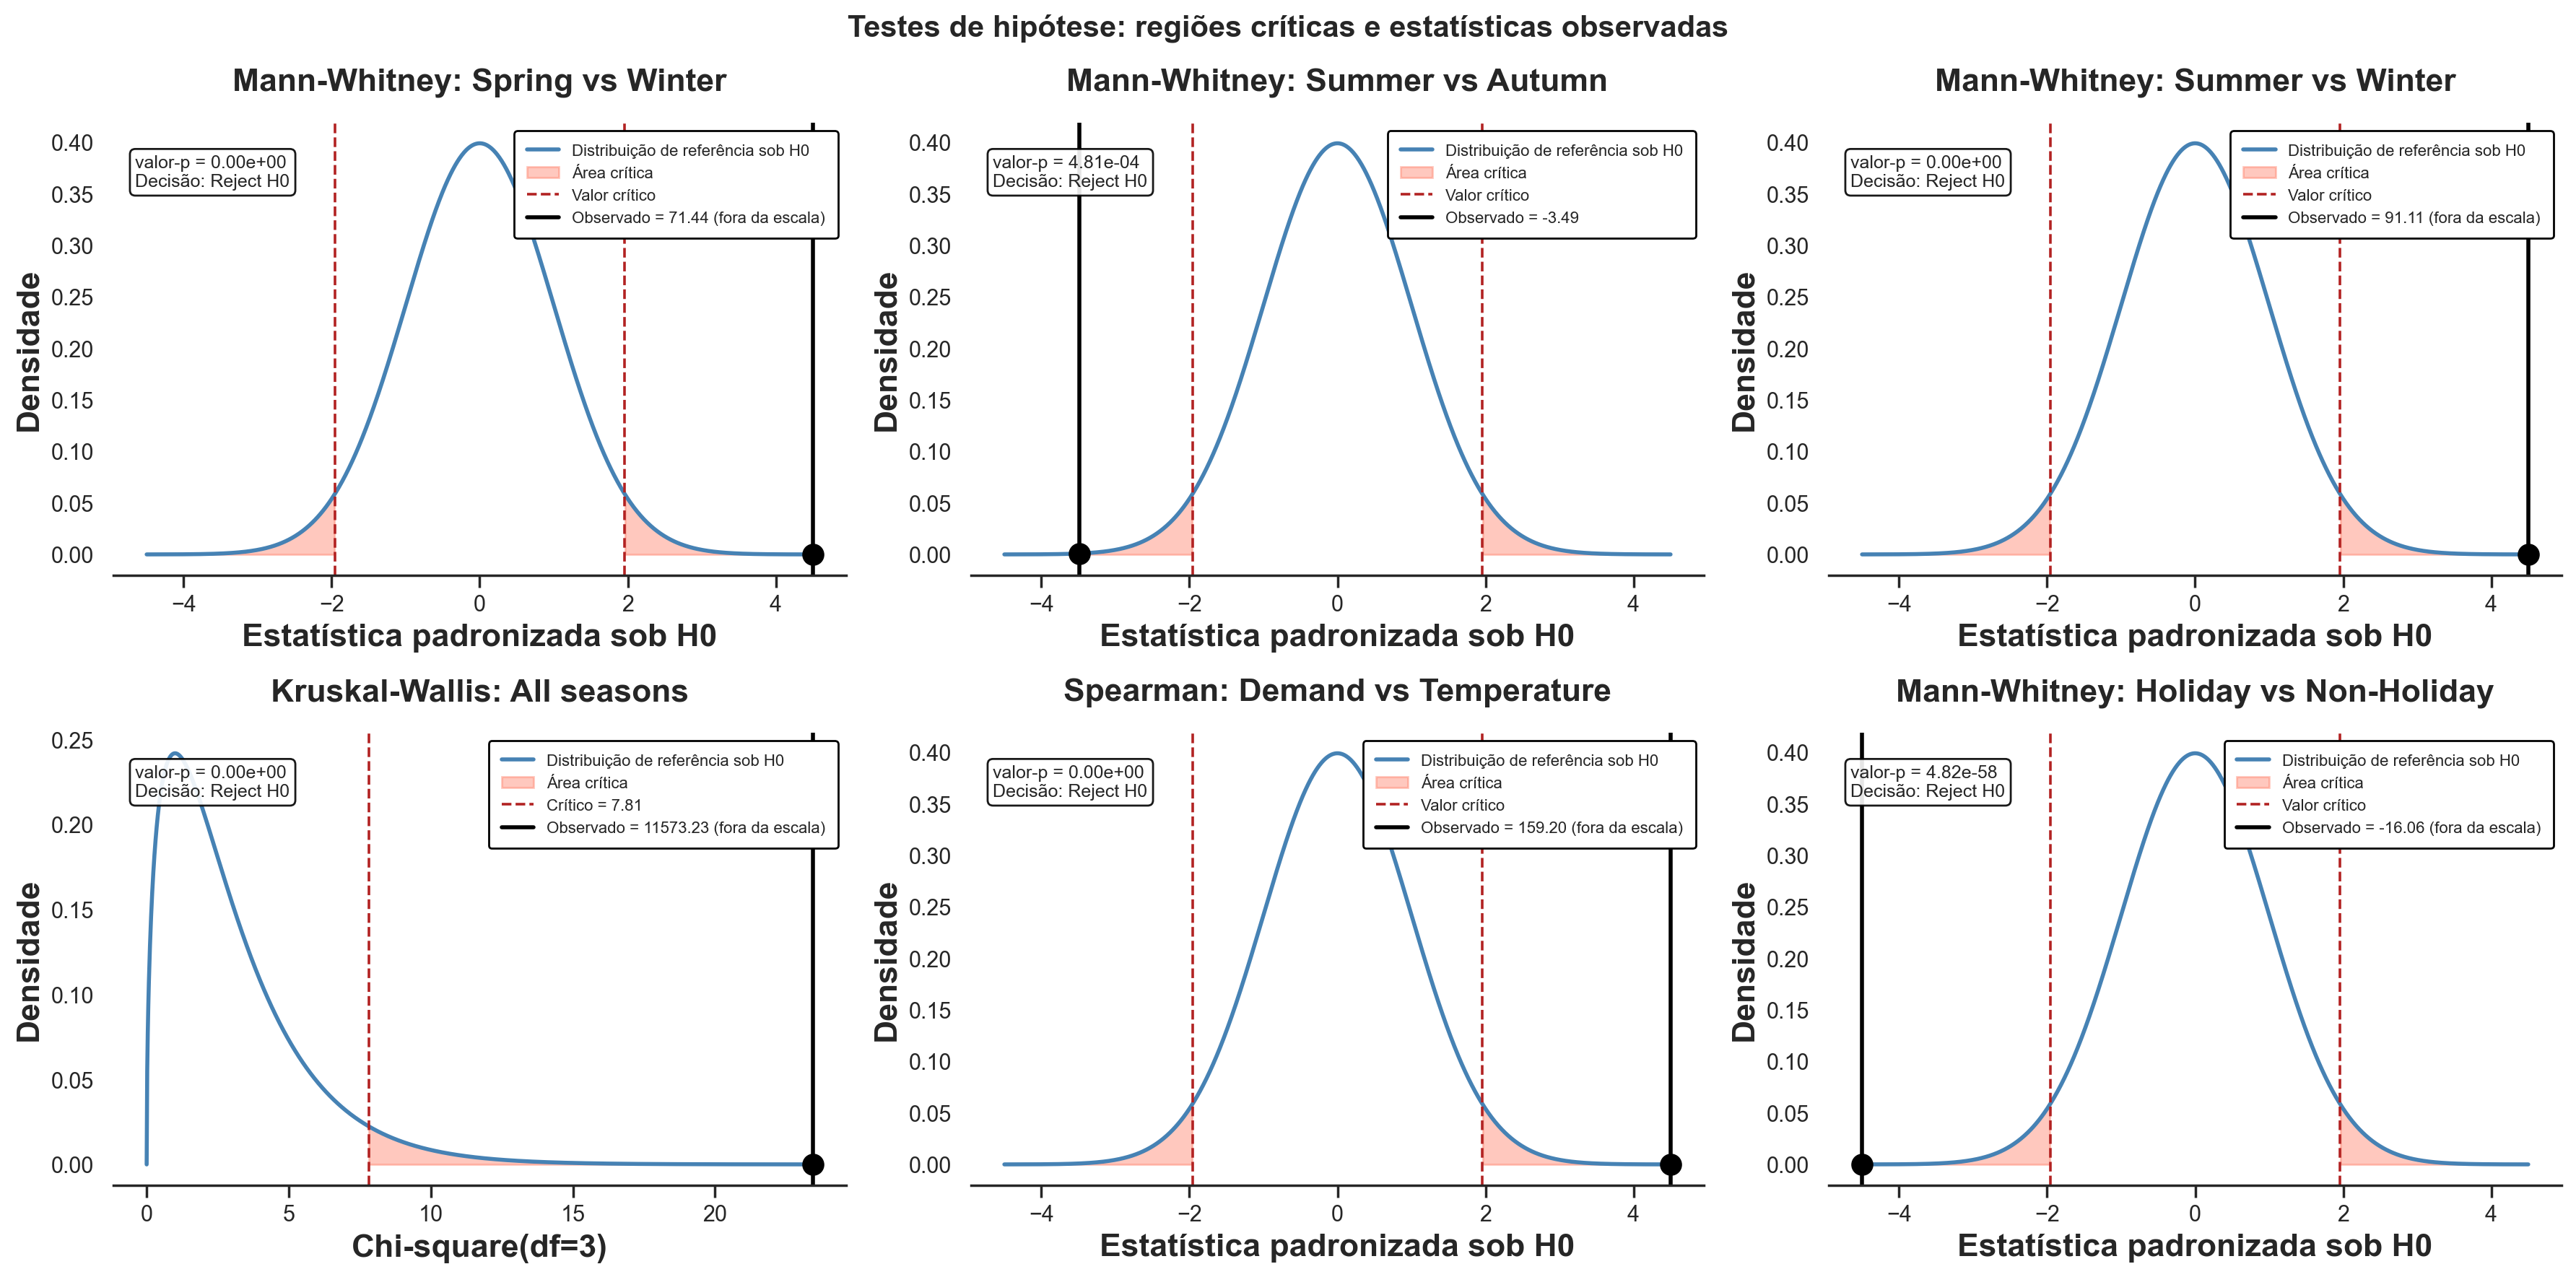

In [14]:
seasonal_results = st.seasonal_hypothesis_tests(mv_df, alpha=0.05)
display(st.localize_report(seasonal_results, lang=lang))
st.plot_seasonal_hypothesis_tests(seasonal_results, lang=lang)
plt.show()


In [15]:
# Relatório compacto: magnitude prática e inferência ajustada por multiplicidade
seasonal_report = st.localize_report(st.seasonal_report_table(seasonal_results), lang=lang)
seasonal_labels = lang({
    'effect_size': 'Tamanho do efeito',
    'p_value': 'valor-p',
    'holm_p_value': 'valor-p de Holm',
})
print(seasonal_report.to_string(index=False, formatters={
    seasonal_labels['effect_size']: '{:.3f}'.format,
    seasonal_labels['p_value']: '{:.3e}'.format,
    seasonal_labels['holm_p_value']: '{:.3e}'.format,
}))


                               Teste             N           Medianas dos grupos Medida de efeito Tamanho do efeito   valor-p valor-p de Holm Decisão de Holm
  Mann-Whitney: Primavera vs Inverno 19178 / 19540                 0.837 / 0.369  rank-biserial r             0.419 0.000e+00       0.000e+00      Rejeita H₀
       Mann-Whitney: Verão vs Outono 17594 / 18992                 1.023 / 1.070  rank-biserial r            -0.021 4.814e-04       4.814e-04      Rejeita H₀
      Mann-Whitney: Verão vs Inverno 17594 / 19540                 1.023 / 0.369  rank-biserial r             0.547 0.000e+00       0.000e+00      Rejeita H₀
   Kruskal-Wallis: Todas as estações         75304 0.837 / 1.023 / 1.070 / 0.369  epsilon-squared             0.154 0.000e+00       0.000e+00      Rejeita H₀
    Spearman: Demanda vs Temperatura         75304                           NaN     Spearman rho             0.502 0.000e+00       0.000e+00      Rejeita H₀
Mann-Whitney: Feriado vs Não feriado  3745 / 71559  

> **Insights dos testes de hipótese sazonais**
>
> As seis hipóteses foram rejeitadas tanto pelo critério nominal quanto após a correção de Holm. Os valores apresentados como `0.000e+00` não representam probabilidade matematicamente nula; o limite numérico da representação computacional foi ultrapassado por estatísticas muito distantes da distribuição de referência. Com a grande amostra horária, a rejeição de $H_0$ não deve ser confundida com relevância prática.
>
> Os contrastes que envolveram o inverno produziram as diferenças sazonais mais expressivas. Entre primavera e inverno, medianas de `0,837` e `0,369` foram observadas, com $r_{rb}=0,419$. Entre verão e inverno, as medianas foram `1,023` e `0,369`, com $r_{rb}=0,547$. Pelo teste global, foi obtido $H=11.573,23$ e $\epsilon^2=0,154$, de modo que uma heterogeneidade sazonal relevante foi sustentada para o índice de demanda. A rejeição global, isoladamente, não permite afirmar que todas as estações diferem entre si.
>
> O contraste verão–outono demonstrou o efeito do tamanho amostral sobre a significância: embora `p=0,000481` tenha permanecido significativo após Holm, medianas próximas foram obtidas (`1,023` e `1,070`) e o tamanho de efeito foi praticamente nulo ($r_{rb}=-0,021$). Foi detectada uma diferença estatística, mas não foi sustentada uma separação operacionalmente importante entre essas duas distribuições.
>
> Uma associação monotônica positiva de magnitude moderada foi observada entre temperatura e demanda relativa ($\rho_s=0,502$). Assim, índices mais altos tendem a acompanhar temperaturas mais elevadas, mas a associação permaneceu distante de uma ordenação perfeita e uma parcela substancial da variação relativa não foi descrita pela temperatura isolada. Como temperatura e estação compartilham estrutura temporal, um efeito causal independente da temperatura não foi identificado.
>
> Nos feriados, foi observada mediana de `0,449`, contra `0,730` nos demais dias, com $r_{rb}=-0,155$. Uma redução relativa foi indicada, mas o efeito foi pequeno e os grupos foram fortemente desbalanceados (`3.745` contra `71.559` observações). Diferenças de calendário, clima, hora e regime operacional não foram controladas; portanto, um efeito causal de feriado não foi demonstrado.
>
> Como a dependência temporal das observações horárias não foi incorporada aos testes, a evidência inferencial deve ser considerada exploratória. Os tamanhos de efeito e a estabilidade na validação temporal receberão prioridade sobre os valores-p no processo de modelagem. `Seasons`, `Temperature(C)` e `Holiday` serão mantidas como features candidatas, e sua utilidade final será delegada aos seletores e estimadores avaliados fora da amostra.

## 6. Seleção de features: Chi², ANOVA e F-regression

São aplicados três filtros univariados complementares. Pelo Chi², é examinada a associação entre cada feature categórica e faixas da demanda; pela ANOVA, é examinada a separação das médias de cada feature numérica entre essas faixas; pela F-regression, é examinada diretamente a associação linear entre cada coluna codificada e o índice contínuo. Como cada preditor é avaliado isoladamente, interações, redundâncias condicionais e ganho incremental na presença das demais features não são medidos.

Para Chi² e ANOVA, o índice des-tendenciado é discretizado por `pd.qcut` em cinco quantis de frequência aproximadamente igual, de `Q1` a `Q5`. Essas faixas são produzidas apenas dentro desta análise exploratória e não são acrescentadas a `mv_df`. Se fossem calculadas antes da separação entre treino e validação em um pipeline preditivo, informação da distribuição completa do alvo seria incorporada ao pré-processamento e leakage seria introduzido. A F-regression utiliza o índice contínuo, sem essa discretização.

O nível nominal é fixado em `α=0,05`, e a correção de Holm é aplicada separadamente à família de features examinada por cada método. A decisão ajustada é utilizada como controle de multiplicidade, mas o grande número de observações horárias e a dependência temporal tornam os valores-p insuficientes para seleção. Por isso, V de Cramér, `η²` e `R²` univariado são priorizados na interpretação.

### Chi² de independência para features categóricas

Para cada variável categórica, é construída uma tabela de contingência entre suas categorias e os cinco quantis do alvo. Sob $H_0$, independência entre as duas classificações é assumida; sob $H_1$, alguma associação é admitida. A estatística de [Pearson (1900)](https://doi.org/10.1080/14786440009463897) é calculada diretamente sobre as frequências observadas e esperadas. Com isso, categorias nominais não recebem códigos inteiros artificiais, e os graus de liberdade são calculados como `(n_linhas − 1) × (n_colunas − 1)` para cada tabela.

Como a estatística Chi² cresce com o tamanho amostral e com a dimensão da tabela, o ranking não é produzido pelo valor bruto. A intensidade padronizada é resumida pelo V de Cramér, limitado ao intervalo `[0, 1]`. Também são apresentados a menor frequência esperada e o percentual de células com frequência esperada inferior a 5; assim, a adequação da aproximação assintótica pode ser verificada em vez de presumida.

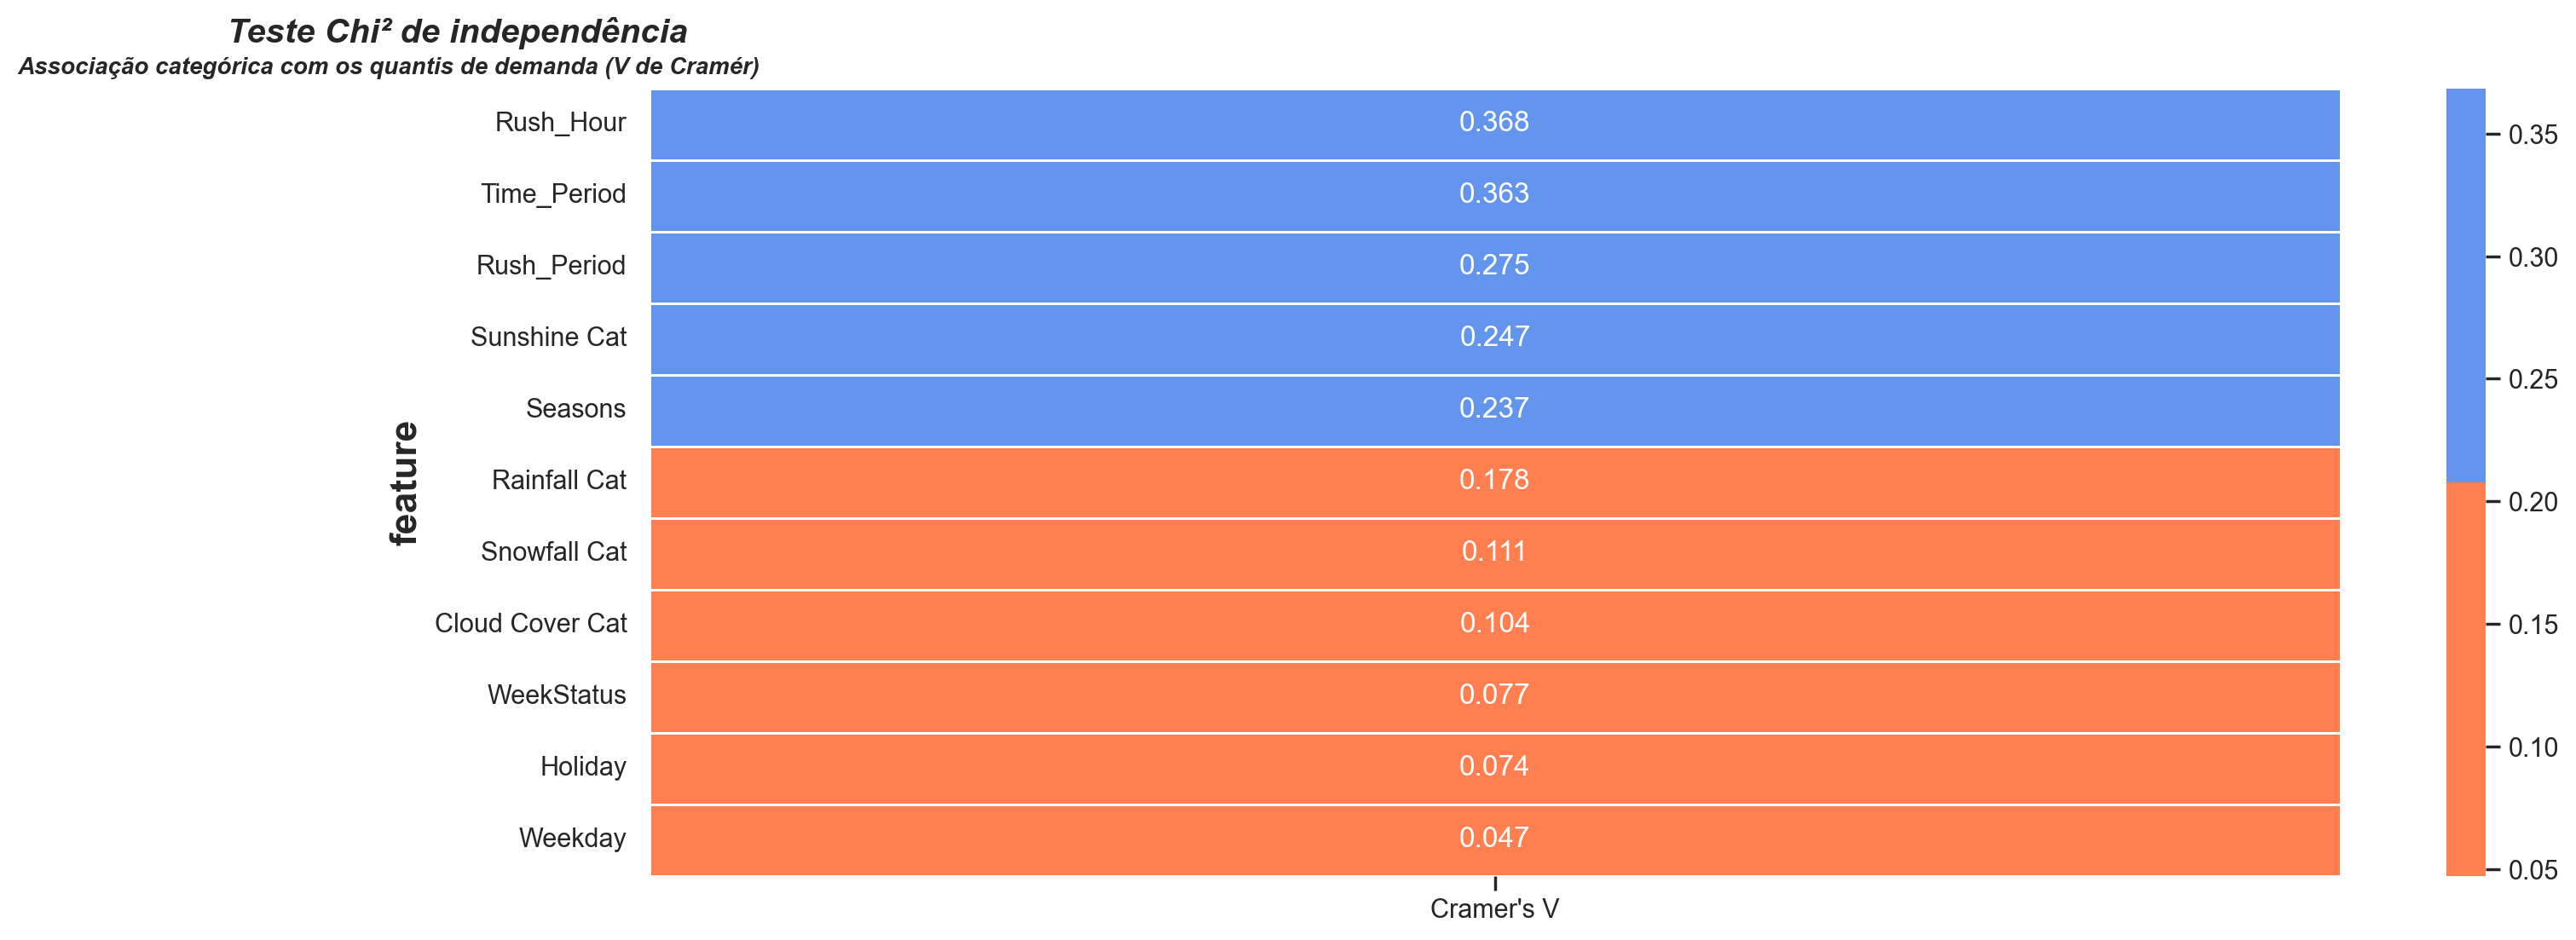

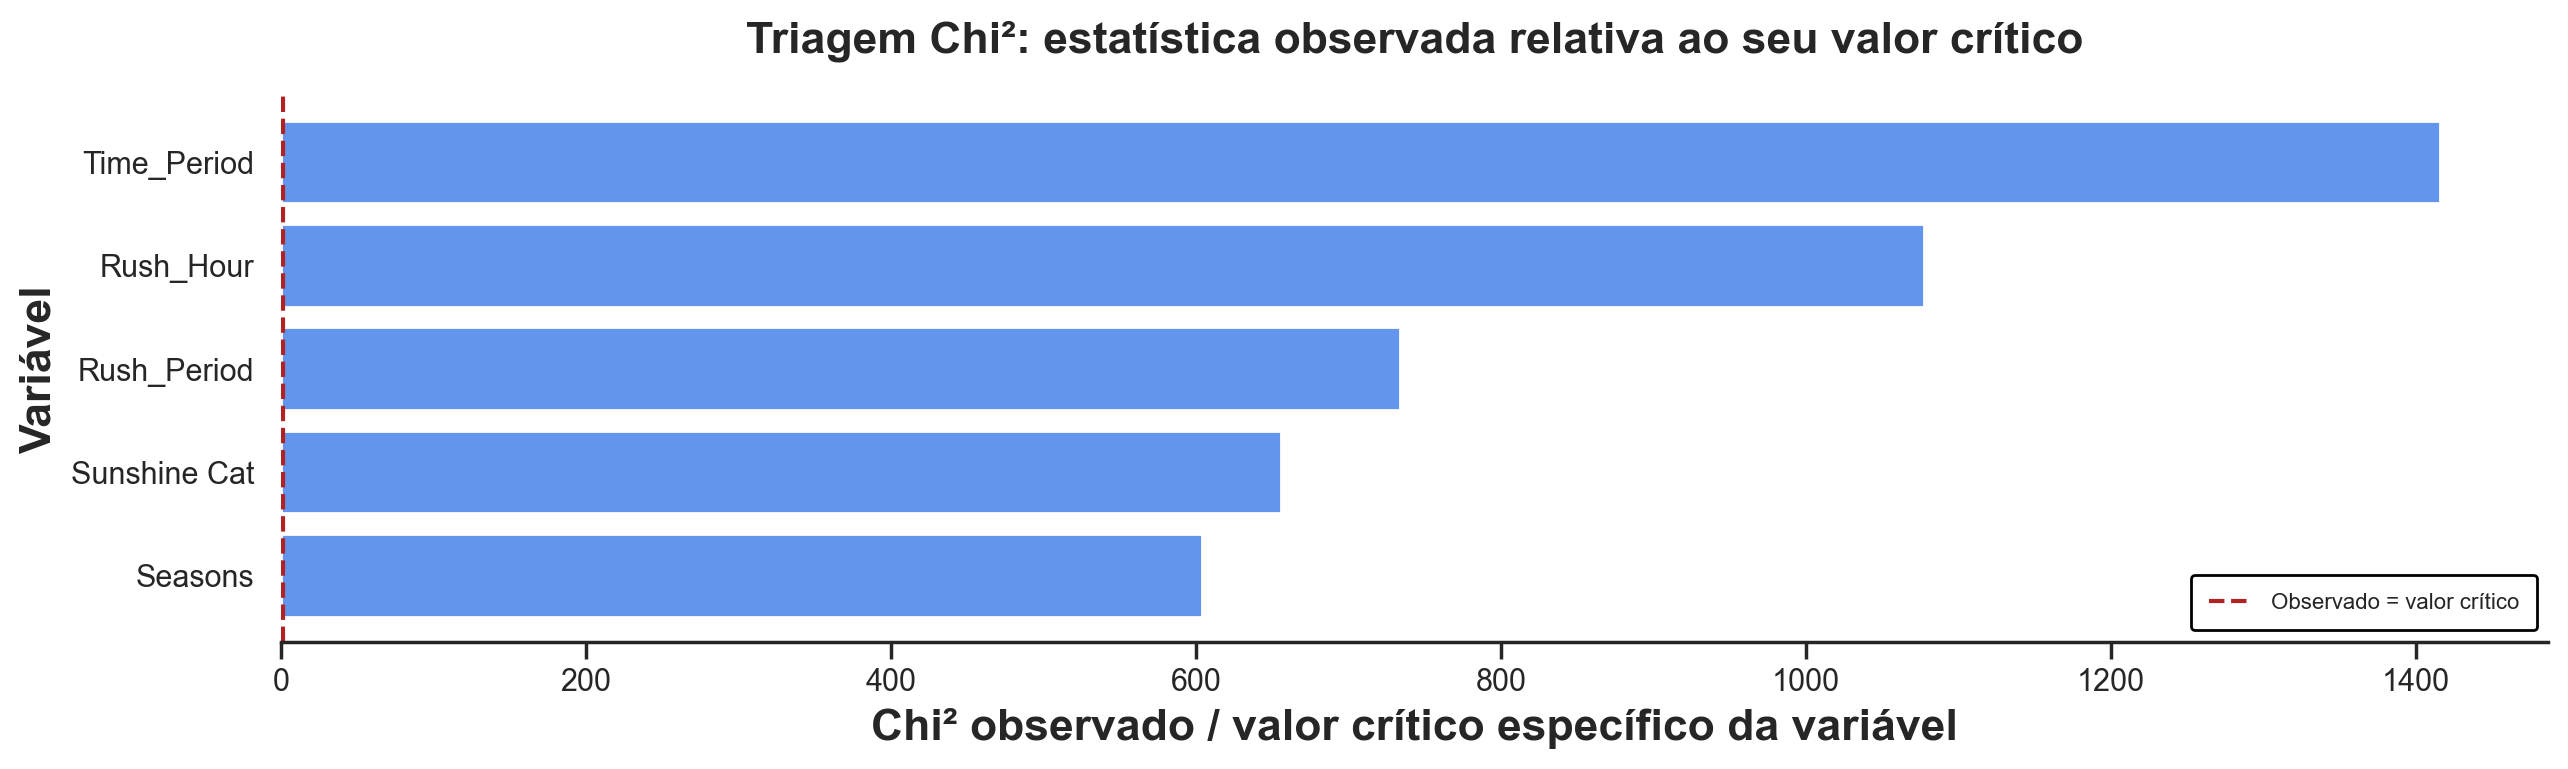

,V de Cramér,Estatística Qui-quadrado,df,Contagem mínima esperada,Células esperadas < 5% (%),valor-p de Holm,Decisão de Holm
feature,,,,,,,
Rush_Hour,0.368500,10225.684780,4,2975.441942,0.0,0.000000e+00,Rejeita H₀
Time_Period,0.363051,29776.534326,12,3743.001169,0.0,0.000000e+00,Rejeita H₀
Rush_Period,0.274896,11381.150319,8,1275.932221,0.0,0.000000e+00,Rejeita H₀
Sunshine Cat,0.247019,13784.770740,12,779.158610,0.0,0.000000e+00,Rejeita H₀
Seasons,0.237161,12706.535647,12,3518.613088,0.0,0.000000e+00,Rejeita H₀
Rainfall Cat,0.177795,7141.336576,12,66.196484,0.0,0.000000e+00,Rejeita H₀
Snowfall Cat,0.110671,2766.978593,12,64.396579,0.0,0.000000e+00,Rejeita H₀
Cloud Cover Cat,0.104440,2464.202064,12,1093.541910,0.0,0.000000e+00,Rejeita H₀
WeekStatus,0.076896,445.270554,4,4304.171359,0.0,9.147409e-95,Rejeita H₀


In [16]:
chi_scores, _, _ = st.chi_square_feature_selection(
    mv_df, target_col=TARGET, alpha=0.05, lang=lang)
plt.show()
st.plot_chi_square_critical_region(chi_scores, lang=lang)
plt.show()
chi_report = st.chi_square_report(chi_scores)
display(st.localize_report(chi_report, lang=lang))


### ANOVA como triagem de features numéricas

A análise de variância desenvolvida na tradição de [Fisher (1925)](https://openlibrary.org/works/OL1153861W/Statistical_methods_for_research_workers) é aplicada em uma orientação específica: cada feature numérica é tratada como variável analisada, e os cinco quantis do índice de demanda são tratados como grupos. Sob $H_0$, as médias da feature são iguais entre `Q1` e `Q5`; sob $H_1$, pelo menos uma média difere. Portanto, separação entre níveis de demanda é examinada, mas uma relação linear com o alvo não é necessariamente estabelecida.

A razão entre variabilidade intergrupo e intragrupo é resumida pela estatística F. Como os graus de liberdade são iguais para todas as features deste bloco, o ranking por F coincide com o ranking por `η²`; ainda assim, `η²` é apresentado por possuir escala interpretável como fração da variabilidade da feature associada às faixas do alvo. Os valores-p são ajustados por Holm.

Normalidade condicional, homogeneidade das variâncias e independência das observações são pressupostos da referência F clássica e não são demonstrados pelos dados horários. Além disso, `Hour`, `Month` e `DayNumberOnWeek` são representações cíclicas armazenadas como números, de modo que distâncias nas extremidades da escala podem ser interpretadas inadequadamente. Os resultados são utilizados como triagem relativa, não como inferência causal nem como justificativa automática para descarte.

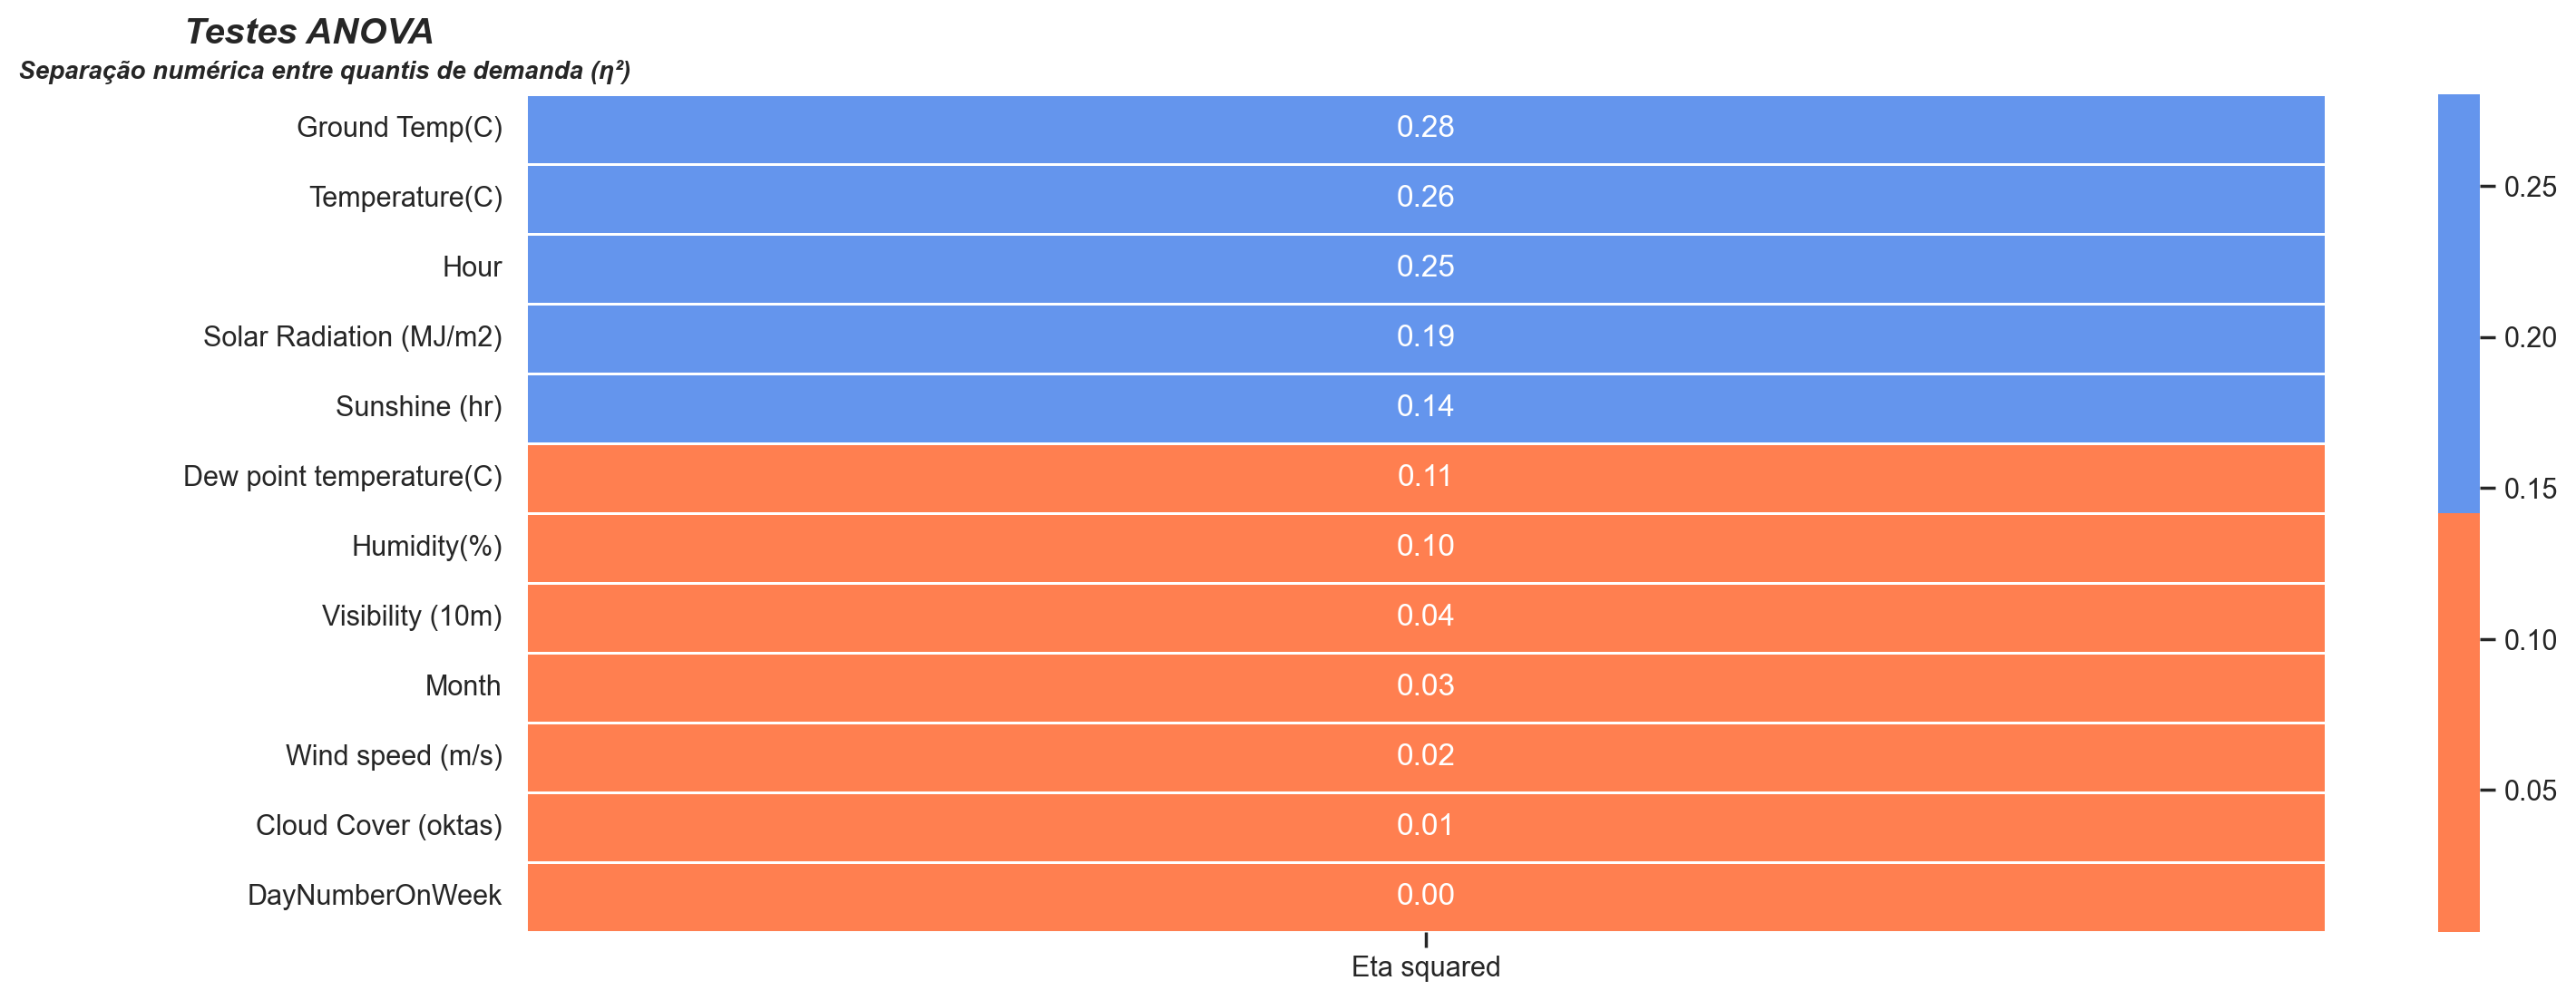

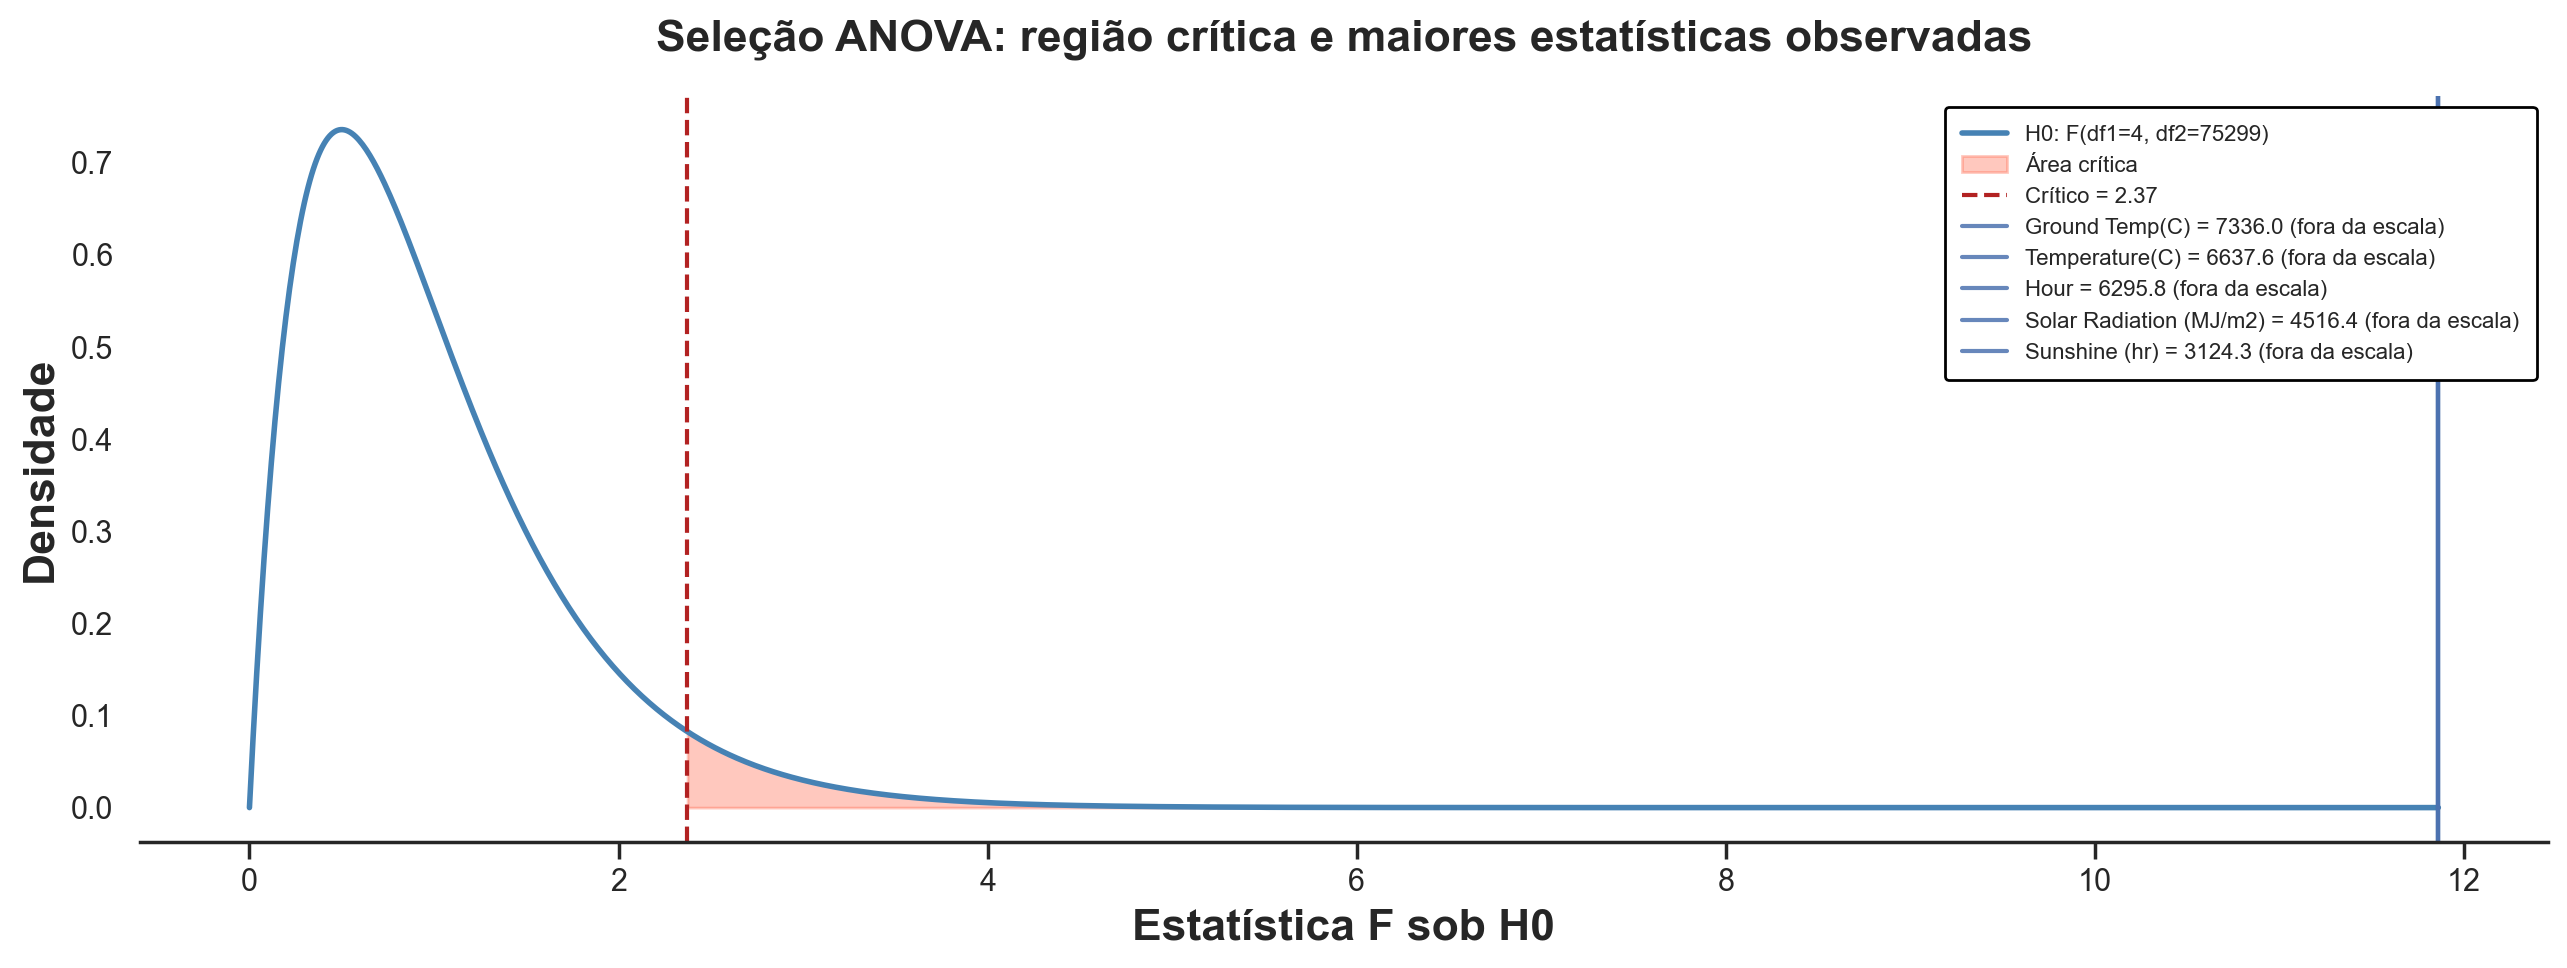

,Eta ao quadrado (η²),Estatística ANOVA,df1,df2,valor-p de Holm,Decisão de Holm
Ground Temp(C),0.280419,7335.952297,4,75299,0.000000e+00,Rejeita H₀
Temperature(C),0.260683,6637.594907,4,75299,0.000000e+00,Rejeita H₀
Hour,0.250624,6295.812062,4,75299,0.000000e+00,Rejeita H₀
Solar Radiation (MJ/m2),0.193497,4516.449503,4,75299,0.000000e+00,Rejeita H₀
Sunshine (hr),0.142342,3124.270962,4,75299,0.000000e+00,Rejeita H₀
Dew point temperature(C),0.105675,2224.356827,4,75299,0.000000e+00,Rejeita H₀
Humidity(%),0.098514,2057.154796,4,75299,0.000000e+00,Rejeita H₀
Visibility (10m),0.039329,770.661866,4,75299,0.000000e+00,Rejeita H₀
Month,0.025510,492.785453,4,75299,0.000000e+00,Rejeita H₀
Wind speed (m/s),0.018855,361.763064,4,75299,1.220853e-308,Rejeita H₀


In [17]:
num_features = [c for c in mv_df.select_dtypes(include=[np.number]).columns
                if c not in (TARGET, 'is_anomalous_2020')]
target_bins = pd.qcut(mv_df[TARGET], q=5, labels=[f'Q{i}' for i in range(1, 6)])

anova_scores, _, _ = st.anova_feature_selection(
    mv_df, num_features, target_bins, alpha=0.05, lang=lang)
plt.show()
st.plot_anova_critical_region(anova_scores, lang=lang)
plt.show()
anova_report = st.anova_report(anova_scores)
display(st.localize_report(anova_report, lang=lang))


### F-regression sobre o índice contínuo

Na F-regression, a discretização do alvo é abandonada e uma regressão linear simples é ajustada separadamente entre cada coluna e o índice contínuo. Conforme a [documentação do scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_regression.html), a correlação de Pearson entre cada regressor e o alvo é convertida em uma estatística F e em seu valor-p. Features categóricas são previamente representadas por variáveis indicadoras com `drop_first=True`; assim, cada dummy retida é examinada isoladamente, e a categoria omitida não recebe um escore próprio.

O `R²` univariado é apresentado como medida da intensidade linear de cada coluna. A antiga denominação `Contribution (%)` é substituída por `Relative F share (%)`, pois a participação de cada F na soma dos escores é apenas uma normalização para visualização: os valores F são calculados em modelos separados, não são componentes aditivos e não representam percentuais independentes da demanda explicada.

Associações não lineares, interações e utilidade incremental não são capturadas. Variáveis redundantes podem receber simultaneamente escores altos, enquanto uma feature útil apenas em combinação pode receber escore baixo. A correção de Holm é aplicada aos valores-p, mas a ordenação prática é produzida pelo `R²` univariado e deve ser confrontada com os seletores multivariados e a validação temporal do pipeline.

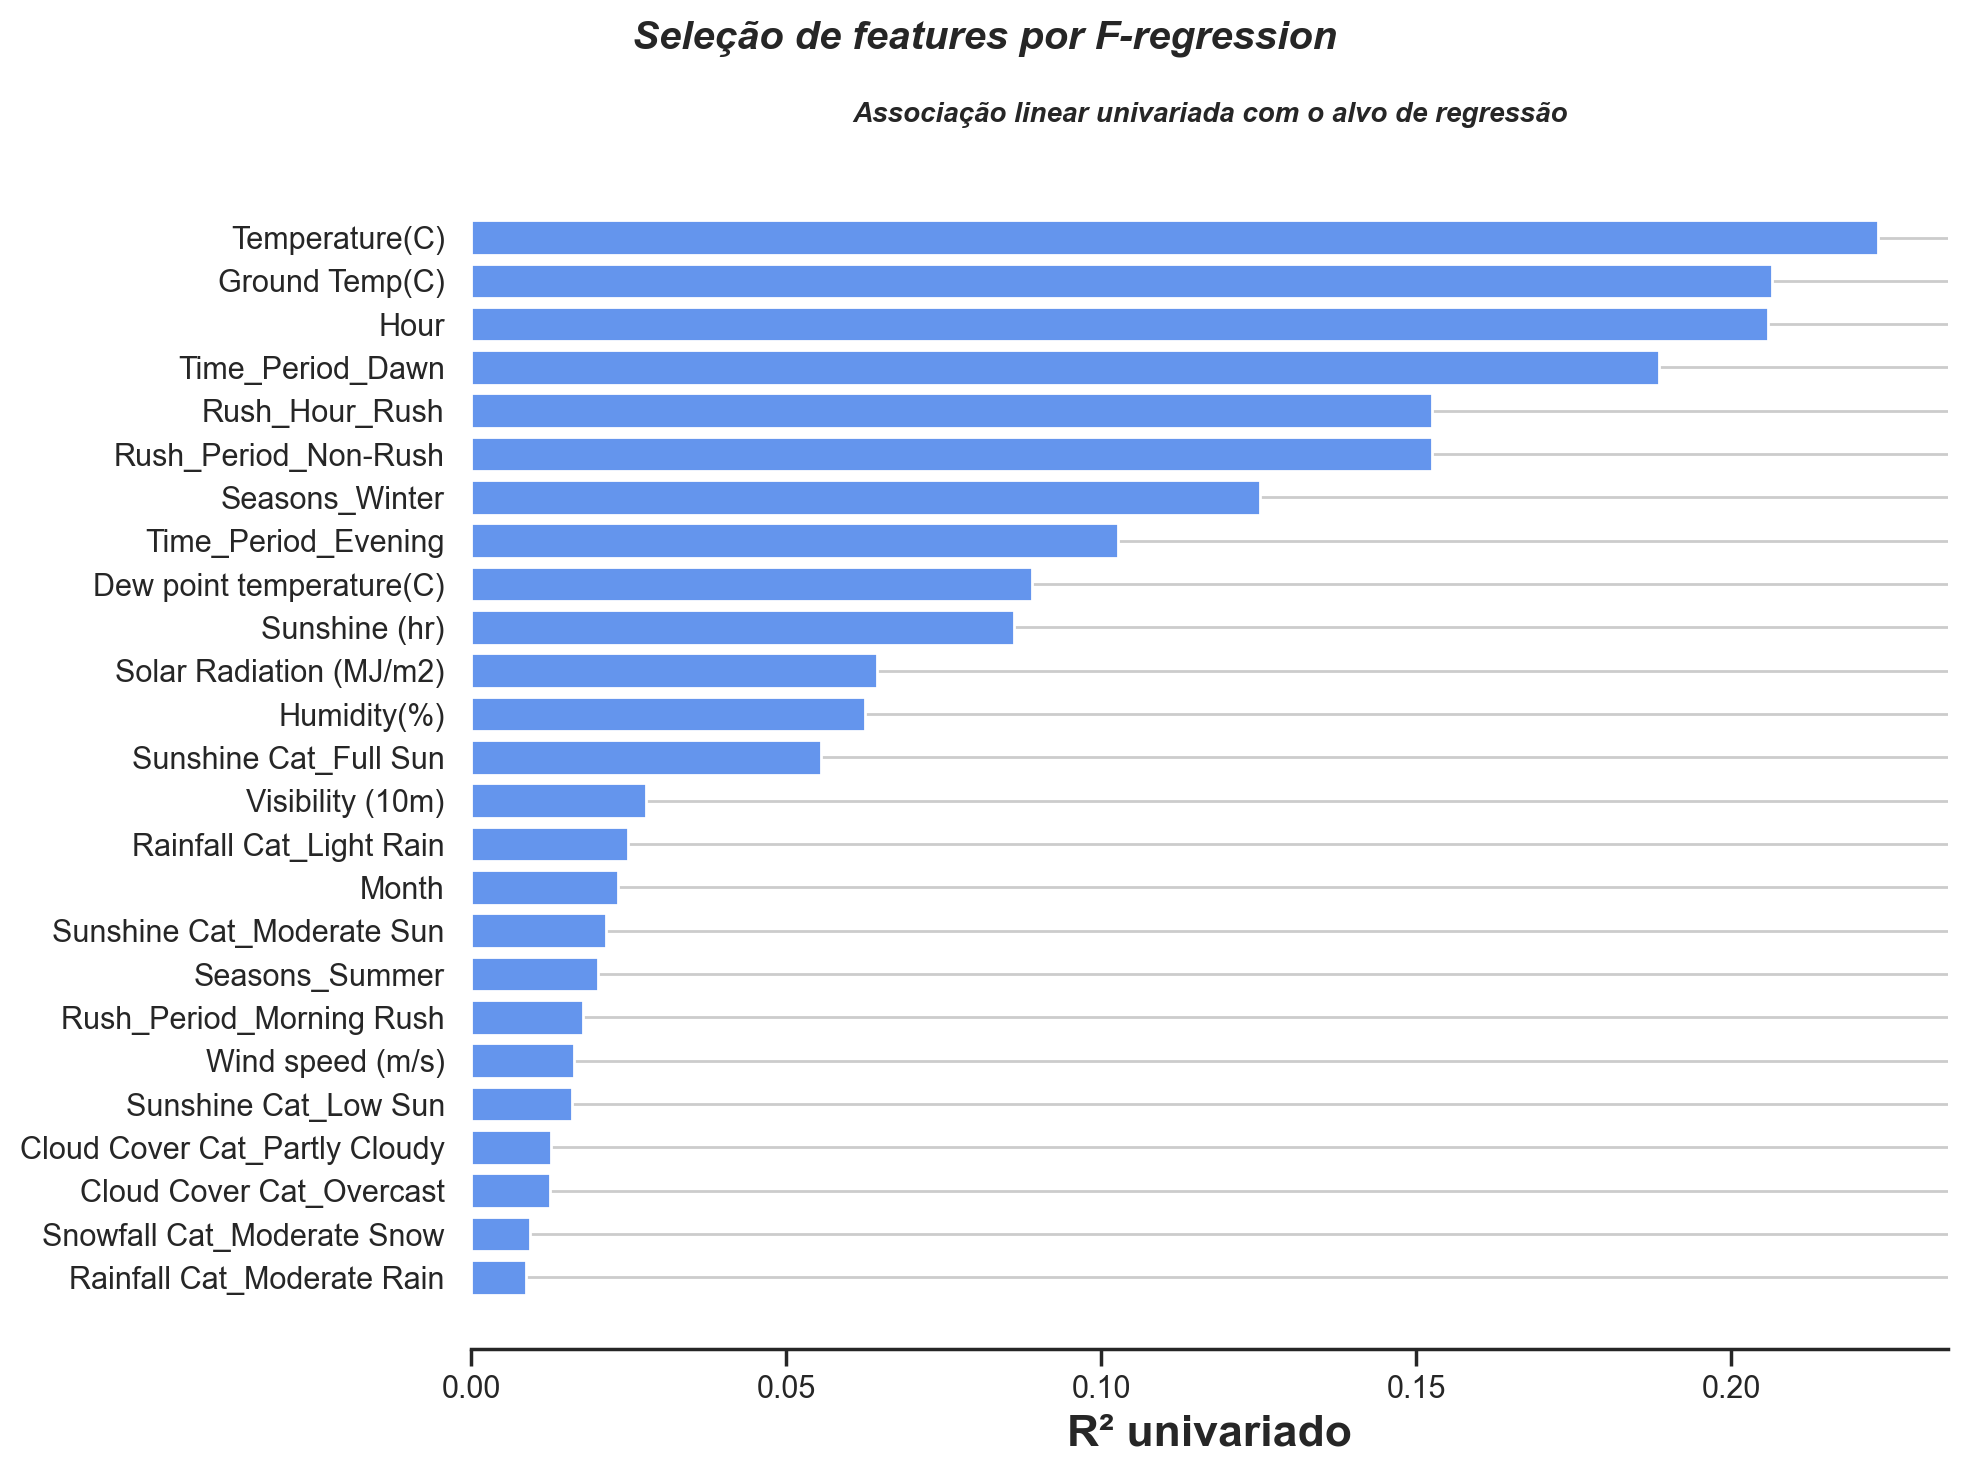

,R² univariado,Estatística F,Participação relativa de F (%),valor-p de Holm,Decisão de Holm
Temperature(C),0.223323,21652.089603,12.530342,0.0,Rejeita H₀
Ground Temp(C),0.206420,19586.948817,11.335219,0.0,Rejeita H₀
Hour,0.205860,19520.071740,11.296516,0.0,Rejeita H₀
Time_Period_Dawn,0.188519,17493.717104,10.123839,0.0,Rejeita H₀
Rush_Hour_Rush,0.152529,13552.941631,7.843261,0.0,Rejeita H₀
Rush_Period_Non-Rush,0.152529,13552.941631,7.843261,0.0,Rejeita H₀
Seasons_Winter,0.125186,10775.758839,6.236070,0.0,Rejeita H₀
Time_Period_Evening,0.102673,8616.136487,4.986269,0.0,Rejeita H₀
Dew point temperature(C),0.089086,7364.440998,4.261897,0.0,Rejeita H₀
Sunshine (hr),0.086121,7096.237173,4.106684,0.0,Rejeita H₀


In [18]:
f_scores, _, _ = st.f_regression_feature_selection(
    mv_df, target_col=TARGET, alpha=0.05, top_n=25, lang=lang)
plt.show()
f_report = st.f_regression_report(f_scores)
display(st.localize_report(f_report.head(15), lang=lang))


### Relatório consolidado para interpretação

Os blocos de cálculo anteriores foram atualizados para as novas métricas e regenerarão seus gráficos quando a seção for executada. O relatório textual salvo a seguir reúne os resultados corrigidos que fundamentam o insight: V de Cramér para Chi², `η²` para ANOVA e `R²` univariado para F-regression.

In [19]:
# Relatório compacto de tamanho de efeito (tabelas preparadas em src.stats_tests)
print(st.univariate_selection_summary(chi_report, anova_report, f_report, lang=lang))


CHI-SQUARE — features categóricas
                V de Cramér  df Contagem mínima esperada valor-p de Holm Decisão de Holm
feature                                                                                 
Rush_Hour             0.368   4                   2975.4       0.000e+00      Rejeita H₀
Time_Period           0.363  12                   3743.0       0.000e+00      Rejeita H₀
Rush_Period           0.275   8                   1275.9       0.000e+00      Rejeita H₀
Sunshine Cat          0.247  12                    779.2       0.000e+00      Rejeita H₀
Seasons               0.237  12                   3518.6       0.000e+00      Rejeita H₀
Rainfall Cat          0.178  12                     66.2       0.000e+00      Rejeita H₀
Snowfall Cat          0.111  12                     64.4       0.000e+00      Rejeita H₀
Cloud Cover Cat       0.104  12                   1093.5       0.000e+00      Rejeita H₀
WeekStatus            0.077   4                   4304.2       9.147e-95    

> **Insights da seleção univariada de features**
>
> Após o Chi² ter sido calculado diretamente sobre tabelas de contingência, todas as dez features categóricas permaneceram associadas aos quantis da demanda pelo critério de Holm. As maiores intensidades foram obtidas para `Time_Period` (`V=0,363`), `Rush_Hour` (`V=0,356`), `Sunshine Cat` (`V=0,247`) e `Seasons` (`V=0,237`). Para `Weekday` (`V=0,047`), `Holiday` (`V=0,074`) e `WeekStatus` (`V=0,077`), associações fracas foram observadas apesar dos valores-p reduzidos.
>
> A aproximação Chi² não foi fragilizada por frequências esperadas pequenas: nenhuma célula apresentou expectativa inferior a 5, e o menor valor foi `64,4`. A mudança metodológica alterou o ranking anterior porque a magnitude dos códigos atribuídos pelo `LabelEncoder` deixou de participar do cálculo. A interpretação passou a depender somente das frequências conjuntas das categorias e dos quantis.
>
> Na ANOVA, a maior separação entre quantis de demanda foi obtida para `Ground Temp(C)` (`η²=0,280`), `Temperature(C)` (`η²=0,261`), `Hour` (`η²=0,251`), `Solar Radiation (MJ/m2)` (`η²=0,193`) e `Sunshine (hr)` (`η²=0,142`). Embora todas as features tenham permanecido significativas após Holm, efeitos muito pequenos foram obtidos para `DayNumberOnWeek` (`η²=0,003`) e `Cloud Cover (oktas)` (`η²=0,008`). Foi reforçada, assim, a necessidade de separar significância de capacidade discriminatória.
>
> Pela F-regression, os maiores ajustes lineares isolados foram produzidos por `Temperature(C)` (`R²=0,223`), `Ground Temp(C)` (`R²=0,206`), `Hour` (`R²=0,206`), `Time_Period_Dawn` (`R²=0,189`), `Rush_Hour_Rush` (`R²=0,141`) e `Seasons_Winter` (`R²=0,125`). Apenas `Weekday_Monday` não permaneceu significativo após Holm, mas seu `R²=0,000021` também confirmou ausência de relevância linear isolada. Não foi demonstrada irrelevância global de `Weekday`: pelo Chi², a variável completa permaneceu associada aos quantis, enquanto a F-regression avaliou somente o indicador específico de segunda-feira.
>
> A concordância entre ANOVA e F-regression colocou temperatura, temperatura do solo e hora entre os sinais univariados mais fortes. Essa convergência não deve ser interpretada como contribuição independente: colinearidade elevada foi demonstrada entre as variáveis térmicas, e representações derivadas de hora e estação compartilham informação. Os `R²` e os escores F não podem ser somados para estimar a demanda explicada pelo conjunto.
>
> Os três métodos medem objetos diferentes e, por isso, seus rankings não precisam coincidir. O Chi² depende da discretização de ambos os lados; a ANOVA mede separação das médias da feature entre quantis do alvo; e a F-regression mede associação linear com o índice contínuo. Nenhum deles avalia interações, estabilidade temporal ou ganho incremental condicionado às demais features.
>
> Como decisão do projeto, nenhuma exclusão manual será executada com base nesses rankings. As faixas `Q1`–`Q5` não serão usadas como alvo ou feature de modelagem, e os resultados desta seção permanecerão como diagnóstico exploratório. A seleção efetiva será delegada a `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector` ou `NoSelector`, conforme o estimador e a validação temporal; no pipeline de otimização, o `SelectKBest` utiliza `mutual_info_regression`, e não os testes apresentados nesta seção.

## 7. Testes de Shapiro-Wilk e Anderson-Darling para normalidade

As distribuições marginais do índice de demanda des-tendenciado, da temperatura e da umidade são avaliadas nesta seção. No teste de Shapiro–Wilk, introduzido por [Shapiro e Wilk (1965)](https://doi.org/10.1093/biomet/52.3-4.591), é testada a hipótese nula de que a amostra tenha sido extraída de uma população Normal. Como é advertido na [documentação do SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html) que o valor-p pode ser impreciso para `N > 5.000`, uma amostra reprodutível de até 5.000 observações é selecionada com `random_state=42`; o tamanho original e o tamanho efetivamente testado são mantidos no relatório.

Como verificação complementar, o teste de Anderson–Darling, proposto por [Anderson e Darling (1952)](https://doi.org/10.1214/aoms/1177729437), é aplicado a todas as observações disponíveis. A estatística observada é comparada ao valor crítico de 5% fornecido para a distribuição Normal, conforme a [implementação do SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.anderson.html). Uma ênfase maior é atribuída às caudas por esse teste, mas sua estatística não constitui uma medida de tamanho de efeito e não deve ser ordenada entre variáveis como se quantificasse diretamente a importância da não normalidade.

Devido ao tamanho das amostras, pequenos desvios da Normal podem ser detectados com elevada potência. Por esse motivo, as decisões são acompanhadas pela mediana, pelo intervalo interquartil, pela assimetria e pela curtose excedente. A normalidade marginal das colunas também não é uma exigência geral da ANOVA ou da regressão: quando essa suposição é necessária, ela recai sobre os erros ou sobre as distribuições condicionais do modelo, e não automaticamente sobre cada variável isolada. Assim, uma rejeição nesta seção não determina, por si só, transformação, exclusão de feature ou substituição de todos os procedimentos paramétricos.

Como as observações são horárias e ordenadas no tempo, independência e distribuição idêntica não podem ser presumidas. Os valores-p e os valores críticos são, portanto, utilizados como diagnósticos exploratórios de forma marginal; a adequação inferencial de um modelo deverá ser verificada posteriormente sobre resíduos e validações que preservem a ordem temporal.

### Kruskal–Wallis para categorias de chuva e neve

- *`Quando temos chuva ou neve, a demanda é igual ?`*

Para as categorias de chuva e neve, é aplicado o teste global de Kruskal–Wallis, no qual é testada a hipótese nula de igualdade das distribuições entre os grupos. São apresentados os tamanhos e as medianas de cada categoria, a estatística `H` e o tamanho de efeito `ε²`. Como duas famílias meteorológicas são testadas, os valores-p são corrigidos pelo procedimento de Holm. Uma rejeição global indica que ao menos uma distribuição difere das demais, mas não identifica quais pares diferem; comparações pós-hoc seriam necessárias para essa finalidade. Diferenças sazonais, horárias e de composição entre as categorias também impedem que a associação observada seja interpretada como efeito causal da precipitação.

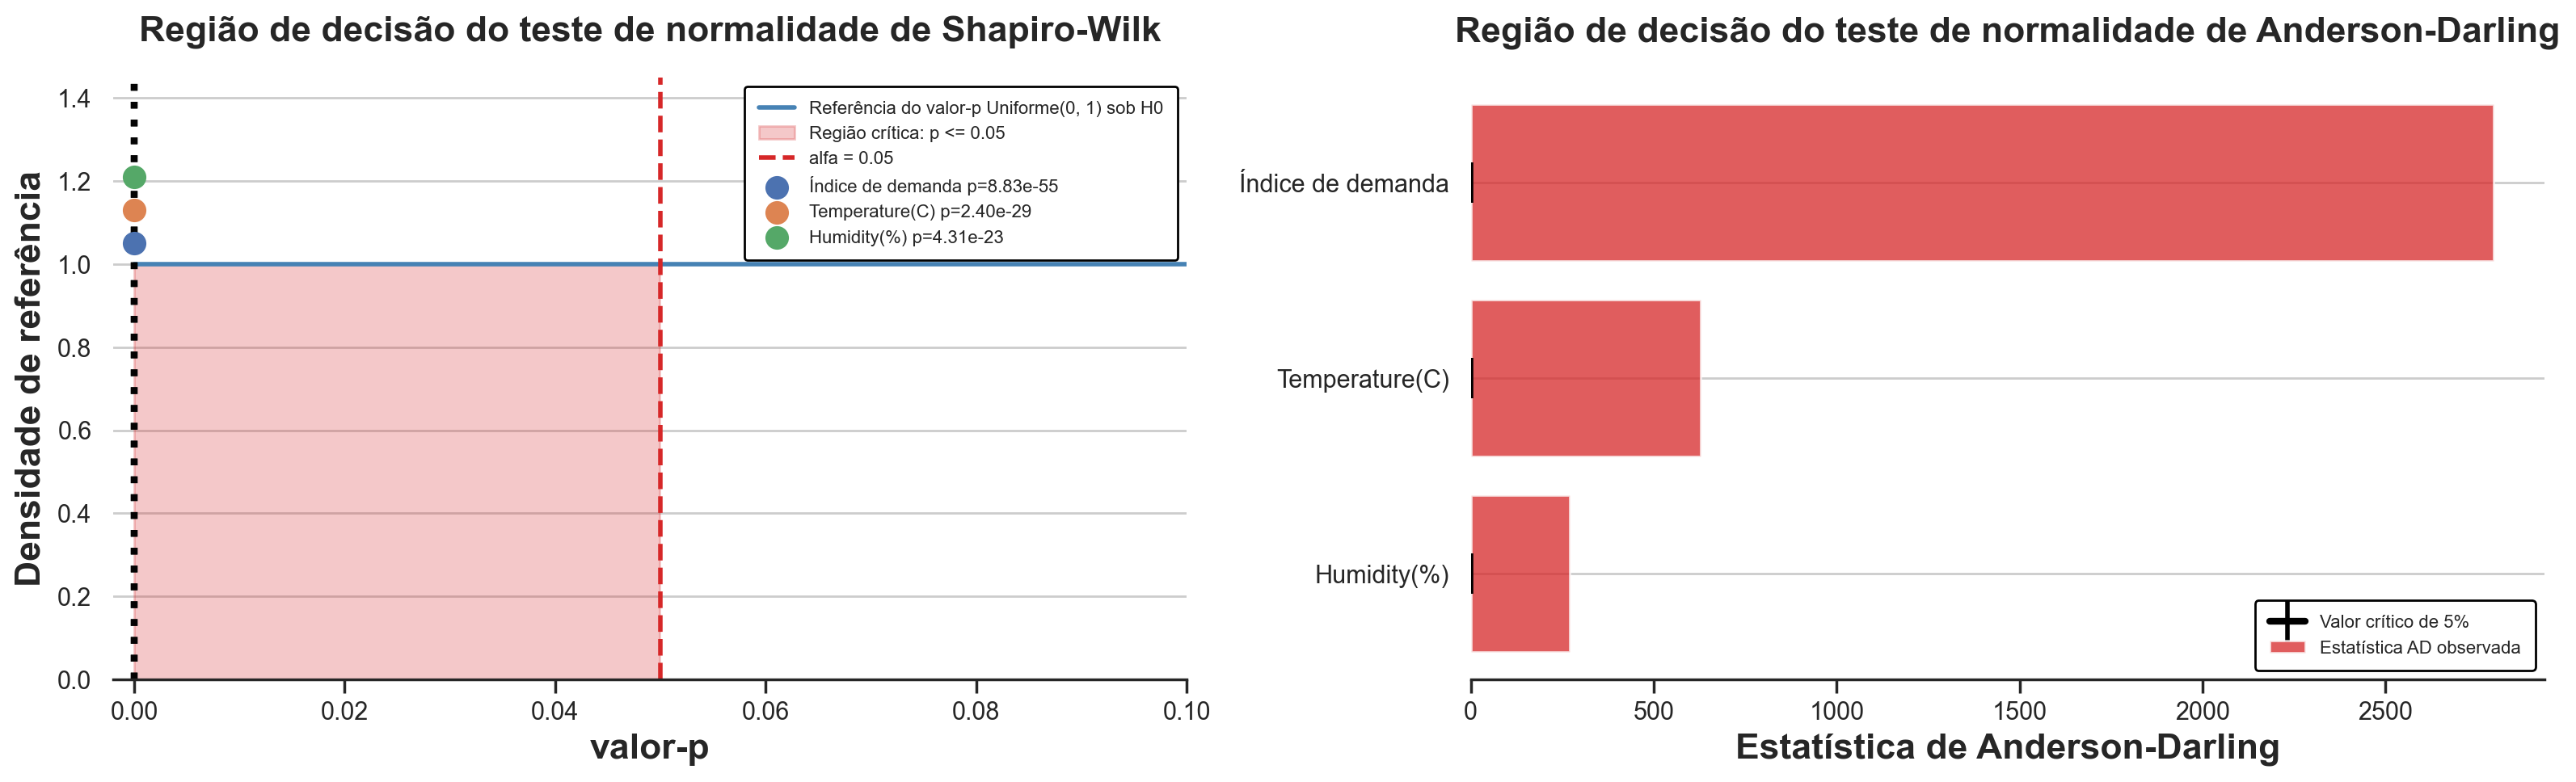

,Grupo,N,Mediana,IQR,Assimetria,Curtose em excesso,N usado (Shapiro),Estatística W (Shapiro),valor-p (Shapiro),Decisão (Shapiro),Estatística de Anderson-Darling,Valor crítico AD (5%),Nível de significância AD usado (%),Decisão (Anderson-Darling)
0,Índice de demanda,75304,0.71696,1.09044,1.505309,2.765754,5000,0.862028,8.829419e-55,Rejeita H₀,2793.909494,0.787,5.0,Rejeita H₀
1,Temperature(C),75304,14.00000,18.60000,-0.199450,-0.934866,5000,0.973788,2.399753e-29,Rejeita H₀,627.724558,0.787,5.0,Rejeita H₀
2,Humidity(%),75304,62.00000,30.00000,-0.102800,-0.829450,5000,0.984382,4.314963e-23,Rejeita H₀,269.258679,0.787,5.0,Rejeita H₀


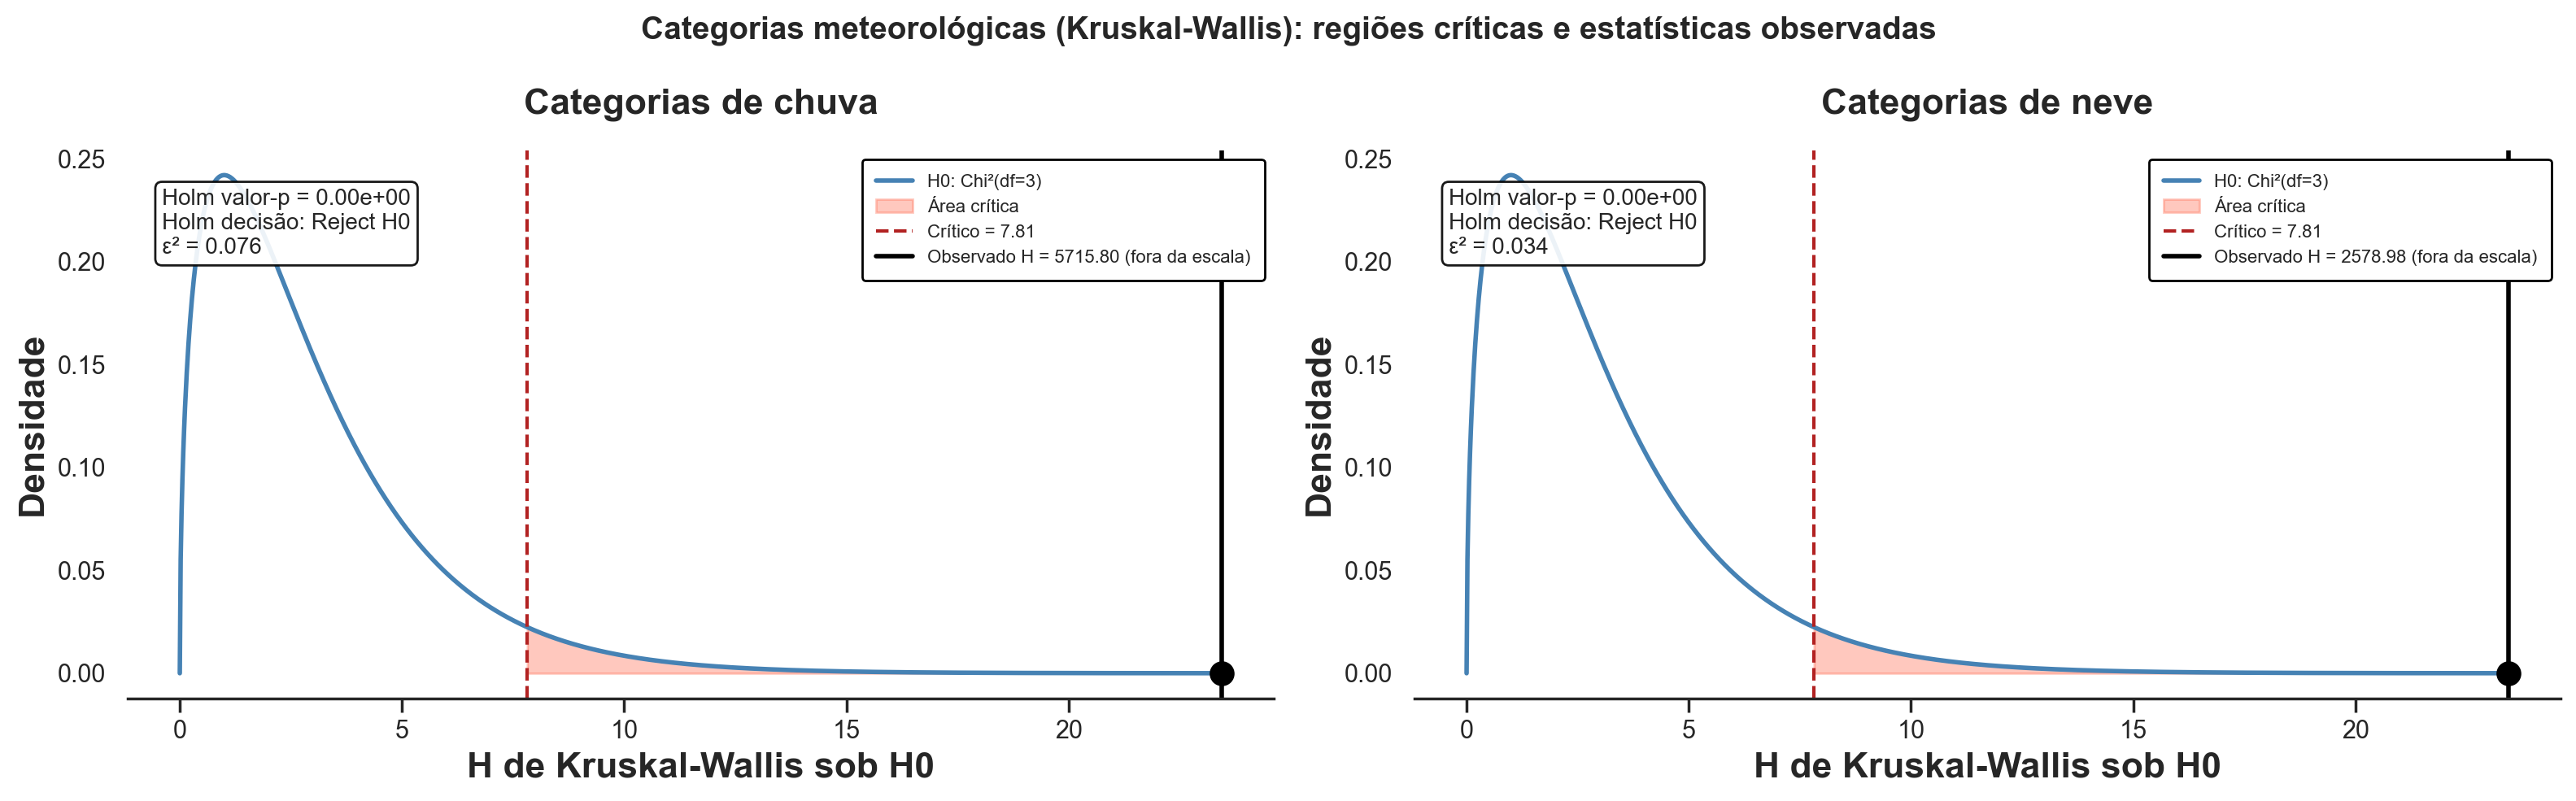

,Teste,N,Grupos,Resumo dos grupos,df,H observado,Épsilon ao quadrado,Valor crítico,valor-p,Decisão,valor-p de Holm,Decisão de Holm
0,Categorias de chuva,75304,4,"No Rain: n=71,157, mediana=0.766 | Light Rain:...",3,5715.804639,0.075867,7.814728,0.0,Rejeita H₀,0.0,Rejeita H₀
1,Categorias de neve,75304,4,"No Snow: n=72,787, mediana=0.748 | Light Snow:...",3,2578.981206,0.034210,7.814728,0.0,Rejeita H₀,0.0,Rejeita H₀


In [20]:
idx_label = lang({'idx': 'Índice de demanda'})['idx']
norm_df, _, _ = st.normality_tests(
    {idx_label: mv_df[TARGET], 'Temperature(C)': mv_df['Temperature(C)'],
     'Humidity(%)': mv_df['Humidity(%)']}, alpha=0.05, lang=lang)
plt.show()
display(st.localize_report(norm_df, lang=lang))

kruskal_df, _, _ = st.kruskal_weather_test(mv_df, alpha=0.05, lang=lang)
plt.show()
display(st.localize_report(kruskal_df, lang=lang))


> **Insights dos testes de normalidade e de Kruskal–Wallis:**
>
> A hipótese de normalidade foi rejeitada para as três variáveis tanto pelo Shapiro–Wilk quanto pelo Anderson–Darling. No Shapiro–Wilk, foram obtidos `W = 0,862` para o índice de demanda, `W = 0,974` para temperatura e `W = 0,984` para umidade, sempre sobre a amostra reprodutível de 5.000 observações. O maior afastamento de 1 foi observado no alvo; para temperatura e umidade, valores de `W` próximos de 1 coexistiram com valores-p muito pequenos, como seria esperado diante da elevada potência amostral.
>
> A forma dessa diferença foi esclarecida pelos descritores calculados sobre as 75.304 observações. Assimetria positiva (`1,505`) e curtose excedente positiva (`2,766`) foram observadas no índice de demanda, cuja mediana foi `0,717` e cujo intervalo interquartil foi `1,090`. Temperatura e umidade ficaram quase simétricas (`−0,199` e `−0,103`), mas apresentaram curtose excedente negativa (`−0,935` e `−0,829`), indicando distribuições mais achatadas que uma Normal.
>
> No Anderson–Darling, as estatísticas do índice, da temperatura e da umidade (`2.793,909`, `627,725` e `269,259`) excederam amplamente o valor crítico de 5% (`0,787`). Essa evidência confirmou a rejeição da forma Normal marginal, mas as estatísticas não foram tratadas como tamanhos de efeito nem como ranking de importância entre features.
>
> Diferenças globais entre as categorias de precipitação permaneceram significativas após a correção de Holm (`p_Holm < 0,001`). Para chuva, a mediana do índice caiu de `0,766` sem chuva para `0,144` com chuva leve e aproximadamente `0,04` nas categorias moderada e forte; foi estimado `ε² = 0,076`. Para neve, a mediana caiu de `0,748` sem neve para `0,234`, `0,222` e `0,127` nas categorias leve, moderada e forte, com `ε² = 0,034`. Assim, uma separação prática maior foi observada para chuva, embora nenhum dos testes identifique sozinho os pares responsáveis pela rejeição.
>
> Como dependência temporal, desequilíbrio entre grupos e confundimento por hora e estação não foram removidos pelo teste global, causalidade não foi estabelecida. Nenhuma variável será transformada ou excluída apenas por esta seção. A escolha de transformações e estimadores será guiada pelo desempenho em validação temporal, enquanto eventuais pressupostos de normalidade serão reavaliados sobre os resíduos do modelo ao qual efetivamente se aplicarem.

## 8. Importância multivariada (Random Forest: impureza, permutação, ablação, SHAP)

Nesta seção, um `RandomForestRegressor` com 300 árvores é utilizado como modelo de diagnóstico para explicar o **índice de demanda des-tendenciado**, e não a contagem bruta. Relações não lineares e interações podem ser representadas por esse estimador, mas o modelo não é tratado como a solução final de previsão. O método segue a formulação de florestas aleatórias apresentada por [Breiman (2001)](https://doi.org/10.1023/A:1010933404324).

Quatro perspectivas de importância são comparadas, sem que seus valores sejam somados ou submetidos a uma votação. A importância por impureza é calculada no conjunto de treino pela redução acumulada do erro quadrático atribuída aos cortes de cada feature e é normalizada para soma igual a 1. Como variáveis contínuas ou com mais possibilidades de corte podem ser favorecidas e a importância pode ser redistribuída entre preditores correlacionados, o ranking é interpretado com a cautela discutida por [Strobl et al. (2007)](https://doi.org/10.1186/1471-2105-8-25).

Na importância por permutação, uma coluna do holdout é embaralhada no modelo já ajustado. Como `neg_root_mean_squared_error` é utilizado como escore, o valor apresentado corresponde ao aumento médio do RMSE provocado pela permutação; oito embaralhamentos são executados, e o desvio-padrão mede apenas a variação entre essas repetições. Quando features correlacionadas ou determinísticas são representadas simultaneamente, sua informação pode ser compartilhada e combinações inexistentes podem ser produzidas pela permutação isolada. Por isso, a medida não equivale a um efeito causal nem a uma importância condicional.

Na ablação, o modelo é reajustado 24 vezes, cada vez sem uma das features, e a alteração do RMSE do holdout é comparada à linha de base. Um `delta_rmse` positivo indica piora após a retirada e, portanto, contribuição incremental da variável diante das demais; um valor negativo indica uma pequena melhora sem ela, mas não prova que a feature seja prejudicial, pois redundância, ruído amostral e aleatoriedade do ajuste também podem produzir essa diferença.

Os valores SHAP são calculados por `TreeExplainer` sobre uma amostra reprodutível de até 500 linhas do holdout, conforme o arcabouço aditivo proposto por [Lundberg e Lee (2017)](https://papers.neurips.cc/paper_files/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html). A média de `|SHAP|` resume a magnitude global das contribuições na escala do índice, enquanto o gráfico de dispersão preserva sinal e heterogeneidade entre observações. Essas contribuições explicam o modelo ajustado, não o processo causal de geração da demanda, e podem ser repartidas de maneira instável entre features correlacionadas.

Uma amostra balanceada e reprodutível de 10.000 registros é formada com 1.000 observações de cada ano-calendário. As 7.000 linhas de 2015–2021 são destinadas ao treino, e as 3.000 linhas de 2022–2024 são reservadas ao holdout. Assim, uma fronteira prospectiva entre anos é preservada, mas a frequência original dos registros é substituída por pesos anuais iguais e apenas uma janela temporal é avaliada. As métricas não substituem a validação por múltiplos anos meteorológicos planejada para o notebook de modelagem.

Os 801 valores ausentes de `Cloud Cover Cat` são representados explicitamente por uma categoria dedicada de ausência, em vez de serem descartados silenciosamente pela classe. As categorias são posteriormente convertidas em rótulos inteiros, o que impõe uma ordem numérica artificial a representações nominais; consequentemente, suas importâncias são específicas desta codificação e deste estimador. Além disso, apenas 46 observações positivas de `is_anomalous_2020` permanecem na amostra de treino e nenhuma ocorre no holdout. Uma importância nula por permutação para essa flag é, portanto, inevitável no holdout e não permite concluir que o regime de 2020 seja irrelevante.

Como o alvo é definido por uma linha de base móvel centrada, observações posteriores são utilizadas na própria construção retrospectiva do índice. O desempenho apresentado descreve a capacidade de reconstruir esse alvo histórico e não deve ser interpretado como simulação operacional de uma previsão disponível em tempo real.

Explicabilidade RF em 10,000 linhas; 801 valores categóricos ausentes mantidos como categoria explícita de ausência


,Divisão,Anos,N,Média do alvo,Mediana do alvo,is_anomalous_2020 = 1
0,Treino,2015–2021,7000,0.922,0.634,46
1,Validação temporal,2022–2024,3000,0.996,0.802,0


,rmse,mae,r2
Linha de base (holdout),0.368,0.247,0.812


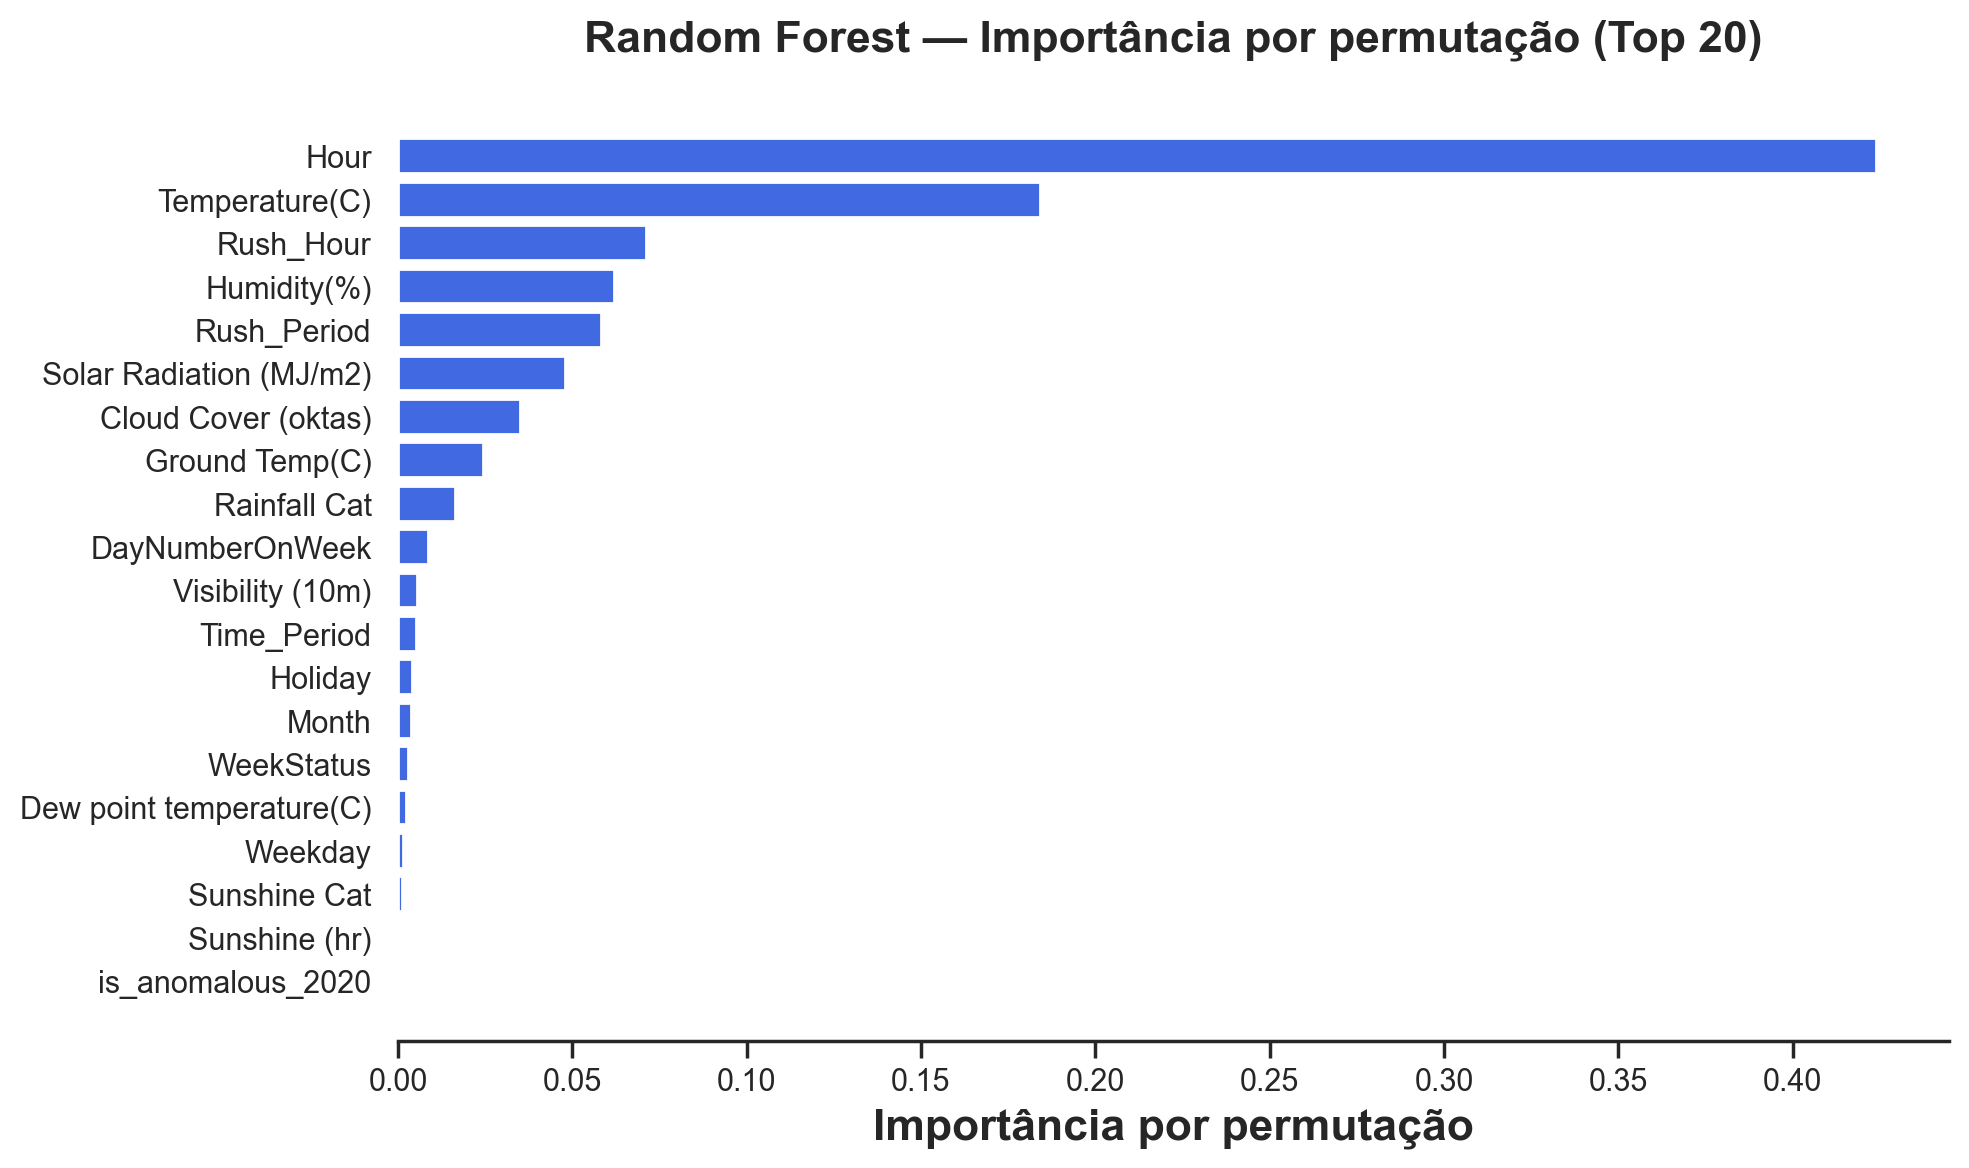

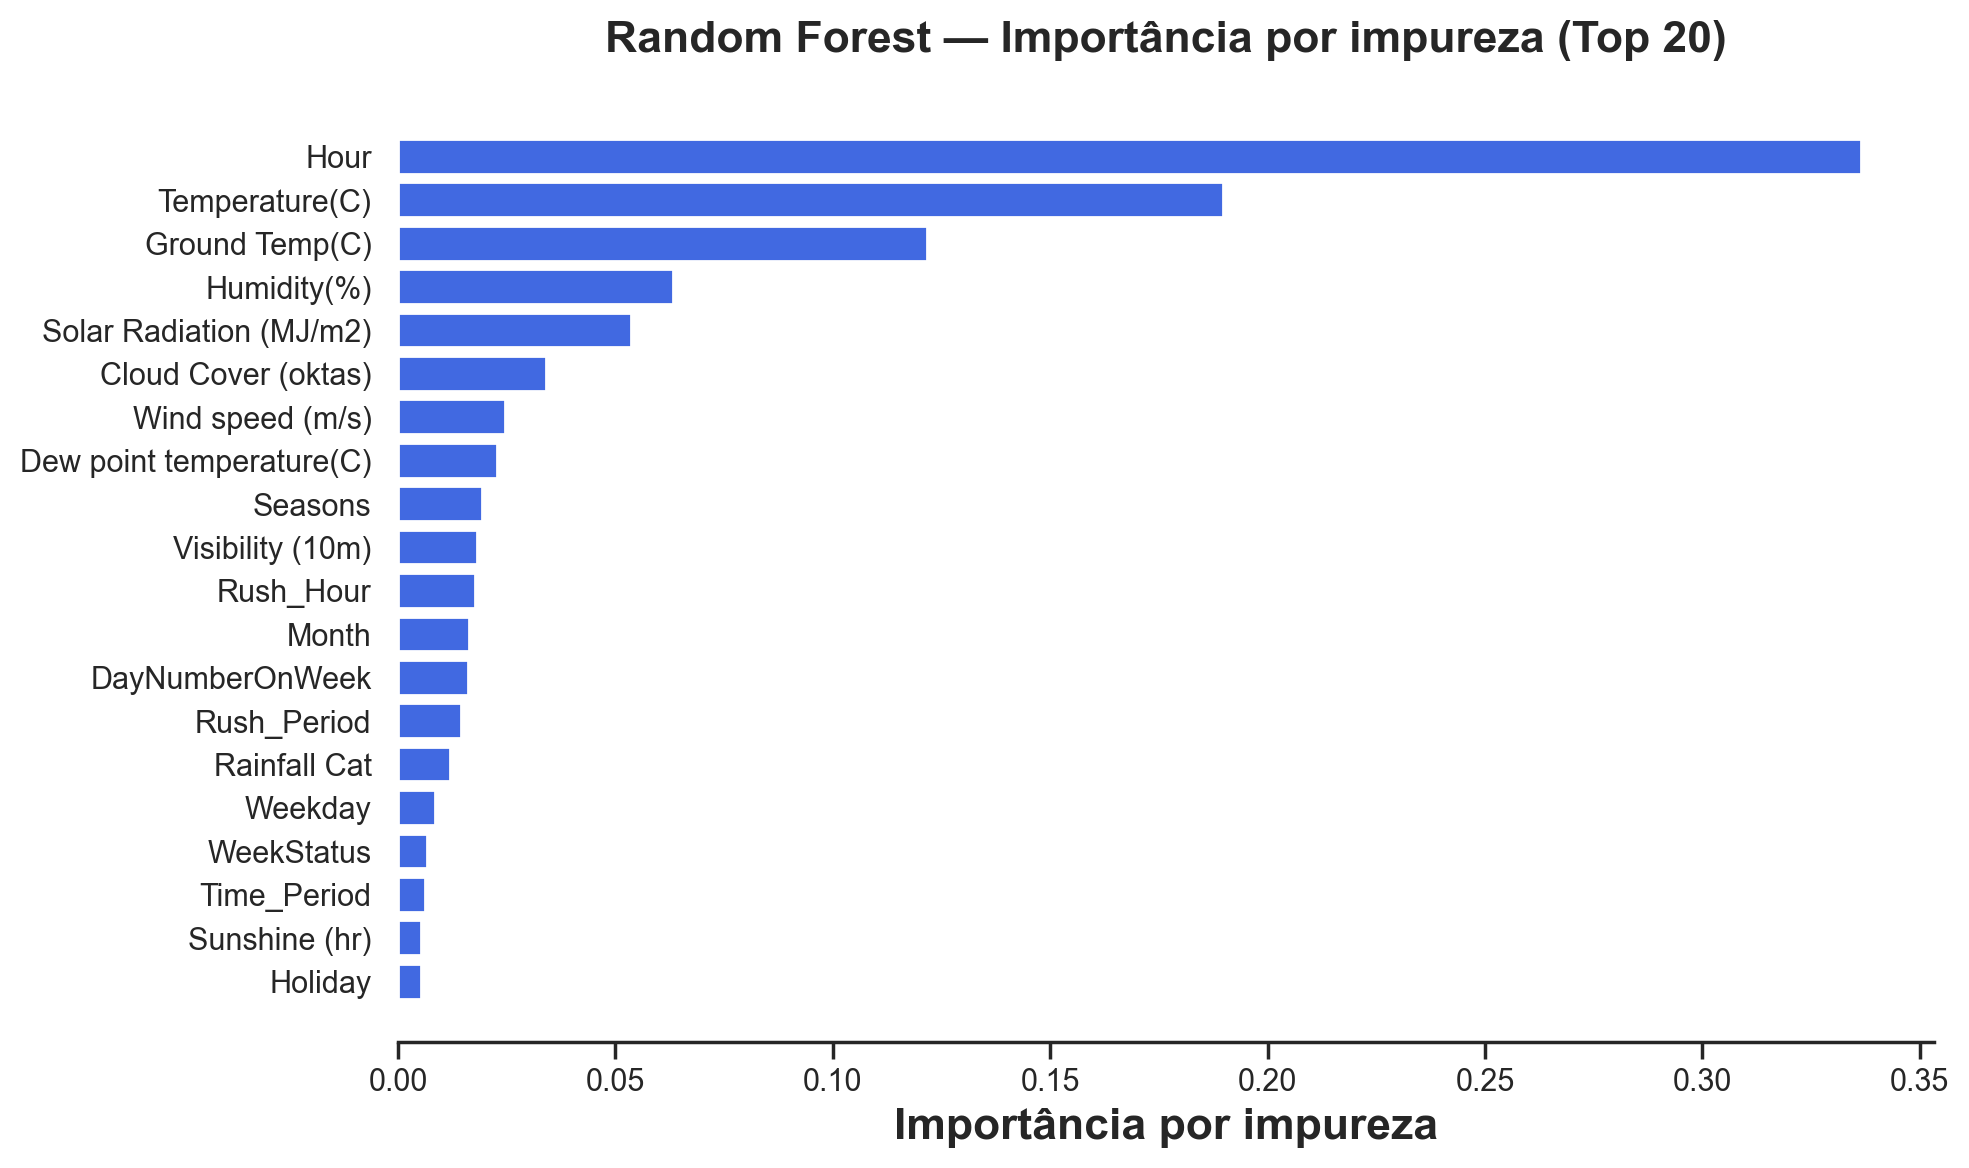

In [21]:
rf_sample, rf_sample_years, categorical_missing = fs.prepare_rf_sample(mv_df, meta['Year'])
msg = lang({
    'rf_on': 'Explicabilidade RF em',
    'retained': 'valores categóricos ausentes mantidos como categoria explícita de ausência',
    'rows': 'linhas',
})
print(f'{msg["rf_on"]} {len(rf_sample):,} {msg["rows"]}; '  # noqa: E501
      f'{categorical_missing:,} {msg["retained"]}')

mfa = fs.MultivariateFeatureAnalysis(
    target_col=TARGET, n_repeats=8, max_shap_samples=500,
).fit(rf_sample)

split_labels = lang({
    'target_mean': 'Média do alvo',
    'target_median': 'Mediana do alvo',
})
display(mfa.split_report(rf_sample_years, lang=lang).style.format({
    split_labels['target_mean']: '{:.3f}',
    split_labels['target_median']: '{:.3f}',
}))
display(mfa.baseline_metrics_.to_frame(
    lang({'bh': 'Linha de base (holdout)'})['bh']).T.style.format('{:.3f}'))
mfa.plot_feature_importance('permutation', lang=lang); plt.show()
mfa.plot_feature_importance('impurity', lang=lang); plt.show()


,Variável,Importância por impureza,Importância por permutação (média),Importância por permutação (desvio-padrão),|SHAP| médio
0,Hour,0.3365,0.4238,0.0078,0.3704
1,Temperature(C),0.1898,0.1840,0.0091,0.2688
2,Rush_Hour,0.0177,0.0712,0.0025,0.0626
3,Humidity(%),0.0631,0.0621,0.0044,0.0863
4,Rush_Period,0.0145,0.0583,0.0021,0.0521
5,Solar Radiation (MJ/m2),0.0536,0.0480,0.0027,0.0697
6,Cloud Cover (oktas),0.0340,0.0349,0.0028,0.0662
7,Ground Temp(C),0.1216,0.0243,0.0046,0.1345
8,Rainfall Cat,0.0120,0.0162,0.0015,0.0274
9,DayNumberOnWeek,0.0162,0.0087,0.0012,0.0157


,Variável removida,RMSE sem a variável,MAE sem a variável,R² sem a variável,Δ RMSE,Δ MAE,Δ R²
0,Hour,0.4112,0.2733,0.7643,+0.0435,+0.0267,-0.0473
1,Visibility (10m),0.3761,0.2515,0.8028,+0.0084,+0.0048,-0.0087
2,Holiday,0.3746,0.2522,0.8044,+0.0069,+0.0055,-0.0071
3,Rainfall Cat,0.3738,0.2505,0.8052,+0.0062,+0.0039,-0.0064
4,Temperature(C),0.3707,0.2493,0.8084,+0.0030,+0.0026,-0.0031
5,Cloud Cover (oktas),0.3705,0.2490,0.8087,+0.0028,+0.0023,-0.0029
6,DayNumberOnWeek,0.3696,0.2480,0.8095,+0.0020,+0.0013,-0.0020
7,Dew point temperature(C),0.3688,0.2474,0.8103,+0.0012,+0.0008,-0.0012
8,is_anomalous_2020,0.3683,0.2471,0.8109,+0.0007,+0.0004,-0.0007
9,Snowfall Cat,0.3681,0.2468,0.8111,+0.0004,+0.0002,-0.0004


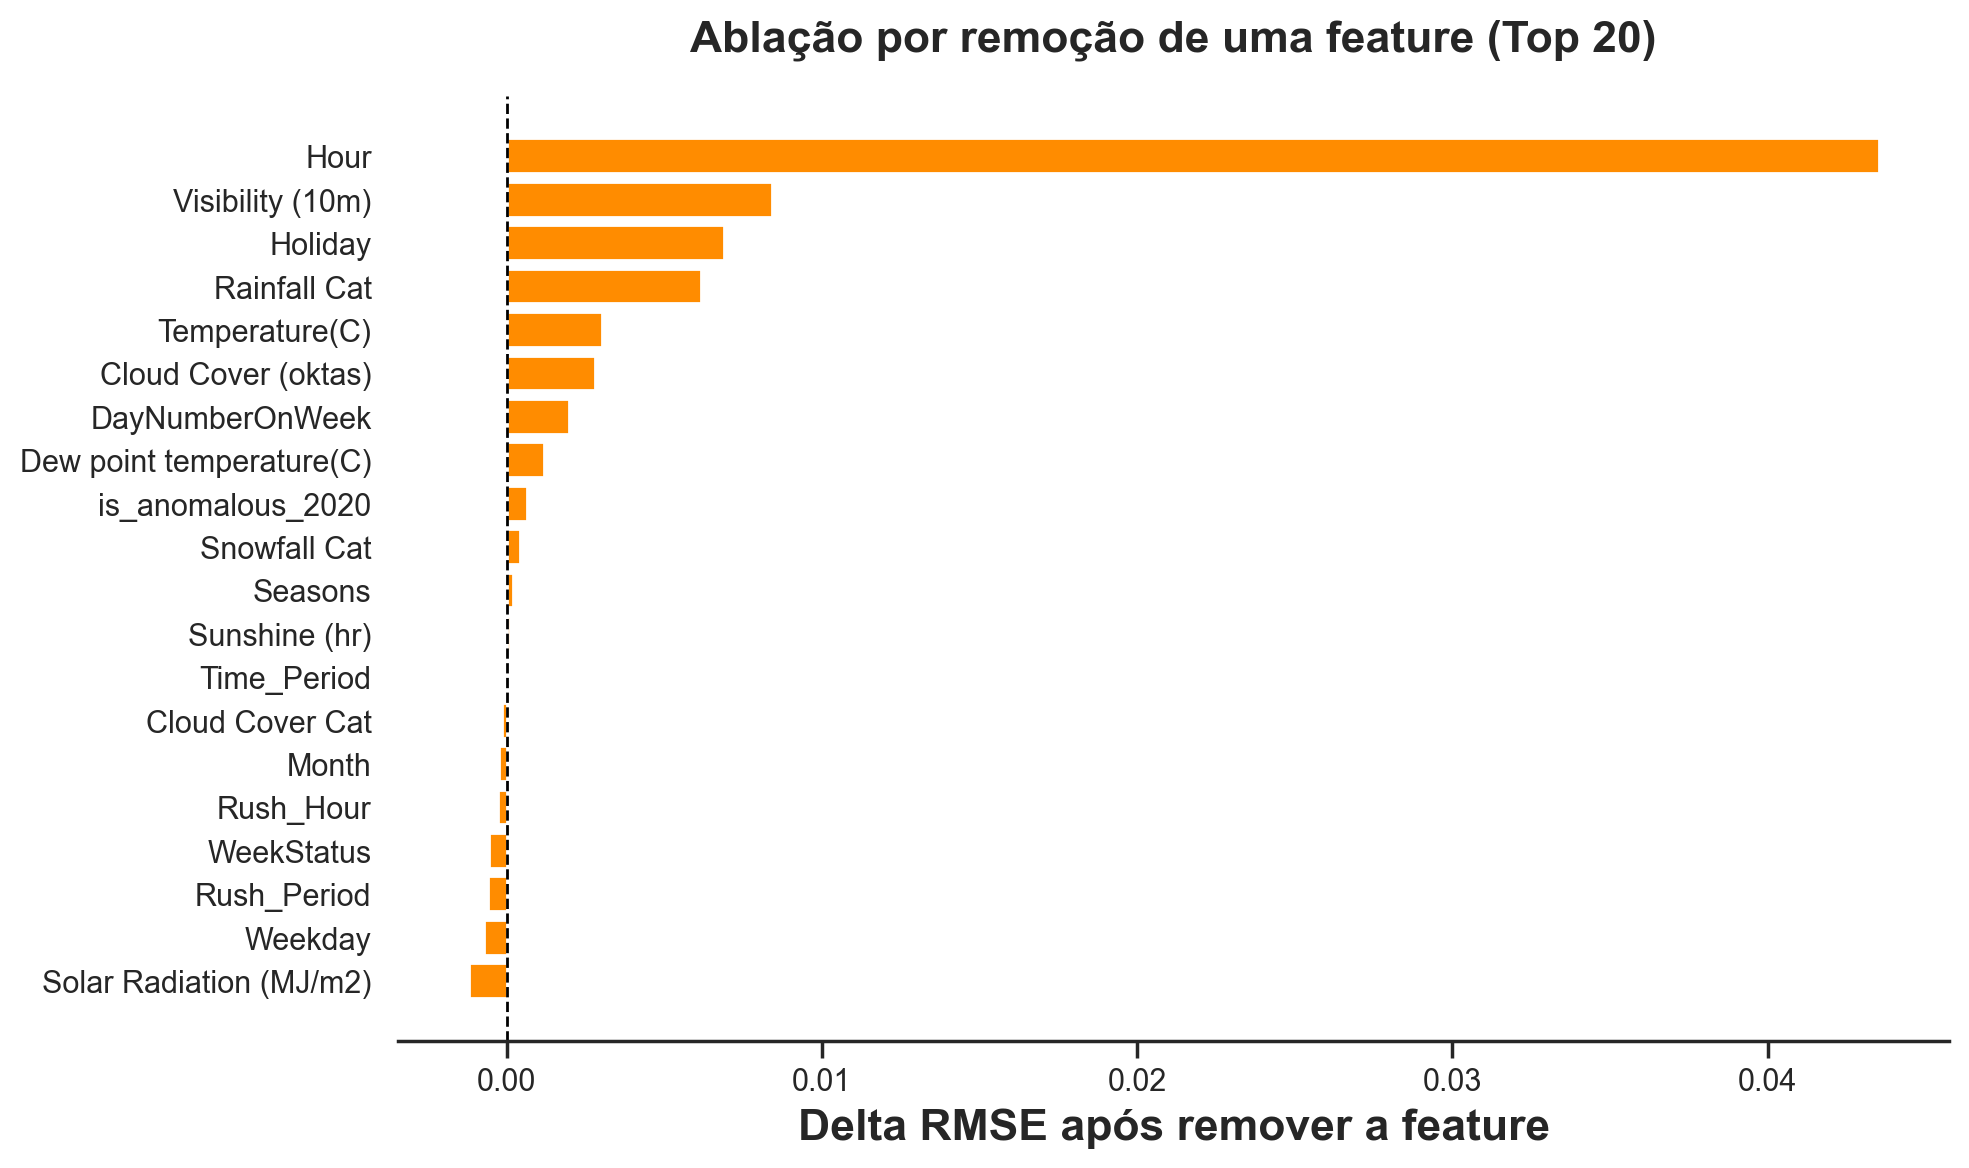

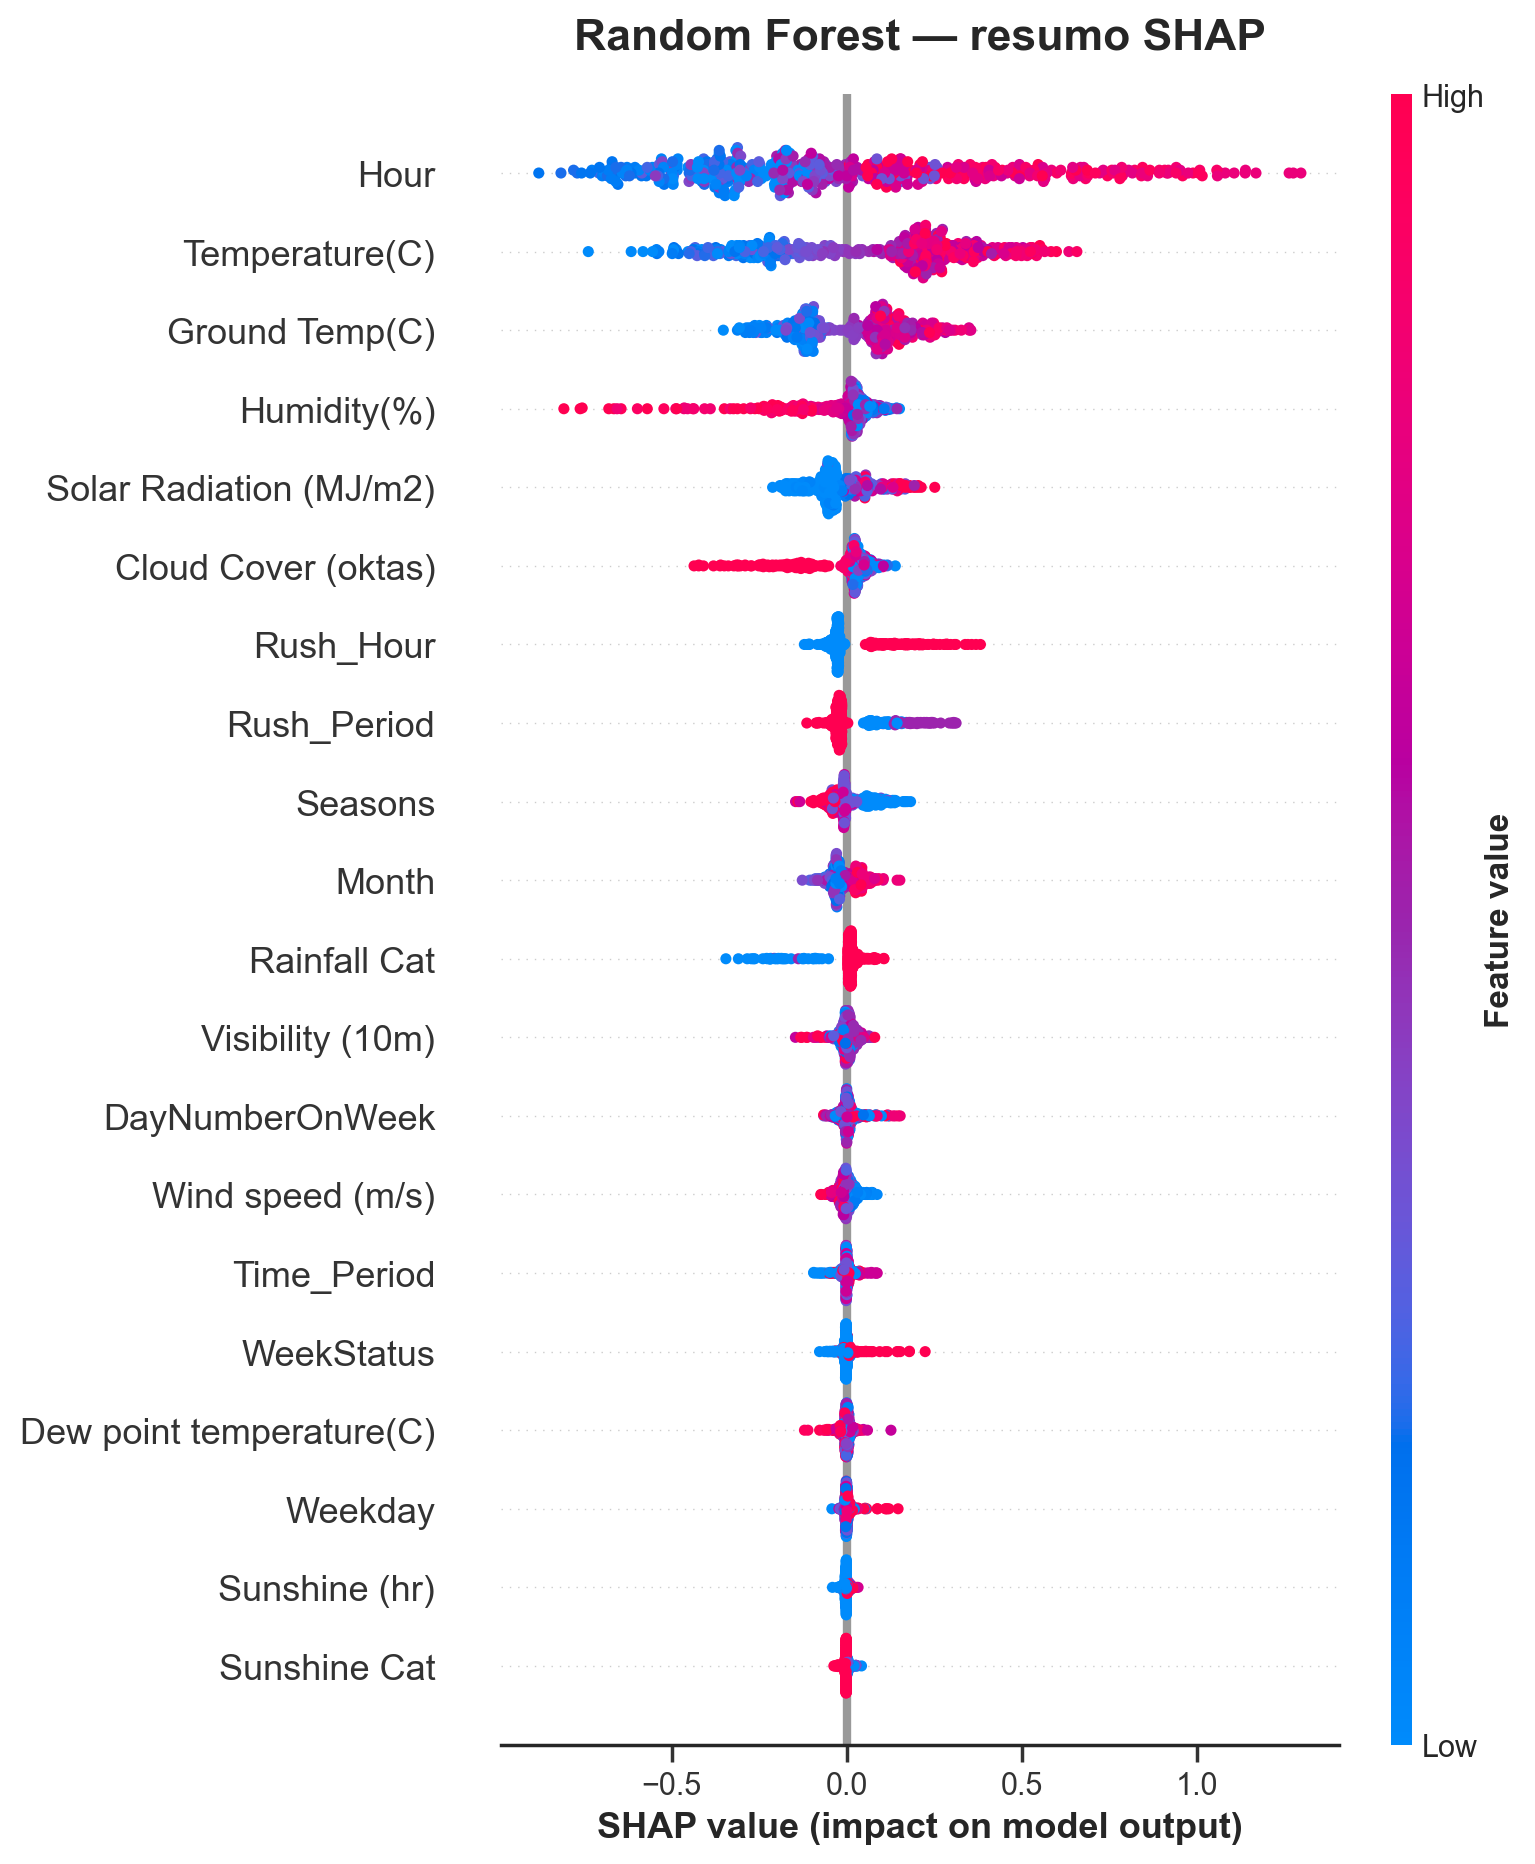

In [22]:
importance_labels = lang({
    'impurity': 'Importância por impureza',
    'permutation_mean': 'Importância por permutação (média)',
    'permutation_std': 'Importância por permutação (desvio-padrão)',
    'shap_mean': '|SHAP| médio',
})
importance_report = mfa.get_feature_importance_table(top_n=20)
display(fs.localize_importance_table(importance_report, lang=lang).style.format({
    importance_labels['impurity']: '{:.4f}',
    importance_labels['permutation_mean']: '{:.4f}',
    importance_labels['permutation_std']: '{:.4f}',
    importance_labels['shap_mean']: '{:.4f}',
}))

ablation_labels = lang({
    'rmse_without': 'RMSE sem a variável',
    'mae_without': 'MAE sem a variável',
    'r2_without': 'R² sem a variável',
    'delta_rmse': 'Δ RMSE',
    'delta_mae': 'Δ MAE',
    'delta_r2': 'Δ R²',
})
ablation_report = mfa.ablation_importance_df_.head(20)
display(fs.localize_ablation_table(ablation_report, lang=lang).style.format({
    ablation_labels['rmse_without']: '{:.4f}',
    ablation_labels['mae_without']: '{:.4f}',
    ablation_labels['r2_without']: '{:.4f}',
    ablation_labels['delta_rmse']: '{:+.4f}',
    ablation_labels['delta_mae']: '{:+.4f}',
    ablation_labels['delta_r2']: '{:+.4f}',
}))
mfa.plot_ablation(lang=lang); plt.show()
if mfa.shap_available_:
    mfa.plot_shap_summary(lang=lang); plt.show()
else:
    shap_msg = lang({'unavailable': 'SHAP não disponível:'})['unavailable']
    print(shap_msg, mfa.shap_note_)


>### Insight
>
> Após a preservação das 10.000 linhas, o modelo treinado em 2015–2021 e avaliado em 2022–2024 obteve `RMSE = 0,368`, `MAE = 0,247` e `R² = 0,812`. Aproximadamente 81% da variância do índice no holdout balanceado foi reconstruída pelo Random Forest, mas esse resultado foi obtido em uma única fronteira temporal e sobre um alvo retrospectivo. Desempenho operacional futuro não foi demonstrado.
>
> `Hour` foi identificado como o driver mais robusto. Foram obtidos `0,336` de importância por impureza, aumento médio de `0,424` no RMSE após permutação e aumento de `0,045` após retirada e novo ajuste. A diferença entre permutação e ablação foi esperada: quando `Hour` foi removida, parte de sua informação pôde ser recuperada por `Rush_Hour`, `Rush_Period` e `Time_Period`; quando apenas `Hour` foi embaralhada, combinações incoerentes com essas variáveis derivadas foram produzidas.
>
> A temperatura também permaneceu relevante por impureza (`0,190`) e permutação (`ΔRMSE = 0,185`), mas sua ablação elevou o RMSE em apenas `0,003`. A substituição por temperatura do solo, ponto de orvalho, umidade e sazonalidade foi evidenciada por essa queda de importância incremental. De forma semelhante, temperatura do solo recebeu importância por impureza de `0,122`, mas apenas `0,025` por permutação e uma ablação residual, próxima de zero. Assim, os rankings confirmaram um bloco térmico importante, mas não uma contribuição independente de cada coluna.
>
> `Visibility (10m)` apresentou a segunda maior ablação (`ΔRMSE = 0,008`), atrás apenas de `Hour`; `Holiday` (`ΔRMSE = 0,006`) e `Rainfall Cat` (`ΔRMSE = 0,006`) ficaram praticamente empatadas logo em seguida. `Rainfall Cat` manteve apenas `0,016` de aumento médio do RMSE por permutação, reforçando a diferença entre as duas óticas de importância. `Rush_Period`, `Rush_Hour` e cobertura de nuvens também produziram pioras mensuráveis quando retiradas. Em contraste, importâncias negativas ou próximas de zero para estação, vento, umidade e algumas features derivadas ficaram na escala da variação do ajuste e foram interpretadas como redundância ou instabilidade, não como prova de ausência de associação.
>
> A permutação de `is_anomalous_2020` produziu exatamente zero porque a flag é constante e igual a zero em todo o holdout. Como somente 46 casos positivos permaneceram no treino, a relevância do regime anômalo não pôde ser julgada por essa janela. O resultado não autoriza a retirada da flag nem sustenta uma interpretação sobre o mecanismo de 2020.
>
> Os valores médios absolutos de SHAP e o gráfico de dispersão devem ser lidos na escala das contribuições do modelo, e não comparados numericamente às proporções de impureza ou aos deltas de RMSE. Para categorias convertidas em códigos inteiros, direção e distância entre cores também dependem de uma ordenação artificial e não recebem interpretação ordinal.
>
> Como decisão do projeto, nenhuma feature será excluída manualmente pela posição em um único ranking. A convergência entre métodos será utilizada como evidência exploratória, enquanto redundância, estabilidade e ganho fora da amostra serão avaliados por `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector` ou `NoSelector`, sempre em conjunto com o estimador e com validação temporal por anos meteorológicos.

## 9. Síntese

A análise multivariada foi estruturada para que relações horárias, sazonais e meteorológicas fossem examinadas sem que o crescimento de longo prazo da operação dominasse os resultados. Antes dos testes, a integridade temporal foi tratada, o alvo analítico foi redefinido como demanda relativa e as conclusões foram separadas entre associação, redundância e utilidade preditiva fora da amostra.

### Base analítica e cobertura

A janela de maio a dezembro de 2020 foi identificada por uma regra reproduzível, após a demanda observada ter caído para aproximadamente 8%–50% da interpolação geométrica entre 2019 e 2021. A causa não pôde ser determinada pelos dados disponíveis; um artefato de cobertura foi considerado plausível, mas não foi assumido como fato. As linhas foram preservadas e o período foi sinalizado por `is_anomalous_2020`, enquanto os dias afetados foram excluídos somente da estimação da linha de base.

O crescimento de aproximadamente 110 vezes entre 2015 e 2023 foi tratado como mudança de nível e escala do sistema. Uma linha de base móvel centrada de 365 dias foi estimada sobre médias diárias, e a contagem horária foi convertida no índice multiplicativo `demanda / linha de base`. A correlação linear com o tempo foi reduzida de `0,548` na demanda bruta para `0,0274` no índice. O alvo foi definido para 75.304 das 81.018 observações (`92,9%`); as 5.714 linhas sem índice foram concentradas na janela anômala, onde o mínimo de 180 dias válidos não foi alcançado.

Nos anos meteorológicos completos e não anômalos, médias próximas de 1 foram obtidas, entre aproximadamente `0,943` e `1,008`. Uma forma sazonal ampla foi preservada, com demanda relativa menor no inverno e maior nos meses quentes e no início do outono. Como diferenças de amplitude permaneceram entre anos, sobretudo em setembro e outubro, foi sustentada a recorrência do padrão geral, mas não uma invariância sazonal nem uma explicação exclusivamente climática.

### Estrutura das associações e redundâncias

Pela análise PhiK balanceada por ano, 33 pares apresentaram simultaneamente `phik ≥ 0,50` e significância `Z ≥ 3`. As associações mais altas foram concentradas em representações derivadas da mesma informação, como `DayNumberOnWeek`–`Weekday`, `Weekday`–`WeekStatus`, `Month`–`Seasons`, `Rush_Hour`–`Rush_Period`, `Hour`–`Time_Period` e variáveis contínuas com suas categorias discretizadas. Apenas `Rush_Period` atingiu `phik ≥ 0,50` com o alvo (`0,542`), mas por ser função determinística da hora (`phik` de `1,000` com `Rush_Hour` e `0,825` com `Hour`) essa associação repete o sinal de horário de pico; os demais maiores valores foram observados para `Hour` (`0,481`), `Time_Period` (`0,458`), `Ground Temp(C)` (`0,385`) e `Temperature(C)` (`0,368`). Foi indicada uma estrutura multivariada, e não um preditor isolado capaz de explicar fortemente a demanda relativa.

Uma redundância meteorológica severa foi confirmada pelo VIF com intercepto. Foram obtidos VIFs de `149,86` para ponto de orvalho, `132,71` para temperatura do ar, `26,46` para umidade e `21,53` para temperatura do solo; mais de 99% da variância da temperatura e do ponto de orvalho pôde ser reconstruída linearmente pelas demais medidas avaliadas. Radiação solar (`4,15`) e velocidade do vento (`1,10`) permaneceram abaixo das faixas de inflação elevada. Esse diagnóstico foi interpretado como risco para estabilidade de coeficientes e atribuição individual, e não como demonstração de inutilidade preditiva.

Diferenças sazonais relevantes foram sustentadas pelos testes baseados em postos. Os contrastes primavera–inverno e verão–inverno produziram correlações bisseriais de postos de `0,419` e `0,547`, e o teste global entre estações apresentou `ε² = 0,154`. Entre verão e outono, apesar da significância após Holm, um efeito praticamente nulo foi obtido (`r_rb = −0,021`). Uma associação monotônica moderada foi observada entre temperatura e demanda relativa (`ρ_s = 0,502`), enquanto a diferença entre feriados e demais dias foi pequena (`r_rb = −0,155`). Foi demonstrado, portanto, que valores-p reduzidos não implicam automaticamente relevância prática.

Nos filtros univariados, `Time_Period`, `Rush_Hour`, `Sunshine Cat` e `Seasons` produziram os maiores V de Cramér; temperatura do solo, temperatura do ar, hora e radiação solar produziram as maiores separações pela ANOVA; e temperatura, temperatura do solo, hora, madrugada, horário de pico e inverno produziram os maiores `R²` isolados pela F-regression. A convergência de hora e bloco térmico foi reforçada, mas contribuição independente não foi estabelecida, pois colinearidade e representações derivadas foram mantidas nesses rankings. As faixas `Q1`–`Q5` foram utilizadas apenas para o diagnóstico e não foram incorporadas ao quadro de modelagem.

A normalidade marginal foi rejeitada para o índice, a temperatura e a umidade. Assimetria positiva (`1,505`) e curtose excedente positiva (`2,766`) foram observadas no alvo, enquanto temperatura e umidade ficaram quase simétricas e mais achatadas que uma Normal. Essa rejeição não foi convertida em transformação ou exclusão automática, pois pressupostos paramétricos devem ser verificados no objeto ao qual se aplicam, como resíduos ou distribuições condicionais. Para precipitação, diferenças globais após Holm foram acompanhadas por `ε² = 0,076` para chuva e `ε² = 0,034` para neve, tendo sido observada uma separação prática maior nas categorias de chuva.

### Evidência multivariada e decisão do projeto

No diagnóstico com Random Forest, as 10.000 observações balanceadas foram preservadas após os valores ausentes de `Cloud Cover Cat` terem sido representados por uma categoria dedicada de ausência. O modelo foi treinado em 2015–2021 e avaliado em 2022–2024, tendo sido obtidos `RMSE = 0,368`, `MAE = 0,247` e `R² = 0,812`. `Hour` foi a feature mais robusta entre impureza, permutação e ablação. O bloco térmico também permaneceu importante, mas sua contribuição foi redistribuída entre temperatura do ar, temperatura do solo, ponto de orvalho, umidade e sazonalidade. `Visibility (10m)` apresentou a segunda maior ablação, atrás somente de `Hour`, com `Holiday` e `Rainfall Cat` praticamente empatadas logo em seguida; `Rainfall Cat` manteve importância moderada por permutação.

As divergências entre os métodos foram preservadas como informação. Permutação, ablação, impureza e SHAP medem objetos distintos, e a presença de features correlacionadas ou determinísticas altera a parcela atribuída a cada uma. A importância nula por permutação de `is_anomalous_2020` não foi interpretada como irrelevância: somente 46 casos positivos permaneceram no treino e a flag foi constante e igual a zero em todo o holdout. Da mesma forma, a codificação de categorias por rótulos inteiros foi reconhecida como uma limitação específica dessa explicação por Random Forest.

Nenhuma exclusão manual foi realizada pelos diagnósticos deste notebook. Todas as features serão mantidas como candidatas, e a seleção será tratada como parte conjunta do pipeline, por meio de `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector` ou `NoSelector`, conforme a compatibilidade com o estimador. Redundâncias determinísticas e meteorológicas deverão ser interpretadas por grupos semânticos quando permanecerem no modelo. A decisão final deverá ser sustentada por desempenho e estabilidade em validação temporal por anos meteorológicos, e não por um ranking universal.

Por fim, as evidências produzidas são associativas e exploratórias. Dependência serial, desequilíbrio entre grupos, confundimento sazonal e apenas uma fronteira temporal no Random Forest limitam a inferência. Além disso, a média móvel centrada utiliza observações futuras na construção retrospectiva do índice; por isso, o índice não deve ser empregado como feature disponível em tempo real nem apresentado como transformação operacional pronta para previsão. Caso seja adotado como alvo em modelagem, sua linha de base deverá ser construída de forma causal dentro de cada partição ou prevista separadamente, sem acesso ao período de validação.

### Referência metodológica

- Anderson, T. W., & Darling, D. A. (1952). *Asymptotic theory of certain ‘goodness of fit’ criteria based on stochastic processes*. **The Annals of Mathematical Statistics, 23**(2), 193–212. https://doi.org/10.1214/aoms/1177729437

- Baak, M., Koopman, R., Snoek, H., & Klous, S. (2020). *A new correlation coefficient between categorical, ordinal and interval variables with Pearson characteristics*. **Computational Statistics & Data Analysis, 152**, 107043. https://doi.org/10.1016/j.csda.2020.107043

- Breiman, L. (2001). *Random forests*. **Machine Learning, 45**, 5–32. https://doi.org/10.1023/A:1010933404324

- Fisher, R. A. (1925). *Statistical methods for research workers*. Edinburgh: Oliver and Boyd. https://openlibrary.org/works/OL1153861W/Statistical_methods_for_research_workers

- Holm, S. (1979). *A simple sequentially rejective multiple test procedure*. **Scandinavian Journal of Statistics, 6**(2), 65–70. https://www.jstor.org/stable/4615733

- Kerby, D. S. (2014). *The simple difference formula: An approach to teaching nonparametric correlation*. **Comprehensive Psychology, 3**, 11.IT.3.1. https://doi.org/10.2466/11.IT.3.1

- Kruskal, W. H., & Wallis, W. A. (1952). *Use of ranks in one-criterion variance analysis*. **Journal of the American Statistical Association, 47**(260), 583–621. https://doi.org/10.1080/01621459.1952.10483441

- Lundberg, S. M., & Lee, S.-I. (2017). *A unified approach to interpreting model predictions*. **Advances in Neural Information Processing Systems, 30**, 4765–4774. https://papers.neurips.cc/paper_files/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html

- Mann, H. B., & Whitney, D. R. (1947). *On a test of whether one of two random variables is stochastically larger than the other*. **The Annals of Mathematical Statistics, 18**(1), 50–60. https://doi.org/10.1214/aoms/1177730491

- Miller, D. M., & Williams, D. (2003). *Shrinkage estimators of time series seasonal factors and their effect on forecasting accuracy*. **International Journal of Forecasting, 19**(4), 669–684. https://doi.org/10.1016/S0169-2070(02)00077-8

- O’Brien, R. M. (2007). *A caution regarding rules of thumb for variance inflation factors*. **Quality & Quantity, 41**(5), 673–690. https://doi.org/10.1007/s11135-006-9018-6

- Pearson, K. (1900). *On the criterion that a given system of deviations from the probable in the case of a correlated system of variables is such that it can be reasonably supposed to have arisen from random sampling*. **The London, Edinburgh, and Dublin Philosophical Magazine and Journal of Science, 50**(302), 157–175. https://doi.org/10.1080/14786440009463897

- Shapiro, S. S., & Wilk, M. B. (1965). *An analysis of variance test for normality (complete samples)*. **Biometrika, 52**(3–4), 591–611. https://doi.org/10.1093/biomet/52.3-4.591

- Spearman, C. (1904). *The proof and measurement of association between two things*. **The American Journal of Psychology, 15**(1), 72–101. https://doi.org/10.2307/1412159

- Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). *Bias in random forest variable importance measures: Illustrations, sources and a solution*. **BMC Bioinformatics, 8**, 25. https://doi.org/10.1186/1471-2105-8-25